#**Generation of Offline Dataset**
Once created, use it to train algorithms on it and determine results: total rewards, agents alive, ect.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#download the necessary libraries
!pip install magent2
!pip install minari
!pip install numpy

  Using cached minari-0.5.3-py3-none-any.whl.metadata (6.2 kB)
Using cached minari-0.5.3-py3-none-any.whl (56 kB)


## V2 dataset

In [ ]:
from magent2.environments import battle_v4

import os
import minari
import numpy as np
import time
import re
import shutil
from pathlib import Path

from gymnasium import spaces
from minari.data_collector import EpisodeBuffer

# persistent saving setup
def setup_persistent_minari_storage(
    drive_root="/content/drive",
    drive_subdir="MyDrive/eecs_295p_gnn_research_report",
):
    """
    Mount Google Drive (Colab) and force Minari to save datasets into Drive.
    Returns the resolved datasets root path.
    """
    # Only works in Colab; safe to wrap if you run elsewhere.
    try:
        from google.colab import drive
        drive.mount(drive_root, force_remount=False)
    except Exception as e:
        print("WARNING: Could not mount Google Drive (not in Colab or permission issue).")
        print("Minari will save to its default local path instead.")
        return None

    datasets_root = Path(drive_root) / drive_subdir
    datasets_root.mkdir(parents=True, exist_ok=True)

    # Tell Minari where to store datasets
    os.environ["MINARI_DATASETS_PATH"] = str(datasets_root)

    print(f"[OK] MINARI_DATASETS_PATH set to: {datasets_root}")
    return datasets_root


def make_part_id(base_dataset_id: str, part: int) -> str:
    # base_dataset_id must end in -v<number>
    m = re.search(r"(.*)-v(\d+)$", base_dataset_id)
    if not m:
        base_dataset_id = base_dataset_id + "-v0"
        m = re.search(r"(.*)-v(\d+)$", base_dataset_id)
    prefix, ver = m.group(1), m.group(2)
    return f"{prefix}_part{part:03d}-v{ver}"


def heuristic_policy(obs_dict, env, alive_agents):
    """
    Simple heuristic:
    - attack if possible
    - otherwise move randomly
    """
    actions = {}

    for agent in alive_agents:
        action_space = env.action_space(agent)
        n_actions = action_space.n

        # assume last action index corresponds to attack
        attack_action = n_actions - 1

        # 30% chance attack, otherwise move
        if np.random.rand() < 0.3:
            actions[agent] = attack_action
        else:
            actions[agent] = np.random.randint(0, n_actions - 1)

    return actions


def mixed_policy(obs_dict, env, alive_agents):
    r = np.random.rand()

    if r < 0.4:
        return heuristic_policy(obs_dict, env, alive_agents)

    if r < 0.7:
        return {a: env.action_space(a).sample() for a in alive_agents}

    # biased attack
    actions = {}
    for a in alive_agents:
        n = env.action_space(a).n
        actions[a] = n - 1 if np.random.rand() < 0.5 else np.random.randint(n)
    return actions


def extract_xy_from_obs(obs_a, map_size, pos_channels=(-2, -1)):
    """Center pixel of last two channels -> normalized (x,y) -> grid coords."""
    obs_a = np.asarray(obs_a)
    H, W, C = obs_a.shape
    cy, cx = H // 2, W // 2
    px = float(np.clip(obs_a[cy, cx, pos_channels[0]], 0.0, 1.0))
    py = float(np.clip(obs_a[cy, cx, pos_channels[1]], 0.0, 1.0))
    x = int(round(px * (map_size - 1)))
    y = int(round(py * (map_size - 1)))
    return x, y


def make_node_features(obs_a, map_size):
    """
    Convert one agent's observation (13,13,C) -> small feature vector.
    """
    obs_a = np.asarray(obs_a, dtype=np.float32)
    x, y = extract_xy_from_obs(obs_a, map_size)

    posx_mean = float(obs_a[:, :, -2].mean())
    posy_mean = float(obs_a[:, :, -1].mean())
    dens0 = float(obs_a[:, :, 0].mean()) if obs_a.shape[2] > 0 else 0.0
    dens1 = float(obs_a[:, :, 1].mean()) if obs_a.shape[2] > 1 else 0.0
    dens2 = float(obs_a[:, :, 2].mean()) if obs_a.shape[2] > 2 else 0.0

    return np.array(
        [
            x / (map_size - 1),
            y / (map_size - 1),
            posx_mean,
            posy_mean,
            dens0,
            dens1,
            dens2,
        ],
        dtype=np.float32,
    )


def build_edge_index(global_agents, alive_agents, positions_xy, R=6, k_max=8):
    """
    Returns edge_index (2,E) in global agent indices.
    """
    idx = {a: i for i, a in enumerate(global_agents)}
    alive = [a for a in alive_agents if a in positions_xy]
    if len(alive) < 2:
        return np.zeros((2, 0), dtype=np.int16)

    pos = np.array([positions_xy[a] for a in alive], dtype=np.float32)
    edges = []
    for i_a, a in enumerate(alive):
        d = np.linalg.norm(pos - pos[i_a], axis=1)
        nbr = np.where((d > 0) & (d <= R))[0]
        if len(nbr) > k_max:
            nbr = nbr[np.argsort(d[nbr])[:k_max]]
        gi = idx[a]
        for j_a in nbr:
            gj = idx[alive[j_a]]
            edges.append((gi, gj))

    if not edges:
        return np.zeros((2, 0), dtype=np.int16)
    return np.array(edges, dtype=np.int16).T  # (2,E)


def collect_minari_compact_sharded(
    base_dataset_id="uci/battle_v4/compact-random-v0",
    total_episodes=200,
    episodes_per_part=25,
    map_size=45,
    max_cycles=300,
    minimap_mode=True,
    extra_features=True,
    R=6,
    k_max=8,
    policy=None,
    E_max=None,
    debug_first=False,

    # ----------------------------
    # NEW: sharing/export options
    # ----------------------------
    persist_to_drive=True,
    drive_subdir="MyDrive/UCI_MARL_TEAM/minari_datasets",
    zip_each_part=True,
):
    # NEW: set persistent storage (Drive) BEFORE creating datasets
    datasets_root = None
    if persist_to_drive:
        datasets_root = setup_persistent_minari_storage(
            drive_root="/content/drive",
            drive_subdir=drive_subdir,
        )

    env = battle_v4.parallel_env(
        map_size=map_size,
        max_cycles=max_cycles,
        minimap_mode=minimap_mode,
        extra_features=extra_features,
    )

    reset_out = env.reset()
    obs = reset_out[0] if isinstance(reset_out, tuple) else reset_out

    global_agents = list(env.possible_agents)
    MAX_AGENTS = len(global_agents)
    any_agent = env.agents[0]
    n_actions = env.action_space(any_agent).n

    F = make_node_features(obs[any_agent], map_size).shape[0]

    if E_max is None:
        E_max = MAX_AGENTS * k_max

    observation_space = spaces.Dict(
        {
            "node_feat": spaces.Box(low=-np.inf, high=np.inf, shape=(MAX_AGENTS, F), dtype=np.float32),
            "mask": spaces.MultiBinary(MAX_AGENTS),
            "edge_index": spaces.Box(low=0, high=MAX_AGENTS - 1, shape=(2, E_max), dtype=np.int16),
            "edge_mask": spaces.MultiBinary(E_max),
        }
    )
    action_space = spaces.MultiDiscrete([n_actions] * MAX_AGENTS)

    def make_actions(obs_dict, alive_agents):
        if policy is None:
            return {a: env.action_space(a).sample() for a in alive_agents}
        acts = policy(obs_dict, env, alive_agents)
        return {a: acts.get(a, env.action_space(a).sample()) for a in alive_agents}

    print(
        f"Compact dataset collection\n"
        f"base_id={base_dataset_id}\n"
        f"total_episodes={total_episodes}, episodes_per_part={episodes_per_part}\n"
        f"map_size={map_size}, max_cycles={max_cycles}\n"
        f"MAX_AGENTS={MAX_AGENTS}, F={F}, E_max={E_max}\n"
        f"MINARI_DATASETS_PATH={os.environ.get('MINARI_DATASETS_PATH', '(default)')}\n"
    )

    part = 0
    ep_done = 0
    t_global0 = time.time()

    while ep_done < total_episodes:
        part_id = make_part_id(base_dataset_id, part)
        part_eps = min(episodes_per_part, total_episodes - ep_done)
        print(f"\nWriting part: {part_id} | episodes={part_eps}")

        episode_buffers = []

        for ep_local in range(part_eps):
            reset_out = env.reset()
            obs = reset_out[0] if isinstance(reset_out, tuple) else reset_out

            node_feat_steps = []
            mask_steps = []
            edge_index_steps = []
            edge_mask_steps = []

            act_steps = []
            rew_steps = []
            term_steps = []
            trunc_steps = []

            step = 0
            while env.agents:
                alive = list(env.agents)
                actions_dict = make_actions(obs, alive)
                next_obs, rewards, terms, truncs, infos = env.step(actions_dict)

                positions = {a: extract_xy_from_obs(obs[a], map_size) for a in alive}

                node_feat = np.zeros((MAX_AGENTS, F), dtype=np.float32)
                mask = np.zeros((MAX_AGENTS,), dtype=np.uint8)

                idx = {a: i for i, a in enumerate(global_agents)}
                for a in alive:
                    i = idx[a]
                    mask[i] = 1
                    node_feat[i] = make_node_features(obs[a], map_size)

                ei = build_edge_index(global_agents, alive, positions, R=R, k_max=k_max)
                ecount = ei.shape[1]
                edge_index = np.zeros((2, E_max), dtype=np.int16)
                edge_mask = np.zeros((E_max,), dtype=np.uint8)
                if ecount > 0:
                    use = min(ecount, E_max)
                    edge_index[:, :use] = ei[:, :use]
                    edge_mask[:use] = 1

                act = np.zeros((MAX_AGENTS,), dtype=np.int64)
                rew = np.zeros((MAX_AGENTS,), dtype=np.float32)
                term = np.zeros((MAX_AGENTS,), dtype=np.uint8)
                trunc = np.zeros((MAX_AGENTS,), dtype=np.uint8)
                for a in alive:
                    i = idx[a]
                    act[i] = int(actions_dict[a])
                    rew[i] = float(rewards.get(a, 0.0))
                    term[i] = 1 if terms.get(a, False) else 0
                    trunc[i] = 1 if truncs.get(a, False) else 0

                if debug_first and ep_done == 0 and ep_local == 0 and step == 0:
                    a0 = alive[0]
                    print("DEBUG first step:")
                    print("alive:", len(alive), "mask sum:", int(mask.sum()))
                    print("node_feat[a0]:", node_feat[idx[a0]])
                    print("edges:", int(edge_mask.sum()))

                node_feat_steps.append(node_feat)
                mask_steps.append(mask)
                edge_index_steps.append(edge_index)
                edge_mask_steps.append(edge_mask)

                act_steps.append(act)
                rew_steps.append(rew)
                term_steps.append(term)
                trunc_steps.append(trunc)

                obs = next_obs
                step += 1

            obs_dict = {
                "node_feat": np.stack(node_feat_steps, axis=0),
                "mask": np.stack(mask_steps, axis=0),
                "edge_index": np.stack(edge_index_steps, axis=0),
                "edge_mask": np.stack(edge_mask_steps, axis=0),
            }

            episode_buffers.append(
                EpisodeBuffer(
                    id=ep_local,
                    observations=obs_dict,
                    actions=np.stack(act_steps, axis=0),
                    rewards=np.stack(rew_steps, axis=0),
                    terminations=np.stack(term_steps, axis=0),
                    truncations=np.stack(trunc_steps, axis=0),
                    infos={
                        "global_episode": np.int32(ep_done + ep_local),
                        "map_size": np.int32(map_size),
                        "max_cycles": np.int32(max_cycles),
                    },
                )
            )

            print(f"  episode {ep_done + ep_local + 1}/{total_episodes} done | steps={obs_dict['mask'].shape[0]}")

        # Create & SAVE dataset (now persists if MINARI_DATASETS_PATH points to Drive)
        minari.create_dataset_from_buffers(
            dataset_id=part_id,
            buffer=episode_buffers,
            env=None,
            observation_space=observation_space,
            action_space=action_space,
            author="Dayton Harvey / UCI EECS 295P Team 3",
            author_email="dcharvey@uci.edu",
            algorithm_name=f"{policy}(battle_v4) + compact node features + radius graph",
            description=(
                "Collected from magent2 battle_v4.parallel_env(map_size=?,max_cycles=?,minimap_mode=True,extra_features=True). "
                "Stored compact node features (F dims) and padded edge_index instead of full image obs."
            ),
        )

        # NEW: find where Minari put it & zip it for easy sharing
        # (Minari stores each dataset as a folder named by dataset_id)
        minari_root = Path(os.environ.get("MINARI_DATASETS_PATH", "")) if os.environ.get("MINARI_DATASETS_PATH") else None
        if minari_root and minari_root.exists():
            dataset_dir = minari_root / part_id
            if dataset_dir.exists():
                print(f"[OK] Dataset saved at: {dataset_dir}")
                if zip_each_part:
                    zip_path = shutil.make_archive(str(dataset_dir), "zip", root_dir=str(dataset_dir))
                    print(f"[OK] Zipped for sharing: {zip_path}")
            else:
                print("[WARN] Expected dataset folder not found at:", dataset_dir)
                print("       Minari may be using a different internal layout/version.")
        else:
            print("[INFO] MINARI_DATASETS_PATH not set or not found; dataset saved to Minari default location.")

        # RAM cleanup
        del episode_buffers
        part += 1
        ep_done += part_eps
        print(f"Part saved. Total elapsed: {(time.time() - t_global0)/60:.1f} min")

    print("\nAll parts generated.")

training test

In [ ]:
import os
import re
import json
import math
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import minari

# Optional in Colab
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("Drive mount skipped:", e)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# ============================================================
# 2) Dataset root + part discovery
# ============================================================
DATASET_ROOT = Path("/content/drive/MyDrive/eecs_295p_gnn_research_report/uci/battle_v4-random")

# Example base name:
# "battle_v4-random-small"
BASE_PREFIX = "battle_v4-random-small"

def find_dataset_parts(dataset_root: Path, base_prefix: str):
    """
    Supports both:
      base_prefix_part000-v2
      base_prefix-part000-v2
    """
    parts = []
    if not dataset_root.exists():
        raise FileNotFoundError(f"Dataset root not found: {dataset_root}")

    for p in dataset_root.iterdir():
        if not p.is_dir():
            continue
        name = p.name
        if re.match(rf"^{re.escape(base_prefix)}[_-]part\d{{3}}-v\d+$", name):
            parts.append(p)

    def sort_key(path):
        m = re.search(r"part(\d{{3}})-v(\d+)$", path.name)
        if m:
            return (int(m.group(1)), int(m.group(2)))
        return (999999, 999999)

    parts = sorted(parts, key=sort_key)
    return parts

parts = find_dataset_parts(DATASET_ROOT, BASE_PREFIX)
print("Found parts:")
for p in parts:
    print(" ", p)

if not parts:
    raise RuntimeError("No dataset parts found. Check DATASET_ROOT and BASE_PREFIX.")

# ============================================================
# 3) Helpers to inspect Minari datasets
# ============================================================
def load_minari_dataset_from_dir(dataset_dir: Path):
    """
    Assumes dataset_id == folder name and MINARI_DATASETS_PATH points to parent.
    """
    os.environ["MINARI_DATASETS_PATH"] = str(dataset_dir.parent)
    dataset_id = dataset_dir.name
    ds = minari.load_dataset(dataset_id)
    return ds

def safe_np(x, dtype=None):
    arr = np.asarray(x)
    if dtype is not None:
        arr = arr.astype(dtype)
    return arr

# ============================================================
# 4) Dataset report / analysis
# ============================================================
def safe_np(x, dtype=None):
    arr = np.asarray(x)
    if dtype is not None:
        arr = arr.astype(dtype)
    return arr

def ensure_2d_mask(mask, T_expected=None, N_max_expected=None):
    """
    Normalize mask into shape (T, N).
    Handles:
      - already (T,N)
      - flat (N,) -> (1,N)
      - flat (T,)  -> (T,1) only if that's truly what happened
      - object array of 1D arrays -> (T,N) via stacking
    """
    mask = np.asarray(mask)
    if mask.dtype == object and mask.ndim == 1 and all(isinstance(x, np.ndarray) and x.ndim == 1 for x in mask):
        target_len = N_max_expected if N_max_expected is not None else (mask[0].shape[0] if len(mask) > 0 else 0)

        processed_arrays = []
        for x in mask:
            if x.shape[0] < target_len:
                padded_x = np.pad(x, (0, target_len - x.shape[0]), 'constant', constant_values=0)
                processed_arrays.append(padded_x)
            elif x.shape[0] > target_len:
                processed_arrays.append(x[:target_len])
                print(f"WARN: Truncating agent_mask array from {x.shape[0]} to {target_len}")
            else:
                processed_arrays.append(x)

        if processed_arrays:
            mask = np.stack(processed_arrays)
        else: # Handle case where processed_arrays is empty
            if T_expected is not None and target_len > 0:
                mask = np.zeros((T_expected, target_len), dtype=np.float32)
            else: # Fallback for no data or unknown shape
                raise ValueError("Could not determine shape for empty agent_mask arrays.")

    if mask.ndim == 2:
        return mask.astype(np.float32)

    if mask.ndim == 1:
        if T_expected is not None and mask.shape[0] == T_expected:
            # probably (T,) -> treat as one agent
            return mask.reshape(T_expected, 1).astype(np.float32)
        elif N_max_expected is not None and mask.shape[0] == N_max_expected:
            # probably (N_max_expected,) from a single-step episode
            return mask.reshape(1, -1).astype(np.float32)
        else:
            # probably (N,) from a single-step episode, infer N
            return mask.reshape(1, -1).astype(np.float32)

    raise ValueError(f"Unexpected mask shape: {mask.shape}")

def ensure_2d_edge_mask(edge_mask, T_expected=None, E_max_expected=None):
    """
    Normalize edge_mask into shape (T, E).
    Handles:
      - already (T,E)
      - flat (E,) -> (1,E)
      - flat (T,)  -> (T,1) only if that's truly what happened
      - object array of 1D arrays -> (T,E) via stacking
    """
    edge_mask = np.asarray(edge_mask)
    if edge_mask.dtype == object and edge_mask.ndim == 1 and all(isinstance(x, np.ndarray) and x.ndim == 1 for x in edge_mask):
        # If the individual arrays have different shapes, we need to pad them.
        # Use E_max_expected if provided, otherwise infer from the first element or max length.
        target_len = E_max_expected if E_max_expected is not None else (edge_mask[0].shape[0] if len(edge_mask) > 0 else 0)

        processed_arrays = []
        for x in edge_mask:
            if x.shape[0] < target_len:
                padded_x = np.pad(x, (0, target_len - x.shape[0]), 'constant', constant_values=0)
                processed_arrays.append(padded_x)
            elif x.shape[0] > target_len:
                # Truncate if it's too long, might indicate data issue
                processed_arrays.append(x[:target_len])
                print(f"WARN: Truncating edge_mask array from {x.shape[0]} to {target_len}")
            else:
                processed_arrays.append(x)

        if processed_arrays:
            edge_mask = np.stack(processed_arrays)
        else: # Handle case where processed_arrays is empty
            if T_expected is not None and target_len > 0:
                edge_mask = np.zeros((T_expected, target_len), dtype=np.float32)
            else: # Fallback for no data or unknown shape
                 raise ValueError("Could not determine shape for empty edge_mask arrays.")

    if edge_mask.ndim == 2:
        return edge_mask.astype(np.float32)

    if edge_mask.ndim == 1:
        if T_expected is not None and edge_mask.shape[0] == T_expected:
            return edge_mask.reshape(T_expected, 1).astype(np.float32)
        elif E_max_expected is not None and edge_mask.shape[0] == E_max_expected:
            return edge_mask.reshape(1, -1).astype(np.float32)
        else:
            return edge_mask.reshape(1, -1).astype(np.float32)

    raise ValueError(f"Unexpected edge_mask shape: {edge_mask.shape}")

def summarize_dataset_part(dataset_dir, max_episodes=None, debug_first_episode=True):
    ds = load_minari_dataset_from_dir(dataset_dir)

    report = {
        "dataset_id": dataset_dir.name,
        "episodes": 0,
        "transitions": 0,
        "episode_lengths": [],
        "alive_agents_mean": [],
        "edge_count_mean": [],
        "reward_mean": [],
        "reward_sum": [],
        "action_hist": Counter(),
        "node_feat_dim": None,
        "max_agents": None,
        "n_actions_guess": None,
    }

    # Removed recursive call: rep = summarize_dataset_part(parts[0], max_episodes=1, debug_first_episode=True)

    for ep_idx, ep in enumerate(ds.iterate_episodes()):
        obs = ep.observations
        actions = safe_np(ep.actions)
        rewards = safe_np(ep.rewards)

        node_feat = safe_np(obs["node_feat"])
        mask_raw = obs["mask"]
        edge_mask_raw = obs["edge_mask"]

        if debug_first_episode and ep_idx == 0:
            print(f"\n[DEBUG] dataset: {dataset_dir.name}")
            print("node_feat raw shape:", np.asarray(obs["node_feat"]).shape)
            print("mask raw shape:", np.asarray(obs["mask"]).shape)
            print("edge_mask raw shape:", np.asarray(obs["edge_mask"]).shape)
            print("actions raw shape:", np.asarray(ep.actions).shape)
            print("rewards raw shape:", np.asarray(ep.rewards).shape)

        if node_feat.ndim == 2:
            # single-step episode came back as (N,F), convert to (1,N,F)
            node_feat = node_feat[None, ...]
        elif node_feat.ndim != 3:
            raise ValueError(f"Unexpected node_feat shape: {node_feat.shape}")

        T = node_feat.shape[0]
        N = node_feat.shape[1]
        Fdim = node_feat.shape[2]

        mask = ensure_2d_mask(mask_raw, T_expected=T)
        edge_mask = ensure_2d_edge_mask(edge_mask_raw, T_expected=T)

        # align time dimension if Minari returned different shapes
        T_eff = min(T, mask.shape[0], edge_mask.shape[0])

        node_feat = node_feat[:T_eff]
        mask = mask[:T_eff]
        edge_mask = edge_mask[:T_eff]

        # actions / rewards may also need normalization
        actions = safe_np(actions)
        rewards = safe_np(rewards)

        if actions.ndim == 1:
            actions = actions.reshape(T_eff, -1) if actions.shape[0] == T_eff else actions.reshape(1, -1)
        if rewards.ndim == 1:
            rewards = rewards.reshape(T_eff, -1) if rewards.shape[0] == T_eff else rewards.reshape(1, -1)

        T_eff = min(T_eff, actions.shape[0], rewards.shape[0])

        node_feat = node_feat[:T_eff]
        mask = mask[:T_eff]
        edge_mask = edge_mask[:T_eff]
        actions = actions[:T_eff]
        rewards = rewards[:T_eff]

        report["episodes"] += 1
        report["transitions"] += max(0, T_eff - 1)
        report["episode_lengths"].append(T_eff)
        report["alive_agents_mean"].append(float(mask.sum(axis=1).mean()))
        report["edge_count_mean"].append(float(edge_mask.sum(axis=1).mean()))
        report["reward_mean"].append(float(rewards.mean()))
        report["reward_sum"].append(float(rewards.sum()))

        if report["node_feat_dim"] is None:
            report["node_feat_dim"] = int(Fdim)
        if report["max_agents"] is None:
            report["max_agents"] = int(N)

        flat_actions = actions.reshape(-1).tolist()
        report["action_hist"].update(int(a) for a in flat_actions)

        if report["n_actions_guess"] is None and len(flat_actions) > 0:
            report["n_actions_guess"] = int(max(flat_actions) + 1)

        if max_episodes is not None and (ep_idx + 1) >= max_episodes:
            break

    def mean_or_zero(x):
        return float(np.mean(x)) if len(x) else 0.0

    final = {
        "dataset_id": report["dataset_id"],
        "episodes": report["episodes"],
        "transitions": report["transitions"],
        "avg_episode_length": mean_or_zero(report["episode_lengths"]),
        "min_episode_length": int(min(report["episode_lengths"])) if report["episode_lengths"] else 0,
        "max_episode_length": int(max(report["episode_lengths"])) if report["episode_lengths"] else 0,
        "avg_alive_agents": mean_or_zero(report["alive_agents_mean"]),
        "avg_edge_count": mean_or_zero(report["edge_count_mean"]),
        "avg_reward_per_entry": mean_or_zero(report["reward_mean"]),
        "avg_episode_reward_sum": mean_or_zero(report["reward_sum"]),
        "node_feat_dim": report["node_feat_dim"],
        "max_agents": report["max_agents"],
        "n_actions_guess": report["n_actions_guess"],
        "action_hist": dict(report["action_hist"]),
    }
    return final
# ============================================================
# 5) Plot dataset report / analysis
# ============================================================
def plot_dataset_reports(reports):
    ids = [r["dataset_id"] for r in reports]
    transitions = [r["transitions"] for r in reports]
    avg_len = [r["avg_episode_length"] for r in reports]
    avg_alive = [r["avg_alive_agents"] for r in reports]
    avg_edges = [r["avg_edge_count"] for r in reports]

    plt.figure(figsize=(12, 4))
    plt.bar(range(len(ids)), transitions)
    plt.xticks(range(len(ids)), ids, rotation=60, ha="right")
    plt.ylabel("Transitions")
    plt.title("Transitions per dataset part")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(avg_len, marker="o", label="Avg Episode Length")
    plt.plot(avg_alive, marker="s", label="Avg Alive Agents")
    plt.plot(avg_edges, marker="^", label="Avg Edge Count")
    plt.xticks(range(len(ids)), ids, rotation=60, ha="right")
    plt.legend()
    plt.title("Dataset statistics per part")
    plt.tight_layout()
    plt.show()

# plot_dataset_reports(dataset_reports) # Commenting out as dataset_reports is empty initially

# ============================================================
# 6) Transition dataset (loads one shard at a time)
# ============================================================
class GraphShardTransitionDataset(Dataset):
    """
    Converts one Minari dataset part into (s_t, a_t, r_t, s_t+1, done_t) transitions.
    Keeps only one shard in memory at a time.
    """
    def __init__(self, dataset_dir: Path):
        self.dataset_dir = dataset_dir
        self.ds = load_minari_dataset_from_dir(dataset_dir)

        self.transitions = []
        self.meta = {}

        first_shapes_set = False

        for ep_idx, ep in enumerate(self.ds.iterate_episodes()):
            obs = ep.observations
            node_feat = safe_np(obs["node_feat"], np.float32)   # (T,N,F)

            # Infer dimensions for ensure_2d_mask and ensure_2d_edge_mask from the first episode if not already set
            if not first_shapes_set:
                self.meta["max_agents"] = int(node_feat.shape[1])
                self.meta["feat_dim"] = int(node_feat.shape[2])
                # edge_index is (T, 2, E), so E_max is the last dimension
                self.meta["e_max"] = int(np.asarray(obs["edge_index"]).shape[2] if np.asarray(obs["edge_index"]).ndim == 3 else 0)
                actions_arr = safe_np(ep.actions, np.int64)
                self.meta["n_actions"] = int(actions_arr.max() + 1) if actions_arr.size > 0 else 0
                first_shapes_set = True

            # Use robust helper functions for mask and edge_mask, passing expected dimensions
            mask = ensure_2d_mask(obs["mask"], T_expected=node_feat.shape[0], N_max_expected=self.meta["max_agents"])             # (T,N)
            edge_index = safe_np(obs["edge_index"], np.int64)   # (T,2,E)
            edge_mask = ensure_2d_edge_mask(obs["edge_mask"], T_expected=node_feat.shape[0], E_max_expected=self.meta["e_max"])   # (T,E)

            actions = safe_np(ep.actions, np.int64)             # (T,N)
            rewards = safe_np(ep.rewards, np.float32)           # (T,N)
            terms = safe_np(ep.terminations, np.float32)        # (T,N)
            truncs = safe_np(ep.truncations, np.float32)        # (T,N)

            T = node_feat.shape[0]
            if T < 2:
                continue

            for t in range(T - 1):
                done_t = np.maximum(terms[t], truncs[t]).astype(np.float32)

                self.transitions.append({
                    "node_feat": node_feat[t],
                    "mask": mask[t],
                    "edge_index": edge_index[t],
                    "edge_mask": edge_mask[t],
                    "actions": actions[t],
                    "rewards": rewards[t],
                    "next_node_feat": node_feat[t + 1],
                    "next_mask": mask[t + 1],
                    "next_edge_index": edge_index[t + 1],
                    "next_edge_mask": edge_mask[t + 1],
                    "done": done_t,
                })

        if not self.transitions:
            raise RuntimeError(f"No valid transitions found in {dataset_dir}")

    def __len__(self):
        return len(self.transitions)

    def __getitem__(self, idx):
        item = self.transitions[idx]
        return {k: torch.tensor(v) for k, v in item.items()}

# ============================================================
# 7) DGN-style model
# ============================================================
def edge_index_to_adj(edge_index, edge_mask, num_nodes):
    """
    edge_index: (B,2,E)
    edge_mask:  (B,E)
    Returns adjacency matrix (B,N,N)
    """
    B, _, E = edge_index.shape
    adj = torch.zeros((B, num_nodes, num_nodes), device=edge_index.device, dtype=torch.float32)

    src = edge_index[:, 0, :]  # (B,E)
    dst = edge_index[:, 1, :]  # (B,E)

    valid = edge_mask > 0.5
    for b in range(B):
        s = src[b][valid[b]]
        d = dst[b][valid[b]]
        if len(s) > 0:
            adj[b, s, d] = 1.0

    # self loops
    eye = torch.eye(num_nodes, device=edge_index.device).unsqueeze(0).expand(B, -1, -1)
    adj = torch.maximum(adj, eye)

    # row normalize
    denom = adj.sum(dim=-1, keepdim=True).clamp(min=1.0)
    adj = adj / denom
    return adj


class GraphConvBlock(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.lin_self = nn.Linear(hidden_dim, hidden_dim)
        self.lin_msg = nn.Linear(hidden_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, h, adj):
        """
        h:   (B,N,H)
        adj: (B,N,N)
        """
        msg = torch.bmm(adj, h)
        out = self.lin_self(h) + self.lin_msg(msg)
        out = F.relu(self.norm(out))
        return out


class DGN(nn.Module):
    def __init__(self, feat_dim, hidden_dim, n_actions, num_layers=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.gnn_layers = nn.ModuleList([GraphConvBlock(hidden_dim) for _ in range(num_layers)])
        self.q_head = nn.Linear(hidden_dim, n_actions)

    def forward(self, node_feat, edge_index, edge_mask, agent_mask):
        """
        node_feat:  (B,N,F)
        edge_index: (B,2,E)
        edge_mask:  (B,E)
        agent_mask: (B,N)
        """
        B, N, Fdim = node_feat.shape
        h = self.encoder(node_feat)

        adj = edge_index_to_adj(edge_index, edge_mask, N)

        # Zero out dead agents before/after message passing
        m = agent_mask.unsqueeze(-1)
        h = h * m

        for gnn in self.gnn_layers:
            h = gnn(h, adj)
            h = h * m

        q = self.q_head(h)  # (B,N,A)
        return q
# ============================================================
# 8) Training helpers
# ============================================================
@torch.no_grad()
def soft_update(target_net, online_net, tau=0.01):
    for tp, op in zip(target_net.parameters(), online_net.parameters()):
        tp.data.copy_(tau * op.data + (1.0 - tau) * tp.data)


def masked_dqn_loss(batch, online_net, target_net, gamma=0.99):
    node_feat = batch["node_feat"].to(DEVICE).float()
    mask = batch["mask"].to(DEVICE).float()
    edge_index = batch["edge_index"].to(DEVICE).long()
    edge_mask = batch["edge_mask"].to(DEVICE).float()

    actions = batch["actions"].to(DEVICE).long()
    rewards = batch["rewards"].to(DEVICE).float()

    next_node_feat = batch["next_node_feat"].to(DEVICE).float()
    next_mask = batch["next_mask"].to(DEVICE).float()
    next_edge_index = batch["next_edge_index"].to(DEVICE).long()
    next_edge_mask = batch["next_edge_mask"].to(DEVICE).float()

    done = batch["done"].to(DEVICE).float()

    q = online_net(node_feat, edge_index, edge_mask, mask)              # (B,N,A)
    q_taken = q.gather(-1, actions.unsqueeze(-1)).squeeze(-1)           # (B,N)

    with torch.no_grad():
        q_next_online = online_net(next_node_feat, next_edge_index, next_edge_mask, next_mask)
        next_actions = q_next_online.argmax(dim=-1, keepdim=True)

        q_next_target = target_net(next_node_feat, next_edge_index, next_edge_mask, next_mask)
        q_next = q_next_target.gather(-1, next_actions).squeeze(-1)

        target = rewards + gamma * (1.0 - done) * q_next

    valid = mask > 0.5
    td = (q_taken - target) ** 2
    loss = td[valid].mean()

    stats = {
        "loss": float(loss.item()),
        "q_mean": float(q_taken[valid].mean().item()) if valid.any() else 0.0,
        "target_mean": float(target[valid].mean().item()) if valid.any() else 0.0,
    }
    return loss, stats

# ============================================================
# 9) Main training loop: one shard at a time
# ============================================================
# infer dimensions from first shard
probe_ds = GraphShardTransitionDataset(parts[0])
feat_dim = probe_ds.meta["feat_dim"]
max_agents = probe_ds.meta["max_agents"]
n_actions = probe_ds.meta["n_actions"]

print("feat_dim:", feat_dim)
print("max_agents:", max_agents)
print("n_actions:", n_actions)

online_net = DGN(feat_dim=feat_dim, hidden_dim=128, n_actions=n_actions, num_layers=2).to(DEVICE)
target_net = DGN(feat_dim=feat_dim, hidden_dim=128, n_actions=n_actions, num_layers=2).to(DEVICE)
target_net.load_state_dict(online_net.state_dict())

optimizer = torch.optim.Adam(online_net.parameters(), lr=1e-3)

BATCH_SIZE = 64
EPOCHS_PER_SHARD = 2
GAMMA = 0.99
TAU = 0.01

save_dir = Path("/content/drive/MyDrive/eecs_295p_gnn_research_report/checkpoints")
save_dir.mkdir(parents=True, exist_ok=True)

history = []

for shard_idx, shard_dir in enumerate(parts):
    print(f"\n========== TRAINING SHARD {shard_idx}: {shard_dir.name} ==========")

    shard_ds = GraphShardTransitionDataset(shard_dir)
    loader = DataLoader(shard_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    for epoch in range(EPOCHS_PER_SHARD):
        losses = []
        q_means = []
        target_means = []

        for batch in loader:
            optimizer.zero_grad()
            loss, stats = masked_dqn_loss(batch, online_net, target_net, gamma=GAMMA)
            loss.backward()
            nn.utils.clip_grad_norm_(online_net.parameters(), max_norm=10.0)
            optimizer.step()
            soft_update(target_net, online_net, tau=TAU)

            losses.append(stats["loss"])
            q_means.append(stats["q_mean"])
            target_means.append(stats["target_mean"])

        epoch_log = {
            "shard": shard_idx,
            "dataset_id": shard_dir.name,
            "epoch": epoch,
            "loss": float(np.mean(losses)),
            "q_mean": float(np.mean(q_means)),
            "target_mean": float(np.mean(target_means)),
            "num_transitions": len(shard_ds),
        }
        history.append(epoch_log)
        print(epoch_log)

    ckpt_path = save_dir / f"dgn_checkpoint_shard{shard_idx:03d}.pt"
    torch.save({
        "model_state_dict": online_net.state_dict(),
        "target_state_dict": target_net.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history,
        "feat_dim": feat_dim,
        "max_agents": max_agents,
        "n_actions": n_actions,
    }, ckpt_path)
    print("Saved checkpoint:", ckpt_path)

    del shard_ds
    del loader
    torch.cuda.empty_cache()

history_path = save_dir / "dgn_training_history.json"
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
print("Saved history:", history_path)

# ============================================================
# 10) Plot training curves for report
# ============================================================
losses = [h["loss"] for h in history]
labels = [f"s{h["shard"]}-e{h["epoch"]}" for h in history]

plt.figure(figsize=(10, 4))
plt.plot(losses, marker="o")
plt.xticks(range(len(labels)), labels, rotation=60, ha="right")
plt.ylabel("Loss")
plt.title("DGN training loss across shards")
plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DEVICE: cpu
Found parts:
  /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/battle_v4-random/battle_v4-random-small_part000-v2
WARN: Truncating edge_mask array from 362 to 320
WARN: Truncating edge_mask array from 362 to 320
WARN: Truncating edge_mask array from 362 to 320
WARN: Truncating edge_mask array from 362 to 320
WARN: Truncating edge_mask array from 362 to 320
WARN: Truncating edge_mask array from 362 to 320
WARN: Truncating edge_mask array from 362 to 320
WARN: Truncating edge_mask array from 363 to 320
WARN: Truncating edge_mask array from 363 to 320
WARN: Truncating edge_mask array from 363 to 320
WARN: Truncating edge_mask array from 362 to 320
WARN: Truncating edge_mask array from 362 to 320
WARN: Truncating edge_mask array from 362 to 320
WARN: Truncating edge_mask array from 363 to 320
WARN: Truncating edge_mask array from 362 to 320
W

ValueError: setting an array element with a sequence.

In [ ]:
from magent2.environments import battle_v4

def extract_xy_from_obs(obs_a, map_size, pos_channels=(-2, -1)):
    obs_a = np.asarray(obs_a)
    H, W, C = obs_a.shape
    cy, cx = H // 2, W // 2
    px = float(np.clip(obs_a[cy, cx, pos_channels[0]], 0.0, 1.0))
    py = float(np.clip(obs_a[cy, cx, pos_channels[1]], 0.0, 1.0))
    x = int(round(px * (map_size - 1)))
    y = int(round(py * (map_size - 1)))
    return x, y

def make_node_features(obs_a, map_size):
    obs_a = np.asarray(obs_a, dtype=np.float32)
    x, y = extract_xy_from_obs(obs_a, map_size)

    posx_mean = float(obs_a[:, :, -2].mean())
    posy_mean = float(obs_a[:, :, -1].mean())
    dens0 = float(obs_a[:, :, 0].mean()) if obs_a.shape[2] > 0 else 0.0
    dens1 = float(obs_a[:, :, 1].mean()) if obs_a.shape[2] > 1 else 0.0
    dens2 = float(obs_a[:, :, 2].mean()) if obs_a.shape[2] > 2 else 0.0

    return np.array(
        [x/(map_size-1), y/(map_size-1), posx_mean, posy_mean, dens0, dens1, dens2],
        dtype=np.float32
    )

def build_edge_index(global_agents, alive_agents, positions_xy, R=6, k_max=8):
    idx = {a: i for i, a in enumerate(global_agents)}
    alive = [a for a in alive_agents if a in positions_xy]
    if len(alive) < 2:
        return np.zeros((2, 0), dtype=np.int64)

    pos = np.array([positions_xy[a] for a in alive], dtype=np.float32)
    edges = []
    for i_a, a in enumerate(alive):
        d = np.linalg.norm(pos - pos[i_a], axis=1)
        nbr = np.where((d > 0) & (d <= R))[0]
        if len(nbr) > k_max:
            nbr = nbr[np.argsort(d[nbr])[:k_max]]
        gi = idx[a]
        for j_a in nbr:
            gj = idx[alive[j_a]]
            edges.append((gi, gj))

    if not edges:
        return np.zeros((2, 0), dtype=np.int64)
    return np.array(edges, dtype=np.int64).T

@torch.no_grad()
def evaluate_dgn(model, episodes=5, map_size=45, max_cycles=300, minimap_mode=True, extra_features=True, R=6, k_max=8):
    env = battle_v4.parallel_env(
        map_size=map_size,
        max_cycles=max_cycles,
        minimap_mode=minimap_mode,
        extra_features=extra_features,
    )

    results = []
    reset_out = env.reset()
    global_agents = list(env.possible_agents)
    MAX_AGENTS = len(global_agents)

    for ep in range(episodes):
        reset_out = env.reset()
        obs = reset_out[0] if isinstance(reset_out, tuple) else reset_out

        team_reward = 0.0
        alive_trace = []
        edge_trace = []

        while env.agents:
            alive = list(env.agents)
            idx = {a: i for i, a in enumerate(global_agents)}

            positions = {a: extract_xy_from_obs(obs[a], map_size) for a in alive}

            node_feat = np.zeros((MAX_AGENTS, feat_dim), dtype=np.float32)
            mask = np.zeros((MAX_AGENTS,), dtype=np.float32)

            for a in alive:
                i = idx[a]
                node_feat[i] = make_node_features(obs[a], map_size)
                mask[i] = 1.0

            ei = build_edge_index(global_agents, alive, positions, R=R, k_max=k_max)
            E_max = max_agents * k_max
            edge_index = np.zeros((2, E_max), dtype=np.int64)
            edge_mask = np.zeros((E_max,), dtype=np.float32)
            if ei.shape[1] > 0:
                use = min(ei.shape[1], E_max)
                edge_index[:, :use] = ei[:, :use]
                edge_mask[:use] = 1.0

            inp_node = torch.tensor(node_feat, device=DEVICE).unsqueeze(0)
            inp_mask = torch.tensor(mask, device=DEVICE).unsqueeze(0)
            inp_edge_index = torch.tensor(edge_index, device=DEVICE).unsqueeze(0)
            inp_edge_mask = torch.tensor(edge_mask, device=DEVICE).unsqueeze(0)

            q = model(inp_node, inp_edge_index, inp_edge_mask, inp_mask)[0]   # (N,A)
            acts = q.argmax(dim=-1).cpu().numpy()

            action_dict = {a: int(acts[idx[a]]) for a in alive}
            obs, rewards, terms, truncs, infos = env.step(action_dict)

            team_reward += sum(rewards.values())
            alive_trace.append(len(alive))
            edge_trace.append(int(edge_mask.sum()))

        results.append({
            "episode": ep,
            "team_reward": team_reward,
            "episode_len": len(alive_trace),
            "avg_alive": float(np.mean(alive_trace)) if alive_trace else 0.0,
            "avg_edges": float(np.mean(edge_trace)) if edge_trace else 0.0,
        })

    return results

eval_results = evaluate_dgn(online_net, episodes=5)
print(json.dumps(eval_results, indent=2))

NameError: name 'online_net' is not defined

##V3

###Data set shit

In [ ]:
from magent2.environments import battle_v4

import os
import re
import time
import shutil
from pathlib import Path

import minari
import numpy as np

from gymnasium import spaces
from minari.data_collector import EpisodeBuffer


def setup_persistent_minari_storage(
    drive_root="/content/drive",
    drive_subdir="MyDrive/eecs_295p_gnn_research_report",
):
    """
    Mount Google Drive (Colab) and force Minari to save datasets into Drive.
    Returns the resolved datasets root path.
    """
    try:
        from google.colab import drive
        drive.mount(drive_root, force_remount=False)
    except Exception:
        print("WARNING: Could not mount Google Drive.")
        print("Minari will save to its default local path instead.")
        return None

    datasets_root = Path(drive_root) / drive_subdir
    datasets_root.mkdir(parents=True, exist_ok=True)

    os.environ["MINARI_DATASETS_PATH"] = str(datasets_root)
    print(f"[OK] MINARI_DATASETS_PATH set to: {datasets_root}")
    return datasets_root


def make_part_id(base_dataset_id: str, part: int) -> str:
    """
    Converts:
        uci/battle_v4-random-small-v3
    into:
        uci/battle_v4-random-small_part000-v3
    """
    m = re.search(r"(.*)-v(\d+)$", base_dataset_id)
    if not m:
        base_dataset_id = base_dataset_id + "-v0"
        m = re.search(r"(.*)-v(\d+)$", base_dataset_id)

    prefix, ver = m.group(1), m.group(2)
    return f"{prefix}_part{part:03d}-v{ver}"


def heuristic_policy(obs_dict, env, alive_agents):
    """
    Simple heuristic:
    - attack with 30% probability
    - otherwise move randomly
    """
    actions = {}
    for agent in alive_agents:
        n_actions = env.action_space(agent).n
        attack_action = n_actions - 1

        if np.random.rand() < 0.3:
            actions[agent] = attack_action
        else:
            actions[agent] = np.random.randint(0, n_actions - 1)

    return actions


def mixed_policy(obs_dict, env, alive_agents):
    r = np.random.rand()

    if r < 0.4:
        return heuristic_policy(obs_dict, env, alive_agents)

    if r < 0.7:
        return {a: env.action_space(a).sample() for a in alive_agents}

    actions = {}
    for a in alive_agents:
        n = env.action_space(a).n
        actions[a] = n - 1 if np.random.rand() < 0.5 else np.random.randint(n)
    return actions


def extract_xy_from_obs(obs_a, map_size, pos_channels=(-2, -1)):
    """
    Use the center pixel of the last two channels as normalized position.
    """
    obs_a = np.asarray(obs_a)
    H, W, _ = obs_a.shape
    cy, cx = H // 2, W // 2

    px = float(np.clip(obs_a[cy, cx, pos_channels[0]], 0.0, 1.0))
    py = float(np.clip(obs_a[cy, cx, pos_channels[1]], 0.0, 1.0))

    x = int(round(px * (map_size - 1)))
    y = int(round(py * (map_size - 1)))
    return x, y


def make_node_features(obs_a, map_size):
    """
    Convert one agent observation (13,13,C) into a compact feature vector.
    """
    obs_a = np.asarray(obs_a, dtype=np.float32)
    x, y = extract_xy_from_obs(obs_a, map_size)

    posx_mean = float(obs_a[:, :, -2].mean())
    posy_mean = float(obs_a[:, :, -1].mean())
    dens0 = float(obs_a[:, :, 0].mean()) if obs_a.shape[2] > 0 else 0.0
    dens1 = float(obs_a[:, :, 1].mean()) if obs_a.shape[2] > 1 else 0.0
    dens2 = float(obs_a[:, :, 2].mean()) if obs_a.shape[2] > 2 else 0.0

    return np.array(
        [
            x / (map_size - 1),
            y / (map_size - 1),
            posx_mean,
            posy_mean,
            dens0,
            dens1,
            dens2,
        ],
        dtype=np.float32,
    )


def build_edge_index(global_agents, alive_agents, positions_xy, R=6, k_max=8):
    """
    Build directed radius graph in global agent indexing.
    Returns edge_index of shape (2, E).
    """
    idx = {a: i for i, a in enumerate(global_agents)}
    alive = [a for a in alive_agents if a in positions_xy]

    if len(alive) < 2:
        return np.zeros((2, 0), dtype=np.int16)

    pos = np.array([positions_xy[a] for a in alive], dtype=np.float32)
    edges = []

    for i_a, a in enumerate(alive):
        d = np.linalg.norm(pos - pos[i_a], axis=1)
        nbr = np.where((d > 0) & (d <= R))[0]

        if len(nbr) > k_max:
            nbr = nbr[np.argsort(d[nbr])[:k_max]]

        gi = idx[a]
        for j_a in nbr:
            gj = idx[alive[j_a]]
            edges.append((gi, gj))

    if not edges:
        return np.zeros((2, 0), dtype=np.int16)

    return np.array(edges, dtype=np.int16).T


def collect_minari_compact_sharded(
    base_dataset_id="uci/battle_v4-random/battle_v4-random-small-v3",
    total_episodes=200,
    episodes_per_part=25,
    map_size=45,
    max_cycles=300,
    minimap_mode=True,
    extra_features=True,
    R=6,
    k_max=8,
    policy=None,
    E_max=None,
    debug_first=False,
    persist_to_drive=True,
    drive_subdir="MyDrive/eecs_295p_gnn_research_report",
    zip_each_part=True,
):
    """
    Collect compact graph-style offline MARL data and save as Minari shards.
    Observation keys are intentionally named to avoid ambiguity:
      - node_feat
      - agent_mask
      - edge_index
      - edge_valid
    """

    if persist_to_drive:
        setup_persistent_minari_storage(
            drive_root="/content/drive",
            drive_subdir=drive_subdir,
        )

    env = battle_v4.parallel_env(
        map_size=map_size,
        max_cycles=max_cycles,
        minimap_mode=minimap_mode,
        extra_features=extra_features,
    )

    reset_out = env.reset()
    obs = reset_out[0] if isinstance(reset_out, tuple) else reset_out

    global_agents = list(env.possible_agents)
    MAX_AGENTS = len(global_agents)

    if len(env.agents) == 0:
        raise RuntimeError("Environment reset produced no active agents.")

    any_agent = env.agents[0]
    n_actions = env.action_space(any_agent).n
    F = make_node_features(obs[any_agent], map_size).shape[0]

    if E_max is None:
        E_max = MAX_AGENTS * k_max

    observation_space = spaces.Dict(
        {
            "node_feat": spaces.Box(
                low=-np.inf,
                high=np.inf,
                shape=(MAX_AGENTS, F),
                dtype=np.float32,
            ),
            "agent_mask": spaces.Box(
                low=0,
                high=1,
                shape=(MAX_AGENTS,),
                dtype=np.uint8,
            ),
            "edge_index": spaces.Box(
                low=0,
                high=MAX_AGENTS - 1,
                shape=(2, E_max),
                dtype=np.int16,
            ),
            "edge_valid": spaces.Box(
                low=0,
                high=1,
                shape=(E_max,),
                dtype=np.uint8,
            ),
        }
    )

    action_space = spaces.MultiDiscrete([n_actions] * MAX_AGENTS)

    policy_name = "random" if policy is None else getattr(policy, "__name__", str(policy))

    def make_actions(obs_dict, alive_agents):
        if policy is None:
            return {a: env.action_space(a).sample() for a in alive_agents}

        acts = policy(obs_dict, env, alive_agents)
        return {a: acts.get(a, env.action_space(a).sample()) for a in alive_agents}

    print(
        f"Compact dataset collection\n"
        f"base_id={base_dataset_id}\n"
        f"total_episodes={total_episodes}, episodes_per_part={episodes_per_part}\n"
        f"map_size={map_size}, max_cycles={max_cycles}\n"
        f"MAX_AGENTS={MAX_AGENTS}, F={F}, E_max={E_max}\n"
        f"policy={policy_name}\n"
        f"MINARI_DATASETS_PATH={os.environ.get('MINARI_DATASETS_PATH', '(default)')}\n"
    )

    part = 0
    ep_done = 0
    t0 = time.time()

    while ep_done < total_episodes:
        part_id = make_part_id(base_dataset_id, part)
        part_eps = min(episodes_per_part, total_episodes - ep_done)

        print(f"\nWriting part: {part_id} | episodes={part_eps}")
        episode_buffers = []

        for ep_local in range(part_eps):
            reset_out = env.reset()
            obs = reset_out[0] if isinstance(reset_out, tuple) else reset_out

            node_feat_steps = []
            agent_mask_steps = []
            edge_index_steps = []
            edge_valid_steps = []

            act_steps = []
            rew_steps = []
            term_steps = []
            trunc_steps = []

            step = 0

            while env.agents:
                alive = list(env.agents)
                idx = {a: i for i, a in enumerate(global_agents)}

                actions_dict = make_actions(obs, alive)
                next_obs, rewards, terms, truncs, _ = env.step(actions_dict)

                positions = {a: extract_xy_from_obs(obs[a], map_size) for a in alive}

                node_feat = np.zeros((MAX_AGENTS, F), dtype=np.float32)
                agent_mask = np.zeros((MAX_AGENTS,), dtype=np.uint8)

                for a in alive:
                    i = idx[a]
                    agent_mask[i] = 1
                    node_feat[i] = make_node_features(obs[a], map_size)

                ei = build_edge_index(
                    global_agents=global_agents,
                    alive_agents=alive,
                    positions_xy=positions,
                    R=R,
                    k_max=k_max,
                )

                ecount = ei.shape[1]
                edge_index = np.zeros((2, E_max), dtype=np.int16)
                edge_valid = np.zeros((E_max,), dtype=np.uint8)

                if ecount > 0:
                    if ecount > E_max:
                        print(f"[WARN] edge count {ecount} exceeds E_max={E_max}; clipping.")
                    use = min(ecount, E_max)
                    edge_index[:, :use] = ei[:, :use]
                    edge_valid[:use] = 1

                act = np.zeros((MAX_AGENTS,), dtype=np.int64)
                rew = np.zeros((MAX_AGENTS,), dtype=np.float32)

                for a in alive:
                    i = idx[a]
                    act[i] = int(actions_dict[a])
                    rew[i] = float(rewards.get(a, 0.0))

                step_terminated = np.uint8(
                    all(terms.get(a, False) for a in alive)
                ) if alive else np.uint8(1)

                step_truncated = np.uint8(
                    all(truncs.get(a, False) for a in alive)
                ) if alive else np.uint8(1)

                if debug_first and ep_done == 0 and ep_local == 0 and step == 0:
                    a0 = alive[0]
                    print("DEBUG first step:")
                    print("alive:", len(alive), "agent_mask sum:", int(agent_mask.sum()))
                    print("node_feat[a0]:", node_feat[idx[a0]])
                    print("edges used:", int(edge_valid.sum()))

                node_feat_steps.append(node_feat)
                agent_mask_steps.append(agent_mask)
                edge_index_steps.append(edge_index)
                edge_valid_steps.append(edge_valid)

                act_steps.append(act)
                rew_steps.append(rew)
                term_steps.append(step_terminated)
                trunc_steps.append(step_truncated)

                obs = next_obs
                step += 1

            episode_buffer = EpisodeBuffer(
                id=ep_local,
                observations={
                    "node_feat": np.stack(node_feat_steps, axis=0).astype(np.float32),
                    "agent_mask": np.stack(agent_mask_steps, axis=0).astype(np.uint8),
                    "edge_index": np.stack(edge_index_steps, axis=0).astype(np.int16),
                    "edge_valid": np.stack(edge_valid_steps, axis=0).astype(np.uint8),
                },
                actions=np.stack(act_steps, axis=0).astype(np.int64),
                rewards=np.stack(rew_steps, axis=0).astype(np.float32),
                terminations=np.array(term_steps, dtype=np.uint8),
                truncations=np.array(trunc_steps, dtype=np.uint8),
            )

            episode_buffers.append(episode_buffer)

            print(
                f"  episode {ep_done + ep_local + 1}/{total_episodes} done | "
                f"steps={len(act_steps)}"
            )

        minari.create_dataset_from_buffers(
            dataset_id=part_id,
            buffer=episode_buffers,
            env=None,
            observation_space=observation_space,
            action_space=action_space,
            author="Dayton Harvey / UCI EECS 295P Team 3",
            author_email="dcharvey@uci.edu",
            algorithm_name=f"{policy_name} policy",
            description=(
                f"Collected from magent2 battle_v4.parallel_env("
                f"map_size={map_size}, max_cycles={max_cycles}, "
                f"minimap_mode={minimap_mode}, extra_features={extra_features}). "
                f"Stored compact node features with F={F}, padded edge_index with "
                f"E_max={E_max}, and radius graph parameters R={R}, k_max={k_max}."
            ),
        )

        minari_root = (
            Path(os.environ.get("MINARI_DATASETS_PATH", ""))
            if os.environ.get("MINARI_DATASETS_PATH")
            else None
        )

        if minari_root and minari_root.exists():
            dataset_dir = minari_root / part_id
            if dataset_dir.exists():
                print(f"[OK] Dataset saved at: {dataset_dir}")
                if zip_each_part:
                    zip_path = shutil.make_archive(
                        str(dataset_dir), "zip", root_dir=str(dataset_dir)
                    )
                    print(f"[OK] Zipped for sharing: {zip_path}")
            else:
                print(f"[WARN] Expected dataset folder not found at: {dataset_dir}")
        else:
            print("[INFO] MINARI_DATASETS_PATH not set or not found.")

        del episode_buffers
        part += 1
        ep_done += part_eps

        print(f"Part saved. Total elapsed: {(time.time() - t0)/60:.1f} min")

    print("\nAll parts generated.")

ModuleNotFoundError: No module named 'magent2'

###Generate shit

In [ ]:
collect_minari_compact_sharded(
    base_dataset_id="uci/battle_v4-random/battle_v4-random-small-v3",
    total_episodes=2,
    episodes_per_part=2,
    map_size=25,
    max_cycles=100,
    policy=None,
    zip_each_part=False,
    drive_subdir="MyDrive/eecs_295p_gnn_research_report",
    debug_first=True,
)

###Verify shit

In [ ]:
ds = minari.load_dataset("uci/battle_v4-random/battle_v4-random-small_part000-v3")
ep = next(ds.iterate_episodes())

for k, v in ep.observations.items():
    print(k, v.shape, v.dtype)

print("actions", ep.actions.shape, ep.actions.dtype)
print("rewards", ep.rewards.shape, ep.rewards.dtype)
print("terminations", ep.terminations.shape, ep.terminations.dtype)
print("truncations", ep.truncations.shape, ep.truncations.dtype)

###Train shit

##V4

###Data set creation

In [ ]:
from magent2.environments import battle_v4

import os
import re
import time
import shutil
from pathlib import Path

import minari
import numpy as np

from gymnasium import spaces
from minari.data_collector import EpisodeBuffer


def setup_persistent_minari_storage(
    drive_root="/content/drive",
    drive_subdir="MyDrive/eecs_295p_gnn_research_report",
):
    try:
        from google.colab import drive
        drive.mount(drive_root, force_remount=False)
    except Exception:
        print("WARNING: Could not mount Google Drive.")
        print("Minari will save to its default local path instead.")
        return None

    datasets_root = Path(drive_root) / drive_subdir
    datasets_root.mkdir(parents=True, exist_ok=True)

    os.environ["MINARI_DATASETS_PATH"] = str(datasets_root)
    print(f"[OK] MINARI_DATASETS_PATH set to: {datasets_root}")
    return datasets_root


def make_part_id(base_dataset_id: str, part: int) -> str:
    m = re.search(r"(.*)-v(\d+)$", base_dataset_id)
    if not m:
        base_dataset_id = base_dataset_id + "-v0"
        m = re.search(r"(.*)-v(\d+)$", base_dataset_id)

    prefix, ver = m.group(1), m.group(2)
    return f"{prefix}_part{part:03d}-v{ver}"


def heuristic_policy(obs_dict, env, alive_agents):
    actions = {}
    for agent in alive_agents:
        n_actions = env.action_space(agent).n
        attack_action = n_actions - 1
        if np.random.rand() < 0.3:
            actions[agent] = attack_action
        else:
            actions[agent] = np.random.randint(0, n_actions - 1)
    return actions


def mixed_policy(obs_dict, env, alive_agents):
    r = np.random.rand()

    if r < 0.4:
        return heuristic_policy(obs_dict, env, alive_agents)

    if r < 0.7:
        return {a: env.action_space(a).sample() for a in alive_agents}

    actions = {}
    for a in alive_agents:
        n = env.action_space(a).n
        actions[a] = n - 1 if np.random.rand() < 0.5 else np.random.randint(n)
    return actions


def extract_xy_from_obs(obs_a, map_size, pos_channels=(-2, -1)):
    obs_a = np.asarray(obs_a)
    H, W, _ = obs_a.shape
    cy, cx = H // 2, W // 2

    px = float(np.clip(obs_a[cy, cx, pos_channels[0]], 0.0, 1.0))
    py = float(np.clip(obs_a[cy, cx, pos_channels[1]], 0.0, 1.0))

    x = int(round(px * (map_size - 1)))
    y = int(round(py * (map_size - 1)))
    return x, y


def make_node_features(obs_a, map_size):
    obs_a = np.asarray(obs_a, dtype=np.float32)
    x, y = extract_xy_from_obs(obs_a, map_size)

    posx_mean = float(obs_a[:, :, -2].mean())
    posy_mean = float(obs_a[:, :, -1].mean())
    dens0 = float(obs_a[:, :, 0].mean()) if obs_a.shape[2] > 0 else 0.0
    dens1 = float(obs_a[:, :, 1].mean()) if obs_a.shape[2] > 1 else 0.0
    dens2 = float(obs_a[:, :, 2].mean()) if obs_a.shape[2] > 2 else 0.0

    return np.array(
        [
            x / (map_size - 1),
            y / (map_size - 1),
            posx_mean,
            posy_mean,
            dens0,
            dens1,
            dens2,
        ],
        dtype=np.float32,
    )


def build_edge_index(global_agents, alive_agents, positions_xy, R=6, k_max=8):
    idx = {a: i for i, a in enumerate(global_agents)}
    alive = [a for a in alive_agents if a in positions_xy]

    if len(alive) < 2:
        return np.zeros((2, 0), dtype=np.int16)

    pos = np.array([positions_xy[a] for a in alive], dtype=np.float32)
    edges = []

    for i_a, a in enumerate(alive):
        d = np.linalg.norm(pos - pos[i_a], axis=1)
        nbr = np.where((d > 0) & (d <= R))[0]

        if len(nbr) > k_max:
            nbr = nbr[np.argsort(d[nbr])[:k_max]]

        gi = idx[a]
        for j_a in nbr:
            gj = idx[alive[j_a]]
            edges.append((gi, gj))

    if not edges:
        return np.zeros((2, 0), dtype=np.int16)

    return np.array(edges, dtype=np.int16).T


def build_graph_observation(
    obs_dict,
    alive_agents,
    global_agents,
    map_size,
    F,
    E_max,
    R,
    k_max,
):
    MAX_AGENTS = len(global_agents)
    idx = {a: i for i, a in enumerate(global_agents)}

    node_feat = np.zeros((MAX_AGENTS, F), dtype=np.float32)
    agent_mask = np.zeros((MAX_AGENTS,), dtype=np.int16)

    positions = {}
    for a in alive_agents:
        if a in obs_dict:
            positions[a] = extract_xy_from_obs(obs_dict[a], map_size)
            i = idx[a]
            agent_mask[i] = 1
            node_feat[i] = make_node_features(obs_dict[a], map_size)

    ei = build_edge_index(
        global_agents=global_agents,
        alive_agents=alive_agents,
        positions_xy=positions,
        R=R,
        k_max=k_max,
    )

    edge_index = np.zeros((2, E_max), dtype=np.int16)
    edge_valid = np.zeros((E_max,), dtype=np.int16)

    ecount = ei.shape[1]
    if ecount > 0:
        use = min(ecount, E_max)
        edge_index[:, :use] = ei[:, :use]
        edge_valid[:use] = 1

    return {
        "node_feat": node_feat,
        "agent_mask": agent_mask,
        "edge_index": edge_index,
        "edge_valid": edge_valid,
    }


def collect_minari_compact_sharded_v4(
    base_dataset_id="uci/battle_v4-random/battle_v4-random-small-v4",
    total_episodes=200,
    episodes_per_part=25,
    map_size=45,
    max_cycles=300,
    minimap_mode=True,
    extra_features=True,
    R=6,
    k_max=8,
    policy=None,
    E_max=None,
    debug_first=False,
    persist_to_drive=True,
    drive_subdir="MyDrive/eecs_295p_gnn_research_report",
    zip_each_part=True,
):
    if persist_to_drive:
        setup_persistent_minari_storage(
            drive_root="/content/drive",
            drive_subdir=drive_subdir,
        )

    env = battle_v4.parallel_env(
        map_size=map_size,
        max_cycles=max_cycles,
        minimap_mode=minimap_mode,
        extra_features=extra_features,
    )

    reset_out = env.reset()
    obs = reset_out[0] if isinstance(reset_out, tuple) else reset_out

    global_agents = list(env.possible_agents)
    MAX_AGENTS = len(global_agents)

    if len(env.agents) == 0:
        raise RuntimeError("Environment reset produced no active agents.")

    any_agent = env.agents[0]
    n_actions = env.action_space(any_agent).n
    F = make_node_features(obs[any_agent], map_size).shape[0]

    if E_max is None:
        E_max = MAX_AGENTS * k_max

    observation_space = spaces.Dict(
        {
            "node_feat": spaces.Box(
                low=-np.inf,
                high=np.inf,
                shape=(MAX_AGENTS, F),
                dtype=np.float32,
            ),
            "agent_mask": spaces.Box(
                low=0,
                high=1,
                shape=(MAX_AGENTS,),
                dtype=np.int16,
            ),
            "edge_index": spaces.Box(
                low=0,
                high=MAX_AGENTS - 1,
                shape=(2, E_max),
                dtype=np.int16,
            ),
            "edge_valid": spaces.Box(
                low=0,
                high=1,
                shape=(E_max,),
                dtype=np.int16,
            ),
        }
    )

    action_space = spaces.MultiDiscrete([n_actions] * MAX_AGENTS)
    policy_name = "random" if policy is None else getattr(policy, "__name__", str(policy))

    def make_actions(obs_dict, alive_agents):
        if policy is None:
            return {a: env.action_space(a).sample() for a in alive_agents}
        acts = policy(obs_dict, env, alive_agents)
        return {a: acts.get(a, env.action_space(a).sample()) for a in alive_agents}

    print(
        f"Compact dataset collection\n"
        f"base_id={base_dataset_id}\n"
        f"total_episodes={total_episodes}, episodes_per_part={episodes_per_part}\n"
        f"map_size={map_size}, max_cycles={max_cycles}\n"
        f"MAX_AGENTS={MAX_AGENTS}, F={F}, E_max={E_max}\n"
        f"policy={policy_name}\n"
        f"MINARI_DATASETS_PATH={os.environ.get('MINARI_DATASETS_PATH', '(default)')}\n"
    )

    part = 0
    ep_done = 0
    t0 = time.time()

    while ep_done < total_episodes:
        part_id = make_part_id(base_dataset_id, part)
        part_eps = min(episodes_per_part, total_episodes - ep_done)

        print(f"\nWriting part: {part_id} | episodes={part_eps}")
        episode_buffers = []

        for ep_local in range(part_eps):
            reset_out = env.reset()
            obs = reset_out[0] if isinstance(reset_out, tuple) else reset_out
            alive = list(env.agents)

            # T+1 observations: store initial obs first
            initial_graph_obs = build_graph_observation(
                obs_dict=obs,
                alive_agents=alive,
                global_agents=global_agents,
                map_size=map_size,
                F=F,
                E_max=E_max,
                R=R,
                k_max=k_max,
            )

            node_feat_steps = [initial_graph_obs["node_feat"]]
            agent_mask_steps = [initial_graph_obs["agent_mask"]]
            edge_index_steps = [initial_graph_obs["edge_index"]]
            edge_valid_steps = [initial_graph_obs["edge_valid"]]

            act_steps = []
            rew_steps = []
            term_steps = []
            trunc_steps = []

            step = 0

            while env.agents:
                alive = list(env.agents)
                idx = {a: i for i, a in enumerate(global_agents)}

                actions_dict = make_actions(obs, alive)
                next_obs, rewards, terms, truncs, _ = env.step(actions_dict)

                act = np.zeros((MAX_AGENTS,), dtype=np.int64)
                rew = np.zeros((MAX_AGENTS,), dtype=np.float32)

                for a in alive:
                    i = idx[a]
                    act[i] = int(actions_dict[a])
                    rew[i] = float(rewards.get(a, 0.0))

                step_terminated = np.uint8(
                    all(terms.get(a, False) for a in alive)
                ) if alive else np.uint8(1)

                step_truncated = np.uint8(
                    all(truncs.get(a, False) for a in alive)
                ) if alive else np.uint8(1)

                # Append step-aligned arrays
                act_steps.append(act)
                rew_steps.append(rew)
                term_steps.append(step_terminated)
                trunc_steps.append(step_truncated)

                # Append next observation (so observations become T+1)
                next_alive = list(env.agents)
                next_graph_obs = build_graph_observation(
                    obs_dict=next_obs,
                    alive_agents=next_alive,
                    global_agents=global_agents,
                    map_size=map_size,
                    F=F,
                    E_max=E_max,
                    R=R,
                    k_max=k_max,
                )

                node_feat_steps.append(next_graph_obs["node_feat"])
                agent_mask_steps.append(next_graph_obs["agent_mask"])
                edge_index_steps.append(next_graph_obs["edge_index"])
                edge_valid_steps.append(next_graph_obs["edge_valid"])

                if debug_first and ep_done == 0 and ep_local == 0 and step == 0:
                    print("DEBUG first step:")
                    print("alive:", len(alive))
                    print("initial agent_mask sum:", int(agent_mask_steps[0].sum()))
                    print("next agent_mask sum:", int(agent_mask_steps[1].sum()))
                    print("edges used:", int(edge_valid_steps[0].sum()))

                obs = next_obs
                step += 1

            episode_buffer = EpisodeBuffer(
                id=ep_local,
                observations={
                    "node_feat": np.stack(node_feat_steps, axis=0).astype(np.float32),
                    "agent_mask": np.stack(agent_mask_steps, axis=0).astype(np.int16),
                    "edge_index": np.stack(edge_index_steps, axis=0).astype(np.int16),
                    "edge_valid": np.stack(edge_valid_steps, axis=0).astype(np.int16),
                },
                actions=np.stack(act_steps, axis=0).astype(np.int64),
                rewards=np.stack(rew_steps, axis=0).astype(np.float32),
                terminations=np.array(term_steps, dtype=np.uint8),
                truncations=np.array(trunc_steps, dtype=np.uint8),
            )

            episode_buffers.append(episode_buffer)

            print(
                f"  episode {ep_done + ep_local + 1}/{total_episodes} done | "
                f"steps={len(act_steps)}"
            )


        print("USING POLICY:", policy_name)
        minari.create_dataset_from_buffers(
            dataset_id=part_id,
            buffer=episode_buffers,
            env=None,
            observation_space=observation_space,
            action_space=action_space,
            author="Dayton Harvey / UCI EECS 295P Team 3",
            author_email="dcharvey@uci.edu",
            algorithm_name=f"{policy_name} policy",
            description=(
                f"Collected from magent2 battle_v4.parallel_env("
                f"map_size={map_size}, max_cycles={max_cycles}, "
                f"minimap_mode={minimap_mode}, extra_features={extra_features}). "
                f"Stored compact graph observations with T+1 observation structure, "
                f"feature size F={F}, padded edge capacity E_max={E_max}, "
                f"radius R={R}, and k_max={k_max}."
            ),
        )

        minari_root = (
            Path(os.environ.get("MINARI_DATASETS_PATH", ""))
            if os.environ.get("MINARI_DATASETS_PATH")
            else None
        )

        if minari_root and minari_root.exists():
            dataset_dir = minari_root / part_id
            if dataset_dir.exists():
                print(f"[OK] Dataset saved at: {dataset_dir}")
                if zip_each_part:
                    zip_path = shutil.make_archive(
                        str(dataset_dir), "zip", root_dir=str(dataset_dir)
                    )
                    print(f"[OK] Zipped for sharing: {zip_path}")
            else:
                print(f"[WARN] Expected dataset folder not found at: {dataset_dir}")
        else:
            print("[INFO] MINARI_DATASETS_PATH not set or not found.")

        del episode_buffers
        part += 1
        ep_done += part_eps
        print(f"Part saved. Total elapsed: {(time.time() - t0)/60:.1f} min")

    print("\nAll parts generated.")

###Pre-Generate

In [ ]:
collect_minari_compact_sharded_v4(
    base_dataset_id="uci/battle_v4-testv4/battle_v4-random-small-v4",
    total_episodes=10,
    episodes_per_part=10,
    map_size=25,
    max_cycles=100,
    policy=None,
    zip_each_part=False,
    drive_subdir="MyDrive/eecs_295p_gnn_research_report",
    debug_first=True,
)
collect_minari_compact_sharded_v4(
    base_dataset_id="uci/battle_v4-testv4/battle_v4-heuristic-small-v4",
    total_episodes=10,
    episodes_per_part=10,
    map_size=25,
    max_cycles=100,
    policy=heuristic_policy,
    zip_each_part=False,
    drive_subdir="MyDrive/eecs_295p_gnn_research_report",
    debug_first=True,
)
collect_minari_compact_sharded_v4(
    base_dataset_id="uci/battle_v4-testv4/battle_v4-mixed-small-v4",
    total_episodes=10,
    episodes_per_part=10,
    map_size=25,
    max_cycles=100,
    policy=mixed_policy,
    zip_each_part=False,
    drive_subdir="MyDrive/eecs_295p_gnn_research_report",
    debug_first=True,
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[OK] MINARI_DATASETS_PATH set to: /content/drive/MyDrive/eecs_295p_gnn_research_report
Compact dataset collection
base_id=uci/battle_v4-testv4/battle_v4-random-small-v4
total_episodes=10, episodes_per_part=10
map_size=25, max_cycles=100
MAX_AGENTS=40, F=7, E_max=320
policy=random
MINARI_DATASETS_PATH=/content/drive/MyDrive/eecs_295p_gnn_research_report


Writing part: uci/battle_v4-testv4/battle_v4-random-small_part000-v4 | episodes=10
DEBUG first step:
alive: 40
initial agent_mask sum: 40
next agent_mask sum: 40
edges used: 320
  episode 1/10 done | steps=100
  episode 2/10 done | steps=100
  episode 3/10 done | steps=100
  episode 4/10 done | steps=100
  episode 5/10 done | steps=100
  episode 6/10 done | steps=100
  episode 7/10 done | steps=100
  episode 8/10 done | steps=100
  episode 9/10 done | steps=100
  episode 10/10 done | steps=100
USING POLICY: r

###Verify


In [ ]:
ds = minari.load_dataset("uci/battle_v4-random/battle_v4-random-small_part000-v4")
ep = next(ds.iterate_episodes())

for k, v in ep.observations.items():
    print(k, v.shape, v.dtype)

print("actions", ep.actions.shape, ep.actions.dtype)
print("rewards", ep.rewards.shape, ep.rewards.dtype)
print("terminations", ep.terminations.shape, ep.terminations.dtype)
print("truncations", ep.truncations.shape, ep.truncations.dtype)

FileNotFoundError: Dataset uci/battle_v4-random/battle_v4-random-small_part000-v4 not found locally at /root/.minari/datasets/uci/battle_v4-random/battle_v4-random-small_part000-v4. Use download=True to download the dataset.

###Pre-Train




In [ ]:
import numpy as np
import minari

def validate_episode_graph(ep, n_actions_expected=21):
    obs = ep.observations

    node_feat = obs["node_feat"]
    agent_mask = obs["agent_mask"]
    edge_index = obs["edge_index"]
    edge_valid = obs["edge_valid"]

    actions = ep.actions
    rewards = ep.rewards
    terminations = ep.terminations
    truncations = ep.truncations

    T = actions.shape[0]
    T_obs = node_feat.shape[0]

    assert T_obs == T + 1, f"Expected T+1 observations, got {T_obs} vs T={T}"
    assert agent_mask.shape[0] == T + 1
    assert edge_index.shape[0] == T + 1
    assert edge_valid.shape[0] == T + 1

    MAX_AGENTS = node_feat.shape[1]
    F = node_feat.shape[2]
    E_max = edge_index.shape[2]

    assert agent_mask.shape == (T + 1, MAX_AGENTS)
    assert edge_index.shape == (T + 1, 2, E_max)
    assert edge_valid.shape == (T + 1, E_max)

    assert actions.shape == (T, MAX_AGENTS)
    assert rewards.shape == (T, MAX_AGENTS)
    assert terminations.shape == (T,)
    assert truncations.shape == (T,)

    assert np.all(np.isfinite(node_feat)), "node_feat contains NaN/Inf"
    assert np.all((agent_mask == 0) | (agent_mask == 1)), "agent_mask not binary"
    assert np.all((edge_valid == 0) | (edge_valid == 1)), "edge_valid not binary"

    assert np.all(actions >= 0), "negative action found"
    assert np.all(actions < n_actions_expected), "action out of range"

    for t in range(T + 1):
        alive = agent_mask[t].astype(bool)
        used = edge_valid[t].astype(bool)
        ei = edge_index[t][:, used]

        if ei.size > 0:
            assert np.all(ei >= 0), f"negative edge index at t={t}"
            assert np.all(ei < MAX_AGENTS), f"edge index out of range at t={t}"
            assert np.all(alive[ei[0]]), f"dead source node used in edge at t={t}"
            assert np.all(alive[ei[1]]), f"dead destination node used in edge at t={t}"

    assert np.all(np.isfinite(rewards)), "rewards contain NaN/Inf"
    assert np.all((terminations == 0) | (terminations == 1)), "terminations not binary"
    assert np.all((truncations == 0) | (truncations == 1)), "truncations not binary"

    print("[OK] Episode graph validation passed.")

In [ ]:
ds = minari.load_dataset("uci/battle_v4-random/battle_v4-random-small_part000-v4")
ep = next(ds.iterate_episodes())
validate_episode_graph(ep, n_actions_expected=21)

[OK] Episode graph validation passed.


In [ ]:
def get_transition(ep, t):
    obs = ep.observations

    return {
        "node_feat": obs["node_feat"][t],
        "agent_mask": obs["agent_mask"][t],
        "edge_index": obs["edge_index"][t],
        "edge_valid": obs["edge_valid"][t],

        "actions": ep.actions[t],
        "rewards": ep.rewards[t],
        "done": np.uint8(ep.terminations[t] or ep.truncations[t]),

        "next_node_feat": obs["node_feat"][t + 1],
        "next_agent_mask": obs["agent_mask"][t + 1],
        "next_edge_index": obs["edge_index"][t + 1],
        "next_edge_valid": obs["edge_valid"][t + 1],
    }

In [ ]:
sample = get_transition(ep, 0)
for k, v in sample.items():
    print(k, v.shape if hasattr(v, "shape") else type(v), getattr(v, "dtype", None))

node_feat (40, 7) float32
agent_mask (40,) int16
edge_index (2, 320) int16
edge_valid (320,) int16
actions (40,) int64
rewards (40,) float32
done () uint8
next_node_feat (40, 7) float32
next_agent_mask (40,) int16
next_edge_index (2, 320) int16
next_edge_valid (320,) int16


In [ ]:
valid = sample["edge_valid"].astype(bool)
ei = sample["edge_index"][:, valid]

print(ei.shape)  # should be (2, E_used)
print(np.all(ei >= 0), np.all(ei < 40))

(2, 320)
True True


In [ ]:
alive = sample["agent_mask"].astype(bool)
print(np.all(alive[ei[0]]), np.all(alive[ei[1]]))

True True


###Pre-Train Validation


In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset
import minari


class MinariDGNTransitionDataset(Dataset):
    """
    Loads one or more Minari dataset shards and exposes step transitions:
        s_t, a_t, r_t, done_t, s_{t+1}

    Expected observation keys:
        - node_feat   : (T+1, N, F)
        - agent_mask  : (T+1, N)
        - edge_index  : (T+1, 2, E_max)
        - edge_valid  : (T+1, E_max)

    Expected step arrays:
        - actions      : (T, N)
        - rewards      : (T, N)
        - terminations : (T,)
        - truncations  : (T,)
    """

    def __init__(
        self,
        dataset_ids,
        keep_padded_edges=True,
        device=None,
    ):
        """
        Args:
            dataset_ids: str or list[str]
            keep_padded_edges: if True, returns padded edge_index + edge_valid.
                               if False, returns only active edges per sample.
            device: optional torch device to move tensors onto in __getitem__
        """
        if isinstance(dataset_ids, str):
            dataset_ids = [dataset_ids]

        self.dataset_ids = dataset_ids
        self.keep_padded_edges = keep_padded_edges
        self.device = device

        self.episodes = []
        self.index_map = []   # list of (episode_idx, t)

        for ds_id in dataset_ids:
            ds = minari.load_dataset(ds_id)
            for ep in ds.iterate_episodes():
                obs = ep.observations
                T = ep.actions.shape[0]

                # basic sanity
                assert obs["node_feat"].shape[0] == T + 1, f"{ds_id}: node_feat not T+1"
                assert obs["agent_mask"].shape[0] == T + 1, f"{ds_id}: agent_mask not T+1"
                assert obs["edge_index"].shape[0] == T + 1, f"{ds_id}: edge_index not T+1"
                assert obs["edge_valid"].shape[0] == T + 1, f"{ds_id}: edge_valid not T+1"

                ep_idx = len(self.episodes)
                self.episodes.append(ep)

                for t in range(T):
                    self.index_map.append((ep_idx, t))

        if len(self.index_map) == 0:
            raise ValueError("No transitions found in provided Minari datasets.")

    def __len__(self):
        return len(self.index_map)

    def _to_tensor(self, x, dtype=None):
        t = torch.as_tensor(x, dtype=dtype) if dtype is not None else torch.as_tensor(x)
        if self.device is not None:
            t = t.to(self.device)
        return t

    def _extract_edges(self, edge_index, edge_valid):
        """
        edge_index: (2, E_max)
        edge_valid: (E_max,)
        """
        valid = edge_valid.astype(bool)
        return edge_index[:, valid]

    def __getitem__(self, idx):
        ep_idx, t = self.index_map[idx]
        ep = self.episodes[ep_idx]
        obs = ep.observations

        node_feat = obs["node_feat"][t]
        agent_mask = obs["agent_mask"][t]
        edge_index = obs["edge_index"][t]
        edge_valid = obs["edge_valid"][t]

        next_node_feat = obs["node_feat"][t + 1]
        next_agent_mask = obs["agent_mask"][t + 1]
        next_edge_index = obs["edge_index"][t + 1]
        next_edge_valid = obs["edge_valid"][t + 1]

        actions = ep.actions[t]
        rewards = ep.rewards[t]
        done = np.uint8(ep.terminations[t] or ep.truncations[t])

        sample = {
            "node_feat": self._to_tensor(node_feat, torch.float32),
            "agent_mask": self._to_tensor(agent_mask, torch.int16),
            "actions": self._to_tensor(actions, torch.int64),
            "rewards": self._to_tensor(rewards, torch.float32),
            "done": self._to_tensor(done, torch.uint8),

            "next_node_feat": self._to_tensor(next_node_feat, torch.float32),
            "next_agent_mask": self._to_tensor(next_agent_mask, torch.int16),
        }

        if self.keep_padded_edges:
            sample["edge_index"] = self._to_tensor(edge_index, torch.int64)
            sample["edge_valid"] = self._to_tensor(edge_valid, torch.int16)

            sample["next_edge_index"] = self._to_tensor(next_edge_index, torch.int64)
            sample["next_edge_valid"] = self._to_tensor(next_edge_valid, torch.int16)
        else:
            active_ei = self._extract_edges(edge_index, edge_valid)
            next_active_ei = self._extract_edges(next_edge_index, next_edge_valid)

            sample["edge_index"] = self._to_tensor(active_ei, torch.int64)
            sample["next_edge_index"] = self._to_tensor(next_active_ei, torch.int64)

        return sample

In [ ]:
dataset = MinariDGNTransitionDataset(
    dataset_ids="uci/battle_v4-random/battle_v4-random-small_part000-v4",
    keep_padded_edges=True,
    device=None,
)

print("num transitions:", len(dataset))

sample = dataset[0]
for k, v in sample.items():
    print(k, tuple(v.shape) if hasattr(v, "shape") else v, v.dtype if hasattr(v, "dtype") else type(v))

num transitions: 200
node_feat (40, 7) torch.float32
agent_mask (40,) torch.int16
actions (40,) torch.int64
rewards (40,) torch.float32
done () torch.uint8
next_node_feat (40, 7) torch.float32
next_agent_mask (40,) torch.int16
edge_index (2, 320) torch.int64
edge_valid (320,) torch.int16
next_edge_index (2, 320) torch.int64
next_edge_valid (320,) torch.int16


In [ ]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

batch = next(iter(loader))
for k, v in batch.items():
    print(k, v.shape, v.dtype)

node_feat torch.Size([32, 40, 7]) torch.float32
agent_mask torch.Size([32, 40]) torch.int16
actions torch.Size([32, 40]) torch.int64
rewards torch.Size([32, 40]) torch.float32
done torch.Size([32]) torch.uint8
next_node_feat torch.Size([32, 40, 7]) torch.float32
next_agent_mask torch.Size([32, 40]) torch.int16
edge_index torch.Size([32, 2, 320]) torch.int64
edge_valid torch.Size([32, 320]) torch.int16
next_edge_index torch.Size([32, 2, 320]) torch.int64
next_edge_valid torch.Size([32, 320]) torch.int16


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


###Sanity Checker

In [ ]:
import numpy as np
import minari
from collections import Counter

def summarize_dataset_actions(dataset_id, attack_action=20, max_episodes=None):
    ds = minari.load_dataset(dataset_id)
    total_episodes = 0
    total_steps = 0
    total_alive_slots = 0

    alive_action_counter = Counter()
    all_action_counter = Counter()

    alive_zero_actions = 0
    alive_attack_actions = 0

    total_alive_rewards = 0.0
    total_alive_reward_count = 0

    state_change_count = 0
    compared_steps = 0

    for ep_idx, ep in enumerate(ds.iterate_episodes()):
        if max_episodes is not None and ep_idx >= max_episodes:
            break

        obs = ep.observations
        node_feat = obs["node_feat"]          # (T+1, N, F)
        agent_mask = obs["agent_mask"]        # (T+1, N)
        actions = ep.actions                  # (T, N)
        rewards = ep.rewards                  # (T, N)

        T = actions.shape[0]
        total_episodes += 1
        total_steps += T

        for t in range(T):
            alive = agent_mask[t].astype(bool)   # use current state mask
            a_t = actions[t]
            r_t = rewards[t]

            # all action stats
            for a in a_t.tolist():
                all_action_counter[int(a)] += 1

            # alive-only action stats
            alive_actions = a_t[alive]
            alive_rewards = r_t[alive]

            total_alive_slots += alive.sum()

            for a in alive_actions.tolist():
                alive_action_counter[int(a)] += 1

            alive_zero_actions += int((alive_actions == 0).sum())
            alive_attack_actions += int((alive_actions == attack_action).sum())

            total_alive_rewards += float(np.abs(alive_rewards).sum())
            total_alive_reward_count += alive_rewards.size

            # state change check: did node features change from t to t+1 for any alive agent?
            curr_nf = node_feat[t]
            next_nf = node_feat[t + 1]
            if alive.any():
                changed = np.any(np.abs(curr_nf[alive] - next_nf[alive]) > 1e-8)
                state_change_count += int(changed)
                compared_steps += 1

    if total_alive_slots == 0:
        raise ValueError(f"No alive agent slots found in dataset {dataset_id}")

    alive_action_probs = {
        k: v / total_alive_slots for k, v in sorted(alive_action_counter.items())
    }

    result = {
        "dataset_id": dataset_id,
        "episodes_checked": total_episodes,
        "steps_checked": total_steps,
        "total_alive_agent_slots": int(total_alive_slots),
        "avg_alive_agents_per_step": total_alive_slots / max(total_steps, 1),
        "alive_zero_action_fraction": alive_zero_actions / total_alive_slots,
        "alive_attack_action_fraction": alive_attack_actions / total_alive_slots,
        "mean_abs_reward_alive_agents": total_alive_rewards / max(total_alive_reward_count, 1),
        "state_change_fraction": state_change_count / max(compared_steps, 1),
        "alive_action_histogram": dict(alive_action_counter),
        "alive_action_probabilities": alive_action_probs,
        "all_action_histogram": dict(all_action_counter),
    }

    return result

def print_dataset_summary(summary, top_k=10):
    print(f"\n=== {summary['dataset_id']} ===")
    print("episodes_checked:", summary["episodes_checked"])
    print("steps_checked:", summary["steps_checked"])
    print("total_alive_agent_slots:", summary["total_alive_agent_slots"])
    print("avg_alive_agents_per_step:", round(summary["avg_alive_agents_per_step"], 3))
    print("alive_zero_action_fraction:", round(summary["alive_zero_action_fraction"], 4))
    print("alive_attack_action_fraction:", round(summary["alive_attack_action_fraction"], 4))
    print("mean_abs_reward_alive_agents:", round(summary["mean_abs_reward_alive_agents"], 6))
    print("state_change_fraction:", round(summary["state_change_fraction"], 4))

    hist = summary["alive_action_histogram"]
    sorted_hist = sorted(hist.items(), key=lambda x: (-x[1], x[0]))
    print(f"top {top_k} alive actions:")
    for action, count in sorted_hist[:top_k]:
        print(f"  action {action}: {count}")

In [ ]:
dataset_ids = [
    "uci/battle_v4-testv4/battle_v4-random-small_part000-v4",
    "uci/battle_v4-testv4/battle_v4-heuristic-small_part000-v4",
    "uci/battle_v4-testv4/battle_v4-mixed-small_part000-v4",
]

summaries = []
for ds_id in dataset_ids:
    s = summarize_dataset_actions(ds_id, attack_action=20)
    summaries.append(s)
    print_dataset_summary(s)


=== uci/battle_v4-testv4/battle_v4-random-small_part000-v4 ===
episodes_checked: 10
steps_checked: 1000
total_alive_agent_slots: 40000
avg_alive_agents_per_step: 40.0
alive_zero_action_fraction: 0.0476
alive_attack_action_fraction: 0.047
mean_abs_reward_alive_agents: 0.043285
state_change_fraction: 1.0
top 10 alive actions:
  action 17: 2018
  action 12: 1970
  action 2: 1948
  action 4: 1947
  action 9: 1944
  action 13: 1944
  action 18: 1928
  action 7: 1920
  action 6: 1916
  action 19: 1916

=== uci/battle_v4-testv4/battle_v4-heuristic-small_part000-v4 ===
episodes_checked: 10
steps_checked: 1000
total_alive_agent_slots: 40000
avg_alive_agents_per_step: 40.0
alive_zero_action_fraction: 0.0351
alive_attack_action_fraction: 0.3031
mean_abs_reward_alive_agents: 0.05956
state_change_fraction: 1.0
top 10 alive actions:
  action 20: 12126
  action 8: 1464
  action 18: 1431
  action 14: 1429
  action 2: 1428
  action 7: 1423
  action 11: 1414
  action 19: 1405
  action 0: 1404
  action 

##V5

###new dataset creation block with increased policies and new metric tracking

In [ ]:
from magent2.environments import battle_v4

import os
import re
import time
import json
import shutil
from pathlib import Path

import minari
import numpy as np
import pandas as pd

from gymnasium import spaces
from minari.data_collector import EpisodeBuffer


# ============================================================
# Storage helpers
# ============================================================

def setup_persistent_minari_storage(
    drive_root="/content/drive",
    drive_subdir="MyDrive/eecs_295p_gnn_research_report",
):
    try:
        from google.colab import drive
        drive.mount(drive_root, force_remount=False)
    except Exception:
        print("WARNING: Could not mount Google Drive.")
        print("Minari will save to its default local path instead.")
        return None

    datasets_root = Path(drive_root) / drive_subdir
    datasets_root.mkdir(parents=True, exist_ok=True)

    os.environ["MINARI_DATASETS_PATH"] = str(datasets_root)
    print(f"[OK] MINARI_DATASETS_PATH set to: {datasets_root}")
    return datasets_root


def make_part_id(base_dataset_id: str, part: int):
    m = re.search(r"(.*)-v(\d+)$", base_dataset_id)
    if not m:
        base_dataset_id = base_dataset_id + "-v0"
        m = re.search(r"(.*)-v(\d+)$", base_dataset_id)

    prefix, ver = m.group(1), m.group(2)
    return f"{prefix}_part{part:03d}-v{ver}"


def size_to_dataset_base(size_name: str, version: int = 0):
    """
    Creates dataset IDs like:
      uci/small/battle_v4-small-v0
      uci/medium/battle_v4-medium-v0
      uci/large/battle_v4-large-v0
    """
    size_name = size_name.lower().strip()
    return f"uci/{size_name}/battle_v4-{size_name}-v{version}"


# ============================================================
# Observation helpers
# ============================================================

def extract_xy_from_obs(obs_a, map_size, pos_channels=(-2, -1)):
    obs_a = np.asarray(obs_a)
    H, W, _ = obs_a.shape
    cy, cx = H // 2, W // 2

    px = float(np.clip(obs_a[cy, cx, pos_channels[0]], 0.0, 1.0))
    py = float(np.clip(obs_a[cy, cx, pos_channels[1]], 0.0, 1.0))

    x = int(round(px * (map_size - 1)))
    y = int(round(py * (map_size - 1)))
    return x, y


def local_window(obs_a, radius=3):
    obs_a = np.asarray(obs_a, dtype=np.float32)
    H, W, C = obs_a.shape
    cy, cx = H // 2, W // 2

    y0, y1 = max(0, cy - radius), min(H, cy + radius + 1)
    x0, x1 = max(0, cx - radius), min(W, cx + radius + 1)

    return obs_a[y0:y1, x0:x1]


def estimate_local_density_and_count(
    obs_a,
    ally_ch=0,
    enemy_ch=1,
    radius=3,
    thresh=1e-6,
):
    """
    Returns local ally/enemy statistics from a square window centered on the agent.

    Outputs:
      ally_density : mean of ally channel in local window
      enemy_density: mean of enemy channel in local window
      ally_sum     : sum of ally channel values in local window
      enemy_sum    : sum of enemy channel values in local window
      ally_count   : number of local cells with ally signal > thresh
      enemy_count  : number of local cells with enemy signal > thresh
      window_area  : number of cells in local window
    """
    obs_a = np.asarray(obs_a, dtype=np.float32)
    local = local_window(obs_a, radius=radius)
    H, W, C = local.shape
    window_area = H * W

    if C > ally_ch:
        ally_plane = local[:, :, ally_ch]
        ally_density = float(ally_plane.mean())
        ally_sum = float(ally_plane.sum())
        ally_count = int((ally_plane > thresh).sum())
    else:
        ally_density = 0.0
        ally_sum = 0.0
        ally_count = 0

    if C > enemy_ch:
        enemy_plane = local[:, :, enemy_ch]
        enemy_density = float(enemy_plane.mean())
        enemy_sum = float(enemy_plane.sum())
        enemy_count = int((enemy_plane > thresh).sum())
    else:
        enemy_density = 0.0
        enemy_sum = 0.0
        enemy_count = 0

    return {
        "ally_density": ally_density,
        "enemy_density": enemy_density,
        "ally_sum": ally_sum,
        "enemy_sum": enemy_sum,
        "ally_count": ally_count,
        "enemy_count": enemy_count,
        "window_area": window_area,
    }

def make_node_features(obs_a, map_size, step_idx=0, max_cycles=300):
    obs_a = np.asarray(obs_a, dtype=np.float32)
    x, y = extract_xy_from_obs(obs_a, map_size)

    C = obs_a.shape[2]
    local_stats = estimate_local_density_and_count(obs_a, radius=3)

    ally_local_density = local_stats["ally_density"]
    enemy_local_density = local_stats["enemy_density"]
    ally_local_count = float(local_stats["ally_count"])
    enemy_local_count = float(local_stats["enemy_count"])

    ally_global = float(obs_a[:, :, 0].mean()) if C > 0 else 0.0
    enemy_global = float(obs_a[:, :, 1].mean()) if C > 1 else 0.0

    attack_available = 1.0 if enemy_local_count >= 1 else 0.0
    local_advantage_density = ally_local_density - enemy_local_density
    local_advantage_count = ally_local_count - enemy_local_count
    t_norm = float(step_idx / max(1, max_cycles))

    return np.array(
        [
            x / max(1, (map_size - 1)),
            y / max(1, (map_size - 1)),
            ally_local_density,
            enemy_local_density,
            ally_local_count,
            enemy_local_count,
            ally_global,
            enemy_global,
            local_advantage_density,
            local_advantage_count,
            attack_available,
            t_norm,
        ],
        dtype=np.float32,
    )

# ============================================================
# Graph building
# ============================================================

def build_edge_index(global_agents, alive_agents, positions_xy, R=6, k_max=8):
    idx = {a: i for i, a in enumerate(global_agents)}
    alive = [a for a in alive_agents if a in positions_xy]

    if len(alive) < 2:
        return np.zeros((2, 0), dtype=np.int16)

    pos = np.array([positions_xy[a] for a in alive], dtype=np.float32)
    edges = []

    for i_a, a in enumerate(alive):
        d = np.linalg.norm(pos - pos[i_a], axis=1)
        nbr = np.where((d > 0) & (d <= R))[0]

        if len(nbr) > k_max:
            nbr = nbr[np.argsort(d[nbr])[:k_max]]

        gi = idx[a]
        for j_a in nbr:
            gj = idx[alive[j_a]]
            edges.append((gi, gj))

    if not edges:
        return np.zeros((2, 0), dtype=np.int16)

    return np.array(edges, dtype=np.int16).T


def build_graph_observation(
    obs_dict,
    alive_agents,
    global_agents,
    map_size,
    F,
    E_max,
    R,
    k_max,
    step_idx,
    max_cycles,
):
    MAX_AGENTS = len(global_agents)
    idx = {a: i for i, a in enumerate(global_agents)}

    node_feat = np.zeros((MAX_AGENTS, F), dtype=np.float32)
    agent_mask = np.zeros((MAX_AGENTS,), dtype=np.int16)

    positions = {}
    for a in alive_agents:
        if a in obs_dict:
            positions[a] = extract_xy_from_obs(obs_dict[a], map_size)
            i = idx[a]
            agent_mask[i] = 1
            node_feat[i] = make_node_features(
                obs_dict[a],
                map_size=map_size,
                step_idx=step_idx,
                max_cycles=max_cycles,
            )

    ei = build_edge_index(
        global_agents=global_agents,
        alive_agents=alive_agents,
        positions_xy=positions,
        R=R,
        k_max=k_max,
    )

    edge_index = np.zeros((2, E_max), dtype=np.int16)
    edge_valid = np.zeros((E_max,), dtype=np.int16)

    ecount = ei.shape[1]
    if ecount > 0:
        use = min(ecount, E_max)
        edge_index[:, :use] = ei[:, :use]
        edge_valid[:use] = 1

    return {
        "node_feat": node_feat,
        "agent_mask": agent_mask,
        "edge_index": edge_index,
        "edge_valid": edge_valid,
    }


# ============================================================
# Behavior policies
# Assumption: attack is action n-1
# ============================================================

def random_policy(obs_dict, env, alive_agents):
    return {a: env.action_space(a).sample() for a in alive_agents}


def heuristic_policy(obs_dict, env, alive_agents):
    actions = {}
    for agent in alive_agents:
        n_actions = env.action_space(agent).n
        attack_action = n_actions - 1

        stats = estimate_local_density_and_count(obs_dict[agent], radius=3)
        enemy_count = stats["enemy_count"]

        if enemy_count >= 1 and np.random.rand() < 0.70:
            actions[agent] = attack_action
        else:
            actions[agent] = np.random.randint(0, max(1, n_actions - 1))
    return actions


def aggressive_policy(obs_dict, env, alive_agents):
    actions = {}
    for a in alive_agents:
        n = env.action_space(a).n
        attack_action = n - 1

        stats = estimate_local_density_and_count(obs_dict[a], radius=4)
        enemy_count = stats["enemy_count"]

        if enemy_count >= 1:
            actions[a] = attack_action if np.random.rand() < 0.85 else np.random.randint(0, max(1, n - 1))
        else:
            actions[a] = np.random.randint(0, max(1, n - 1))
    return actions


def retreat_policy(obs_dict, env, alive_agents):
    actions = {}
    for a in alive_agents:
        n = env.action_space(a).n
        attack_action = n - 1

        stats = estimate_local_density_and_count(obs_dict[a], radius=4)
        ally_count = stats["ally_count"]
        enemy_count = stats["enemy_count"]

        if enemy_count > ally_count:
            actions[a] = np.random.randint(0, max(1, n - 1))
        elif enemy_count >= 1 and np.random.rand() < 0.20:
            actions[a] = attack_action
        else:
            actions[a] = np.random.randint(0, max(1, n - 1))
    return actions


def group_then_attack_policy(obs_dict, env, alive_agents):
    actions = {}
    for a in alive_agents:
        n = env.action_space(a).n
        attack_action = n - 1

        stats = estimate_local_density_and_count(obs_dict[a], radius=4)
        ally_count = stats["ally_count"]
        enemy_count = stats["enemy_count"]

        if ally_count >= 2 and enemy_count >= 1:
            actions[a] = attack_action if np.random.rand() < 0.60 else np.random.randint(0, max(1, n - 1))
        else:
            actions[a] = np.random.randint(0, max(1, n - 1))
    return actions


# ============================================================
# Main collection function
# ============================================================

def collect_minari_compact_sharded_v5(
    size_name="medium",
    total_episodes=200,
    episodes_per_part=25,
    map_size=45,
    max_cycles=300,
    minimap_mode=True,
    extra_features=True,
    R=6,
    k_max=8,
    E_max=None,
    debug_first=False,
    persist_to_drive=True,
    drive_subdir="MyDrive/eecs_295p_gnn_research_report",
    zip_each_part=False,
    version=0,
    policy_bank=None,
    policy_probs=None,
    seed=None,
):
    """
    Saves datasets by size folder:
      uci/small/...
      uci/medium/...
      uci/large/...

    Each episode samples a policy from policy_bank.
    """

    if seed is not None:
        np.random.seed(seed)

    if persist_to_drive:
        setup_persistent_minari_storage(
            drive_root="/content/drive",
            drive_subdir=drive_subdir,
        )

    if policy_bank is None:
        policy_bank = [
            ("random", random_policy),
            ("heuristic", heuristic_policy),
            ("aggressive", aggressive_policy),
            ("retreat", retreat_policy),
            ("group_then_attack", group_then_attack_policy),
            ("mixed", mixed_policy),
        ]

    if policy_probs is None:
        policy_probs = np.array([0.15, 0.15, 0.20, 0.15, 0.20, 0.15], dtype=np.float32)

    policy_probs = np.asarray(policy_probs, dtype=np.float32)
    policy_probs = policy_probs / policy_probs.sum()

    base_dataset_id = size_to_dataset_base(size_name=size_name, version=version)

    env = battle_v4.parallel_env(
        map_size=map_size,
        max_cycles=max_cycles,
        minimap_mode=minimap_mode,
        extra_features=extra_features,
    )

    reset_out = env.reset()
    obs = reset_out[0] if isinstance(reset_out, tuple) else reset_out

    global_agents = list(env.possible_agents)
    MAX_AGENTS = len(global_agents)

    if len(env.agents) == 0:
        raise RuntimeError("Environment reset produced no active agents.")

    any_agent = env.agents[0]
    n_actions = env.action_space(any_agent).n
    F = make_node_features(obs[any_agent], map_size, step_idx=0, max_cycles=max_cycles).shape[0]

    if E_max is None:
        E_max = MAX_AGENTS * k_max

    observation_space = spaces.Dict(
        {
            "node_feat": spaces.Box(
                low=-np.inf,
                high=np.inf,
                shape=(MAX_AGENTS, F),
                dtype=np.float32,
            ),
            "agent_mask": spaces.Box(
                low=0,
                high=1,
                shape=(MAX_AGENTS,),
                dtype=np.int16,
            ),
            "edge_index": spaces.Box(
                low=0,
                high=MAX_AGENTS - 1,
                shape=(2, E_max),
                dtype=np.int16,
            ),
            "edge_valid": spaces.Box(
                low=0,
                high=1,
                shape=(E_max,),
                dtype=np.int16,
            ),
        }
    )

    action_space = spaces.MultiDiscrete([n_actions] * MAX_AGENTS)

    print(
        f"Compact dataset collection\n"
        f"base_id={base_dataset_id}\n"
        f"size_name={size_name}\n"
        f"total_episodes={total_episodes}, episodes_per_part={episodes_per_part}\n"
        f"map_size={map_size}, max_cycles={max_cycles}\n"
        f"MAX_AGENTS={MAX_AGENTS}, F={F}, E_max={E_max}\n"
        f"policy_bank={[name for name, _ in policy_bank]}\n"
        f"policy_probs={policy_probs.tolist()}\n"
        f"MINARI_DATASETS_PATH={os.environ.get('MINARI_DATASETS_PATH', '(default)')}\n"
    )

    part = 0
    ep_done = 0
    t0 = time.time()

    while ep_done < total_episodes:
        part_id = make_part_id(base_dataset_id, part)
        part_eps = min(episodes_per_part, total_episodes - ep_done)

        print(f"\nWriting part: {part_id} | episodes={part_eps}")
        episode_buffers = []
        shard_meta = []

        part_action_hist = np.zeros((n_actions,), dtype=np.int64)

        for ep_local in range(part_eps):
            policy_idx = int(np.random.choice(len(policy_bank), p=policy_probs))
            ep_policy_name, ep_policy = policy_bank[policy_idx]

            reset_out = env.reset()
            obs = reset_out[0] if isinstance(reset_out, tuple) else reset_out
            alive = list(env.agents)

            initial_graph_obs = build_graph_observation(
                obs_dict=obs,
                alive_agents=alive,
                global_agents=global_agents,
                map_size=map_size,
                F=F,
                E_max=E_max,
                R=R,
                k_max=k_max,
                step_idx=0,
                max_cycles=max_cycles,
            )

            node_feat_steps = [initial_graph_obs["node_feat"]]
            agent_mask_steps = [initial_graph_obs["agent_mask"]]
            edge_index_steps = [initial_graph_obs["edge_index"]]
            edge_valid_steps = [initial_graph_obs["edge_valid"]]

            act_steps = []
            rew_steps = []
            term_steps = []
            trunc_steps = []

            ep_action_hist = np.zeros((n_actions,), dtype=np.int64)
            ep_return_sum = 0.0
            step = 0

            while env.agents:
                alive = list(env.agents)
                idx = {a: i for i, a in enumerate(global_agents)}

                acts = ep_policy(obs, env, alive)
                actions_dict = {a: acts.get(a, env.action_space(a).sample()) for a in alive}

                next_obs, rewards, terms, truncs, _ = env.step(actions_dict)

                act = np.zeros((MAX_AGENTS,), dtype=np.int64)
                rew = np.zeros((MAX_AGENTS,), dtype=np.float32)

                for a in alive:
                    i = idx[a]
                    chosen_action = int(actions_dict[a])
                    act[i] = chosen_action
                    rew_val = float(rewards.get(a, 0.0))
                    rew[i] = rew_val

                    if 0 <= chosen_action < n_actions:
                        ep_action_hist[chosen_action] += 1
                        part_action_hist[chosen_action] += 1

                    ep_return_sum += rew_val

                step_terminated = np.uint8(
                    all(terms.get(a, False) for a in alive)
                ) if alive else np.uint8(1)

                step_truncated = np.uint8(
                    all(truncs.get(a, False) for a in alive)
                ) if alive else np.uint8(1)

                act_steps.append(act)
                rew_steps.append(rew)
                term_steps.append(step_terminated)
                trunc_steps.append(step_truncated)

                next_alive = list(env.agents)
                next_graph_obs = build_graph_observation(
                    obs_dict=next_obs,
                    alive_agents=next_alive,
                    global_agents=global_agents,
                    map_size=map_size,
                    F=F,
                    E_max=E_max,
                    R=R,
                    k_max=k_max,
                    step_idx=step + 1,
                    max_cycles=max_cycles,
                )

                node_feat_steps.append(next_graph_obs["node_feat"])
                agent_mask_steps.append(next_graph_obs["agent_mask"])
                edge_index_steps.append(next_graph_obs["edge_index"])
                edge_valid_steps.append(next_graph_obs["edge_valid"])

                if debug_first and ep_done == 0 and ep_local == 0 and step == 0:
                  sample_agent = alive[0]
                  stats = estimate_local_density_and_count(obs[sample_agent], radius=3)

                  print("DEBUG first step:")
                  print("sample_agent:", sample_agent)
                  print("ally_density:", stats["ally_density"])
                  print("enemy_density:", stats["enemy_density"])
                  print("ally_sum:", stats["ally_sum"])
                  print("enemy_sum:", stats["enemy_sum"])
                  print("ally_count:", stats["ally_count"])
                  print("enemy_count:", stats["enemy_count"])
                  print("window_area:", stats["window_area"])

                obs = next_obs
                step += 1

            final_alive = int(agent_mask_steps[-1].sum())

            episode_buffer = EpisodeBuffer(
                id=ep_local,
                observations={
                    "node_feat": np.stack(node_feat_steps, axis=0).astype(np.float32),
                    "agent_mask": np.stack(agent_mask_steps, axis=0).astype(np.int16),
                    "edge_index": np.stack(edge_index_steps, axis=0).astype(np.int16),
                    "edge_valid": np.stack(edge_valid_steps, axis=0).astype(np.int16),
                },
                actions=np.stack(act_steps, axis=0).astype(np.int64),
                rewards=np.stack(rew_steps, axis=0).astype(np.float32),
                terminations=np.array(term_steps, dtype=np.uint8),
                truncations=np.array(trunc_steps, dtype=np.uint8),
            )

            episode_buffers.append(episode_buffer)

            shard_meta.append(
                {
                    "global_episode": ep_done + ep_local,
                    "local_episode_in_part": ep_local,
                    "part_id": part_id,
                    "size_name": size_name,
                    "map_size": map_size,
                    "max_cycles": max_cycles,
                    "policy_name": ep_policy_name,
                    "episode_steps": len(act_steps),
                    "episode_return_sum": float(ep_return_sum),
                    "final_alive_agents": final_alive,
                    "attack_action_index": int(n_actions - 1),
                    "attack_count": int(ep_action_hist[n_actions - 1]),
                    "total_actions_taken": int(ep_action_hist.sum()),
                }
            )

            print(
                f"  episode {ep_done + ep_local + 1}/{total_episodes} done | "
                f"policy={ep_policy_name} | steps={len(act_steps)} | "
                f"return_sum={ep_return_sum:.2f}"
            )

        minari.create_dataset_from_buffers(
            dataset_id=part_id,
            buffer=episode_buffers,
            env=None,
            observation_space=observation_space,
            action_space=action_space,
            author="Dayton Harvey / UCI EECS 295P Team 3",
            author_email="dcharvey@uci.edu",
            algorithm_name="multi-policy offline data collection",
            description=(
                f"Collected from magent2 battle_v4.parallel_env("
                f"map_size={map_size}, max_cycles={max_cycles}, "
                f"minimap_mode={minimap_mode}, extra_features={extra_features}). "
                f"Stored compact graph observations with T+1 observation structure, "
                f"feature size F={F}, padded edge capacity E_max={E_max}, "
                f"radius R={R}, and k_max={k_max}. "
                f"Episodes sampled from policy bank: {[name for name, _ in policy_bank]}."
            ),
        )

        minari_root = (
            Path(os.environ.get("MINARI_DATASETS_PATH", ""))
            if os.environ.get("MINARI_DATASETS_PATH")
            else None
        )

        if minari_root and minari_root.exists():
            dataset_dir = minari_root / part_id
            if dataset_dir.exists():
                print(f"[OK] Dataset saved at: {dataset_dir}")

                # Save episode-level metadata CSV
                meta_df = pd.DataFrame(shard_meta)
                meta_csv = dataset_dir / "episode_metadata.csv"
                meta_df.to_csv(meta_csv, index=False)
                print(f"[OK] Saved metadata CSV: {meta_csv}")

                # Save shard-level JSON summary
                shard_summary = {
                    "part_id": part_id,
                    "size_name": size_name,
                    "map_size": map_size,
                    "max_cycles": max_cycles,
                    "episodes_in_part": int(part_eps),
                    "policy_bank": [name for name, _ in policy_bank],
                    "policy_probs": policy_probs.tolist(),
                    "n_actions": int(n_actions),
                    "attack_action_index": int(n_actions - 1),
                    "part_action_hist": part_action_hist.tolist(),
                    "part_total_actions": int(part_action_hist.sum()),
                }

                summary_json = dataset_dir / "shard_summary.json"
                with open(summary_json, "w") as f:
                    json.dump(shard_summary, f, indent=2)
                print(f"[OK] Saved shard summary JSON: {summary_json}")

                if zip_each_part:
                    zip_path = shutil.make_archive(
                        str(dataset_dir), "zip", root_dir=str(dataset_dir)
                    )
                    print(f"[OK] Zipped for sharing: {zip_path}")
            else:
                print(f"[WARN] Expected dataset folder not found at: {dataset_dir}")
        else:
            print("[INFO] MINARI_DATASETS_PATH not set or not found.")

        del episode_buffers
        part += 1
        ep_done += part_eps
        print(f"Part saved. Total elapsed: {(time.time() - t0)/60:.1f} min")

    print("\nAll parts generated.")

##Dataset creation

####Mixed_policy_data

In [ ]:
collect_minari_compact_sharded_v5(
    size_name="small",
    total_episodes=20,
    episodes_per_part=10,
    map_size=25,
    max_cycles=100,
    R=5,
    k_max=6,
    version=5,
    debug_first=True
)

collect_minari_compact_sharded_v5(
    size_name="medium",
    total_episodes=200,
    episodes_per_part=25,
    map_size=45,
    max_cycles=300,
    R=6,
    k_max=8,
    version=5
)

collect_minari_compact_sharded_v5(
    size_name="large",
    total_episodes=500,
    episodes_per_part=25,
    map_size=45,
    max_cycles=500,
    R=6,
    k_max=8,
    version=5
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[OK] MINARI_DATASETS_PATH set to: /content/drive/MyDrive/eecs_295p_gnn_research_report
Compact dataset collection
base_id=uci/small/battle_v4-small-v5
size_name=small
total_episodes=20, episodes_per_part=10
map_size=25, max_cycles=100
MAX_AGENTS=40, F=12, E_max=240
policy_bank=['random', 'heuristic', 'aggressive', 'retreat', 'group_then_attack', 'mixed']
policy_probs=[0.15000000596046448, 0.15000000596046448, 0.20000000298023224, 0.15000000596046448, 0.20000000298023224, 0.15000000596046448]
MINARI_DATASETS_PATH=/content/drive/MyDrive/eecs_295p_gnn_research_report


Writing part: uci/small/battle_v4-small_part000-v5 | episodes=10
DEBUG first step:
sample_agent: red_0
ally_density: 0.1428571492433548
enemy_density: 0.08163265138864517
ally_sum: 7.0
enemy_sum: 4.0
ally_count: 7
enemy_count: 4
window_area: 49
  episode 1/20 done | policy=heuristic | steps=100 | 

/usr/local/lib/python3.12/dist-packages/minari/utils.py:235: UserWarning: `code_permalink` is set to None. For reproducibility purposes it is highly recommended to link your dataset to versioned code.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/minari/utils.py:284: UserWarning: `eval_env` is set to None. If another environment is intended to be used for evaluation please specify corresponding Gymnasium environment (gym.Env | gym.envs.registration.EnvSpec). If None the environment used to collect the data (`env=None`) will be used for this purpose.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/minari/utils.py:305: UserWarning: env_spec is None, no environment spec is provided during collection for this dataset
  warnings.warn(


[OK] Dataset saved at: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/small/battle_v4-small_part000-v5
[OK] Saved metadata CSV: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/small/battle_v4-small_part000-v5/episode_metadata.csv
[OK] Saved shard summary JSON: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/small/battle_v4-small_part000-v5/shard_summary.json
Part saved. Total elapsed: 0.5 min

Writing part: uci/small/battle_v4-small_part001-v5 | episodes=10
  episode 11/20 done | policy=group_then_attack | steps=100 | return_sum=-262.19
  episode 12/20 done | policy=retreat | steps=100 | return_sum=-178.50
  episode 13/20 done | policy=aggressive | steps=100 | return_sum=-383.50
  episode 14/20 done | policy=aggressive | steps=100 | return_sum=-383.20
  episode 15/20 done | policy=group_then_attack | steps=100 | return_sum=-266.60
  episode 16/20 done | policy=random | steps=100 | return_sum=-172.40
  episode 17/20 done | policy=retreat | steps=100 | return_

adding metadata to the datasets

In [ ]:
import pandas as pd
import numpy as np
import minari
from pathlib import Path


def reconstruct_episode_metadata(dataset_dir, attack_action_index=None):
    """
    Recompute episode statistics from saved Minari dataset.
    """

    dataset_dir = Path(dataset_dir)
    ds = minari.load_dataset(dataset_dir)

    rows = []

    for ep_idx, ep in enumerate(ds.iterate_episodes()):

        actions = np.asarray(ep.actions)
        rewards = np.asarray(ep.rewards)

        steps = actions.shape[0]
        return_sum = float(rewards.sum())

        # determine action space
        n_actions = int(actions.max()) + 1

        if attack_action_index is None:
            attack_action = n_actions - 1
        else:
            attack_action = attack_action_index

        attack_count = int((actions == attack_action).sum())
        total_actions = int(actions.size)

        attack_ratio = attack_count / max(1, total_actions)

        # final alive agents
        final_alive = None
        if "agent_mask" in ep.observations:
            mask = np.asarray(ep.observations["agent_mask"])
            final_alive = int(mask[-1].sum())

        rows.append(
            dict(
                episode_id=ep_idx,
                episode_steps=steps,
                episode_return_sum=return_sum,
                attack_count=attack_count,
                total_actions_taken=total_actions,
                attack_ratio=attack_ratio,
                final_alive_agents=final_alive,
            )
        )

    df = pd.DataFrame(rows)

    out_csv = dataset_dir / "episode_metadata_reconstructed.csv"
    df.to_csv(out_csv, index=False)

    print(f"Saved reconstructed metadata → {out_csv}")

    return df

def reconstruct_all(dataset_root, size_name="medium", version=5):

    root = Path(dataset_root) / size_name
    shards = sorted(root.glob(f"battle_v4-{size_name}_part*-v{version}"))

    print("Found shards:", len(shards))

    all_meta = []

    for shard in shards:
        print("Processing:", shard.name)

        df = reconstruct_episode_metadata(shard)
        df["shard"] = shard.name

        all_meta.append(df)

    meta = pd.concat(all_meta, ignore_index=True)

    summary_csv = root / f"{size_name}_dataset_summary.csv"
    meta.to_csv(summary_csv, index=False)

    print("Saved summary →", summary_csv)

    return meta

In [ ]:
reconstruct_all(
    dataset_root="/content/drive/MyDrive/eecs_295p_gnn_research_report/uci",
    size_name="small",
    version=5
)

reconstruct_all(
    dataset_root="/content/drive/MyDrive/eecs_295p_gnn_research_report/uci",
    size_name="medium",
    version=5
)

reconstruct_all(
    dataset_root="/content/drive/MyDrive/eecs_295p_gnn_research_report/uci",
    size_name="large",
    version=5
)

Found shards: 2
Processing: battle_v4-small_part000-v5
Saved reconstructed metadata → /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/small/battle_v4-small_part000-v5/episode_metadata_reconstructed.csv
Processing: battle_v4-small_part001-v5
Saved reconstructed metadata → /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/small/battle_v4-small_part001-v5/episode_metadata_reconstructed.csv
Saved summary → /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/small/small_dataset_summary.csv
Found shards: 8
Processing: battle_v4-medium_part000-v5
Saved reconstructed metadata → /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/medium/battle_v4-medium_part000-v5/episode_metadata_reconstructed.csv
Processing: battle_v4-medium_part001-v5
Saved reconstructed metadata → /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/medium/battle_v4-medium_part001-v5/episode_metadata_reconstructed.csv
Processing: battle_v4-medium_part002-v5
Saved reconstructed metadata → /conte

,episode_id,episode_steps,episode_return_sum,attack_count,total_actions_taken,attack_ratio,final_alive_agents,shard
0,0,500,-6205.010742,52413,81000,0.647074,0,battle_v4-large_part000-v5
1,1,500,-3388.400391,3847,81000,0.047494,0,battle_v4-large_part000-v5
2,2,500,-7315.075195,66297,81000,0.818481,0,battle_v4-large_part000-v5
3,3,500,-4142.675293,19732,81000,0.243605,0,battle_v4-large_part000-v5
4,4,500,-7475.930664,67523,81000,0.833617,0,battle_v4-large_part000-v5
...,...,...,...,...,...,...,...,...
495,20,500,-6386.820312,53911,81000,0.665568,0,battle_v4-large_part019-v5
496,21,500,-3353.600098,3910,81000,0.048272,0,battle_v4-large_part019-v5
497,22,500,-4080.450195,19528,81000,0.241086,0,battle_v4-large_part019-v5
498,23,500,-7367.270508,66563,81000,0.821765,0,battle_v4-large_part019-v5


###verifying and determining the ratio of policies per episodes

In [ ]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import minari


def _safe_div(a, b):
    return a / b if b not in (0, 0.0, None) else 0.0


def reconstruct_episode_metadata_from_minari(
    shard_dir,
    attack_action_index=None,
    save_csv=True,
    overwrite=False,
):
    """
    Reconstruct episode metadata from a saved Minari shard.
    Saves episode_metadata_reconstructed.csv inside the shard folder.
    """
    shard_dir = Path(shard_dir)
    out_csv = shard_dir / "episode_metadata_reconstructed.csv"

    if out_csv.exists() and not overwrite:
        df = pd.read_csv(out_csv)
        return df

    try:
        ds = minari.load_dataset(str(shard_dir))
    except Exception as e:
        print(f"[WARN] Could not load Minari dataset from {shard_dir}: {e}")
        return None

    rows = []

    for ep_idx, ep in enumerate(ds.iterate_episodes()):
        actions = np.asarray(ep.actions)
        rewards = np.asarray(ep.rewards)

        episode_steps = int(actions.shape[0])
        episode_return_sum = float(rewards.sum())

        # infer attack action index if not provided
        if attack_action_index is None:
            inferred_attack_idx = int(actions.max()) if actions.size > 0 else 0
        else:
            inferred_attack_idx = int(attack_action_index)

        attack_count = int((actions == inferred_attack_idx).sum())
        total_actions_taken = int(actions.size)

        final_alive_agents = None
        max_agents = None
        alive_fraction = None

        if hasattr(ep, "observations") and isinstance(ep.observations, dict):
            if "agent_mask" in ep.observations:
                mask = np.asarray(ep.observations["agent_mask"])
                if mask.ndim >= 2:
                    final_alive_agents = int(mask[-1].sum())
                    max_agents = int(mask.shape[1])
                    alive_fraction = _safe_div(final_alive_agents, max_agents)

        row = {
            "episode_id": ep_idx,
            "episode_steps": episode_steps,
            "episode_return_sum": episode_return_sum,
            "attack_action_index": inferred_attack_idx,
            "attack_count": attack_count,
            "total_actions_taken": total_actions_taken,
            "attack_ratio": _safe_div(attack_count, total_actions_taken),
            "return_per_step": _safe_div(episode_return_sum, episode_steps),
            "return_per_action": _safe_div(episode_return_sum, total_actions_taken),
            "attack_efficiency": _safe_div(episode_return_sum, attack_count),
            "final_alive_agents": final_alive_agents,
            "max_agents": max_agents,
            "alive_fraction": alive_fraction,
        }
        rows.append(row)

    df = pd.DataFrame(rows)

    if save_csv:
        df.to_csv(out_csv, index=False)
        print(f"[OK] Saved reconstructed metadata: {out_csv}")

    return df


def inspect_dataset_size(
    dataset_root="/content/drive/MyDrive/eecs_295p_gnn_research_report/uci",
    size_name="medium",
    version=5,
    reconstruct_if_missing=True,
    overwrite_reconstructed=False,
):
    """
    Inspect dataset shards and print policy / action / reward statistics.

    This function:
    1. reads shard_summary.json if present
    2. reads episode_metadata.csv if present
    3. optionally reconstructs metadata from Minari if metadata is missing/incomplete
    4. computes richer derived statistics
    """

    dataset_root = Path(dataset_root)
    size_dir = dataset_root / size_name

    shard_dirs = sorted(size_dir.glob(f"battle_v4-{size_name}_part*-v{version}"))

    if len(shard_dirs) == 0:
        print("No dataset shards found.")
        print("Expected pattern:", size_dir / f"battle_v4-{size_name}_part*-v{version}")
        return None

    print("======================================")
    print("Dataset Inspection")
    print("======================================")
    print("Size:", size_name)
    print("Version:", version)
    print("Shard count:", len(shard_dirs))
    print()

    all_meta = []
    shard_stats = []

    for shard in shard_dirs:
        meta_csv = shard / "episode_metadata.csv"
        recon_csv = shard / "episode_metadata_reconstructed.csv"
        summary_json = shard / "shard_summary.json"

        print("Shard:", shard.name)

        attack_idx_from_summary = None

        if summary_json.exists():
            with open(summary_json) as f:
                js = json.load(f)

            print("  episodes_in_part:", js.get("episodes_in_part"))
            print("  total_actions:", js.get("part_total_actions"))

            action_hist = js.get("part_action_hist")
            if action_hist:
                attack_idx_from_summary = js.get("attack_action_index")
                attack_total = action_hist[attack_idx_from_summary]
                total_actions = sum(action_hist)
                attack_ratio = attack_total / max(1, total_actions)

                print("  attack_action_index:", attack_idx_from_summary)
                print("  attack_ratio:", round(attack_ratio, 4))

            shard_stats.append(js)

        df = None

        if meta_csv.exists():
            df = pd.read_csv(meta_csv)
            df["metadata_source"] = "episode_metadata.csv"
        elif recon_csv.exists():
            df = pd.read_csv(recon_csv)
            df["metadata_source"] = "episode_metadata_reconstructed.csv"
        elif reconstruct_if_missing:
            df = reconstruct_episode_metadata_from_minari(
                shard,
                attack_action_index=attack_idx_from_summary,
                save_csv=True,
                overwrite=overwrite_reconstructed,
            )
            if df is not None:
                df["metadata_source"] = "reconstructed_now"

        # If metadata exists but is missing newer derived columns, fill them in
        if df is not None:
            if "attack_ratio" not in df.columns and {"attack_count", "total_actions_taken"}.issubset(df.columns):
                df["attack_ratio"] = df["attack_count"] / df["total_actions_taken"].clip(lower=1)

            if "return_per_step" not in df.columns and {"episode_return_sum", "episode_steps"}.issubset(df.columns):
                df["return_per_step"] = df["episode_return_sum"] / df["episode_steps"].clip(lower=1)

            if "return_per_action" not in df.columns and {"episode_return_sum", "total_actions_taken"}.issubset(df.columns):
                df["return_per_action"] = df["episode_return_sum"] / df["total_actions_taken"].clip(lower=1)

            if "attack_efficiency" not in df.columns and {"episode_return_sum", "attack_count"}.issubset(df.columns):
                df["attack_efficiency"] = df["episode_return_sum"] / df["attack_count"].replace(0, np.nan)

            if "alive_fraction" not in df.columns and {"final_alive_agents", "max_agents"}.issubset(df.columns):
                df["alive_fraction"] = df["final_alive_agents"] / df["max_agents"].replace(0, np.nan)

            df["shard"] = shard.name
            all_meta.append(df)

        print()

    if len(all_meta) == 0:
        print("No metadata found and reconstruction failed.")
        return None

    meta = pd.concat(all_meta, ignore_index=True)

    # Normalize some expected columns if present/missing
    if "policy_name" not in meta.columns:
        meta["policy_name"] = "unknown"

    if "attack_ratio" not in meta.columns and {"attack_count", "total_actions_taken"}.issubset(meta.columns):
        meta["attack_ratio"] = meta["attack_count"] / meta["total_actions_taken"].clip(lower=1)

    if "return_per_step" not in meta.columns and {"episode_return_sum", "episode_steps"}.issubset(meta.columns):
        meta["return_per_step"] = meta["episode_return_sum"] / meta["episode_steps"].clip(lower=1)

    if "return_per_action" not in meta.columns and {"episode_return_sum", "total_actions_taken"}.issubset(meta.columns):
        meta["return_per_action"] = meta["episode_return_sum"] / meta["total_actions_taken"].clip(lower=1)

    if "attack_efficiency" not in meta.columns and {"episode_return_sum", "attack_count"}.issubset(meta.columns):
        meta["attack_efficiency"] = meta["episode_return_sum"] / meta["attack_count"].replace(0, np.nan)

    print("======================================")
    print("GLOBAL DATASET SUMMARY")
    print("======================================")

    print("Total Episodes:", len(meta))
    print("Unique Shards:", meta["shard"].nunique())
    print()

    print("Episodes per Policy")
    print(meta["policy_name"].value_counts(dropna=False))
    print()

    if "metadata_source" in meta.columns:
        print("Metadata Sources")
        print(meta["metadata_source"].value_counts(dropna=False))
        print()

    if "episode_steps" in meta.columns:
        print("Average Episode Length by Policy")
        print(meta.groupby("policy_name")["episode_steps"].mean().round(2))
        print()

    if "episode_return_sum" in meta.columns:
        print("Average Episode Return by Policy")
        print(meta.groupby("policy_name")["episode_return_sum"].mean().round(3))
        print()

    if "return_per_step" in meta.columns:
        print("Average Return per Step by Policy")
        print(meta.groupby("policy_name")["return_per_step"].mean().round(4))
        print()

    if "attack_ratio" in meta.columns:
        print("Average Attack Ratio by Policy")
        print(meta.groupby("policy_name")["attack_ratio"].mean().round(3))
        print()

        print("Overall Attack Ratio")
        print(round(meta["attack_ratio"].mean(), 4))
        print()

    if "attack_count" in meta.columns:
        print("Average Attack Count by Policy")
        print(meta.groupby("policy_name")["attack_count"].mean().round(2))
        print()

    if "attack_efficiency" in meta.columns:
        print("Average Attack Efficiency by Policy")
        print(meta.groupby("policy_name")["attack_efficiency"].mean().round(4))
        print()

    if "final_alive_agents" in meta.columns:
        print("Average Final Alive Agents by Policy")
        print(meta.groupby("policy_name")["final_alive_agents"].mean().round(2))
        print()

        print("Overall Average Final Alive Agents")
        print(round(meta["final_alive_agents"].mean(), 2))
        print()

    if "alive_fraction" in meta.columns:
        print("Average Alive Fraction by Policy")
        print(meta.groupby("policy_name")["alive_fraction"].mean().round(4))
        print()

    if "episode_return_sum" in meta.columns and "attack_ratio" in meta.columns:
        valid = meta[["episode_return_sum", "attack_ratio"]].dropna()
        if len(valid) > 1:
            corr = valid["episode_return_sum"].corr(valid["attack_ratio"])
            print("Correlation: return_sum vs attack_ratio")
            print(round(corr, 4))
            print()

    # Save combined summary CSV for convenience
    combined_csv = size_dir / f"{size_name}_combined_metadata_v{version}.csv"
    meta.to_csv(combined_csv, index=False)
    print(f"[OK] Saved combined metadata: {combined_csv}")
    print()

    print("======================================")
    print("Dataset inspection complete.")
    print("======================================")

    return meta

In [ ]:
meta_medium = inspect_dataset_size(
    size_name="small",
    version=5
)

meta_medium = inspect_dataset_size(
    size_name="medium",
    version=5
)

meta_medium = inspect_dataset_size(
    size_name="large",
    version=5
)

Dataset Inspection
Size: small
Version: 5
Shard count: 2

Shard: battle_v4-small_part000-v5
  episodes_in_part: 10
  total_actions: 40000
  attack_action_index: 20
  attack_ratio: 0.5177

Shard: battle_v4-small_part001-v5
  episodes_in_part: 10
  total_actions: 39998
  attack_action_index: 20
  attack_ratio: 0.3793

GLOBAL DATASET SUMMARY
Total Episodes: 20
Unique Shards: 2

Episodes per Policy
policy_name
aggressive           7
retreat              5
group_then_attack    3
random               3
heuristic            1
mixed                1
Name: count, dtype: int64

Metadata Sources
metadata_source
episode_metadata.csv    20
Name: count, dtype: int64

Average Episode Length by Policy
policy_name
aggressive           100.0
group_then_attack    100.0
heuristic            100.0
mixed                100.0
random               100.0
retreat              100.0
Name: episode_steps, dtype: float64

Average Episode Return by Policy
policy_name
aggressive          -381.200
group_then_attack   

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import minari
from pathlib import Path


def plot_survival_curve_corrected(
    dataset_root="/content/drive/MyDrive/eecs_295p_gnn_research_report/uci",
    size_name="medium",
    version=5,
    max_episodes=10,
    ignore_terminal_frame=True,
    save_plot=True,
    show_plot=True,
):
    """
    Plot alive-agent survival curves, optionally ignoring the final appended
    terminal observation frame (recommended for T+1 datasets).
    """

    dataset_root = Path(dataset_root)
    size_dir = dataset_root / size_name
    shard_dirs = sorted(size_dir.glob(f"battle_v4-{size_name}_part*-v{version}"))

    if not shard_dirs:
        print("No shards found.")
        return None

    episodes_plotted = 0

    plt.figure(figsize=(8, 6))

    for shard in shard_dirs:
        try:
            ds = minari.load_dataset(str(shard))
        except Exception as e:
            print(f"[WARN] Could not load {shard}: {e}")
            continue

        for ep in ds.iterate_episodes():
            if not isinstance(ep.observations, dict) or "agent_mask" not in ep.observations:
                continue

            mask = np.asarray(ep.observations["agent_mask"])
            if mask.ndim != 2:
                continue

            alive_counts = mask.sum(axis=1)

            if ignore_terminal_frame and len(alive_counts) > 1:
                alive_counts = alive_counts[:-1]

            plt.plot(alive_counts, alpha=0.6)

            episodes_plotted += 1
            if episodes_plotted >= max_episodes:
                break

        if episodes_plotted >= max_episodes:
            break

    plt.title(
        f"{size_name.capitalize()} Dataset: Agent Survival Curves"
        + (" (terminal frame removed)" if ignore_terminal_frame else "")
    )
    plt.xlabel("Timestep")
    plt.ylabel("Alive Agents")
    plt.grid(True)

    out_path = None
    if save_plot:
        suffix = "_corrected" if ignore_terminal_frame else "_raw"
        out_path = size_dir / f"{size_name}_survival_curves{suffix}_v{version}.png"
        plt.savefig(out_path, bbox_inches="tight", dpi=200)
        print(f"[OK] Saved plot: {out_path}")

    if show_plot:
        plt.show()
    else:
        plt.close()

    return out_path


def extinction_analysis_corrected(
    dataset_root="/content/drive/MyDrive/eecs_295p_gnn_research_report/uci",
    size_name="medium",
    version=5,
    ignore_terminal_frame=True,
    save_plot=True,
    show_plot=True,
):
    """
    Corrected extinction analysis for T+1 observation datasets.

    Computes and saves:
      - final_alive_preterminal
      - fully_extinct_preterminal
      - first_death_step
      - first_50pct_loss_step
      - first_90pct_loss_step
      - preterminal extinction step if true extinction occurs before horizon

    Also saves:
      1) preterminal extinction step vs episode return
      2) preterminal extinction histogram
      3) average alive fraction over time (corrected)

    IMPORTANT:
      If ignore_terminal_frame=True, the last appended observation frame is removed
      before analysis, which is usually the right thing for your dataset format.
    """

    dataset_root = Path(dataset_root)
    size_dir = dataset_root / size_name
    shard_dirs = sorted(size_dir.glob(f"battle_v4-{size_name}_part*-v{version}"))

    if not shard_dirs:
        print("No shards found.")
        return None

    rows = []
    alive_curves = []

    for shard in shard_dirs:
        try:
            ds = minari.load_dataset(str(shard))
        except Exception as e:
            print(f"[WARN] Could not load {shard}: {e}")
            continue

        for ep_idx, ep in enumerate(ds.iterate_episodes()):
            if not isinstance(ep.observations, dict) or "agent_mask" not in ep.observations:
                continue

            mask = np.asarray(ep.observations["agent_mask"])
            rewards = np.asarray(ep.rewards)

            if mask.ndim != 2:
                continue

            alive_counts_full = mask.sum(axis=1).astype(np.float32)

            if ignore_terminal_frame and len(alive_counts_full) > 1:
                alive_counts = alive_counts_full[:-1]
            else:
                alive_counts = alive_counts_full

            if len(alive_counts) == 0:
                continue

            max_agents = float(mask.shape[1]) if mask.shape[1] > 0 else 1.0
            alive_fraction = alive_counts / max_agents
            initial_alive = float(alive_counts[0])
            final_alive_preterminal = float(alive_counts[-1])

            def first_index_where(condition_values):
                return next((i for i, ok in enumerate(condition_values) if ok), None)

            # true extinction before terminal frame
            extinction_step = first_index_where(alive_counts == 0)
            fully_extinct_preterminal = extinction_step is not None

            # first time any death occurs
            first_death_step = first_index_where(alive_counts < initial_alive)

            # threshold-loss steps
            first_50pct_loss_step = first_index_where(alive_counts <= 0.5 * initial_alive)
            first_90pct_loss_step = first_index_where(alive_counts <= 0.1 * initial_alive)

            episode_return_sum = float(rewards.sum())
            episode_steps = int(len(rewards))

            rows.append(
                {
                    "shard": shard.name,
                    "episode_id": ep_idx,
                    "episode_steps": episode_steps,
                    "episode_return_sum": episode_return_sum,
                    "initial_alive": int(initial_alive),
                    "final_alive_preterminal": int(final_alive_preterminal),
                    "alive_fraction_final_preterminal": float(final_alive_preterminal / max(1.0, initial_alive)),
                    "fully_extinct_preterminal": bool(fully_extinct_preterminal),
                    "preterminal_extinction_step": int(extinction_step) if extinction_step is not None else np.nan,
                    "first_death_step": int(first_death_step) if first_death_step is not None else np.nan,
                    "first_50pct_loss_step": int(first_50pct_loss_step) if first_50pct_loss_step is not None else np.nan,
                    "first_90pct_loss_step": int(first_90pct_loss_step) if first_90pct_loss_step is not None else np.nan,
                    "analysis_horizon_steps": int(len(alive_counts)),
                    "used_terminal_frame_removed": bool(ignore_terminal_frame),
                }
            )

            alive_curves.append(alive_fraction)

    if not rows:
        print("No valid episodes found.")
        return None

    df = pd.DataFrame(rows)

    out_csv = size_dir / f"{size_name}_extinction_analysis_corrected_v{version}.csv"
    df.to_csv(out_csv, index=False)
    print(f"[OK] Saved corrected extinction analysis CSV: {out_csv}")

    # Plot 1: first death step vs episode return
    valid_first_death = df[["first_death_step", "episode_return_sum"]].dropna()
    if len(valid_first_death) > 0:
        plt.figure(figsize=(8, 5))
        plt.scatter(valid_first_death["first_death_step"], valid_first_death["episode_return_sum"], alpha=0.7)
        plt.title(f"{size_name.capitalize()} Dataset: First Death Step vs Episode Return")
        plt.xlabel("First Death Step")
        plt.ylabel("Episode Return")
        plt.grid(True)

        if save_plot:
            out1 = size_dir / f"{size_name}_first_death_vs_return_corrected_v{version}.png"
            plt.savefig(out1, bbox_inches="tight", dpi=200)
            print(f"[OK] Saved plot: {out1}")

        if show_plot:
            plt.show()
        else:
            plt.close()

    # Plot 2: final alive preterminal histogram
    plt.figure(figsize=(8, 5))
    plt.hist(df["final_alive_preterminal"].dropna(), bins=min(30, max(5, len(df) // 2)))
    plt.title(f"{size_name.capitalize()} Dataset: Final Alive Agents Before Terminal Frame")
    plt.xlabel("Final Alive Preterminal")
    plt.ylabel("Frequency")
    plt.grid(True)

    if save_plot:
        out2 = size_dir / f"{size_name}_final_alive_preterminal_hist_v{version}.png"
        plt.savefig(out2, bbox_inches="tight", dpi=200)
        print(f"[OK] Saved plot: {out2}")

    if show_plot:
        plt.show()
    else:
        plt.close()

    # Plot 3: average alive fraction over time (corrected)
    max_len = max(len(c) for c in alive_curves)
    padded = np.full((len(alive_curves), max_len), np.nan, dtype=np.float32)

    for i, c in enumerate(alive_curves):
        padded[i, :len(c)] = c

    avg_alive = np.nanmean(padded, axis=0)

    plt.figure(figsize=(8, 5))
    plt.plot(avg_alive)
    plt.title(
        f"{size_name.capitalize()} Dataset: Average Alive Fraction Over Time"
        + (" (terminal frame removed)" if ignore_terminal_frame else "")
    )
    plt.xlabel("Timestep")
    plt.ylabel("Alive Fraction")
    plt.grid(True)

    if save_plot:
        out3 = size_dir / f"{size_name}_avg_alive_fraction_corrected_v{version}.png"
        plt.savefig(out3, bbox_inches="tight", dpi=200)
        print(f"[OK] Saved plot: {out3}")

    if show_plot:
        plt.show()
    else:
        plt.close()

    # Summary
    print()
    print("======================================")
    print("Corrected Extinction Analysis Summary")
    print("======================================")
    print("Episodes analyzed:", len(df))
    print("Used terminal frame removed:", ignore_terminal_frame)

    print("Mean initial alive:", round(df["initial_alive"].mean(), 2))
    print("Mean final alive preterminal:", round(df["final_alive_preterminal"].mean(), 2))
    print("Median final alive preterminal:", round(df["final_alive_preterminal"].median(), 2))
    print("Mean alive fraction final preterminal:", round(df["alive_fraction_final_preterminal"].mean(), 4))
    print("Fraction fully extinct preterminal:", round(df["fully_extinct_preterminal"].mean(), 4))

    if df["first_death_step"].notna().any():
        print("Mean first death step:", round(df["first_death_step"].dropna().mean(), 2))
        print("Median first death step:", round(df["first_death_step"].dropna().median(), 2))

    if df["first_50pct_loss_step"].notna().any():
        print("Mean first 50% loss step:", round(df["first_50pct_loss_step"].dropna().mean(), 2))
        print("Median first 50% loss step:", round(df["first_50pct_loss_step"].dropna().median(), 2))

    if df["first_90pct_loss_step"].notna().any():
        print("Mean first 90% loss step:", round(df["first_90pct_loss_step"].dropna().mean(), 2))
        print("Median first 90% loss step:", round(df["first_90pct_loss_step"].dropna().median(), 2))

    valid_corr = df[["first_death_step", "episode_return_sum"]].dropna()
    if len(valid_corr) > 1 and valid_corr["first_death_step"].nunique() > 1:
        corr = valid_corr["first_death_step"].corr(valid_corr["episode_return_sum"])
        print("Correlation: first_death_step vs return_sum:", round(corr, 4))
    else:
        print("Correlation: first_death_step vs return_sum: not defined (insufficient variance)")

    print("======================================")

    return df

[OK] Saved corrected extinction analysis CSV: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/small/small_extinction_analysis_corrected_v5.csv
[OK] Saved plot: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/small/small_first_death_vs_return_corrected_v5.png


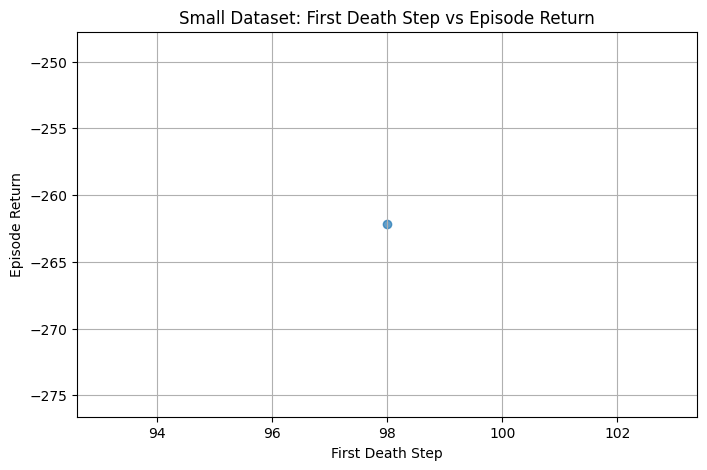

[OK] Saved plot: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/small/small_final_alive_preterminal_hist_v5.png


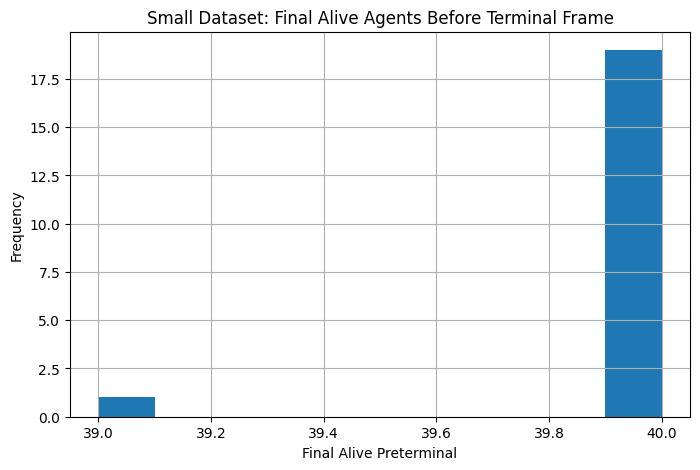

[OK] Saved plot: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/small/small_avg_alive_fraction_corrected_v5.png


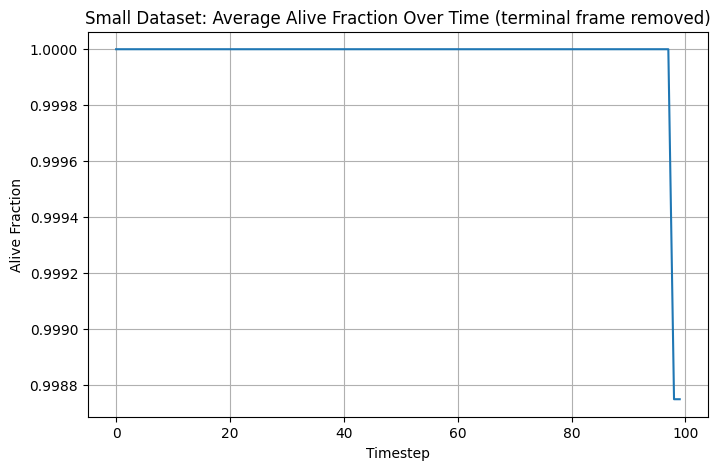


Corrected Extinction Analysis Summary
Episodes analyzed: 20
Used terminal frame removed: True
Mean initial alive: 40.0
Mean final alive preterminal: 39.95
Median final alive preterminal: 40.0
Mean alive fraction final preterminal: 0.9988
Fraction fully extinct preterminal: 0.0
Mean first death step: 98.0
Median first death step: 98.0
Correlation: first_death_step vs return_sum: not defined (insufficient variance)
[OK] Saved corrected extinction analysis CSV: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/medium/medium_extinction_analysis_corrected_v5.csv
[OK] Saved plot: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/medium/medium_first_death_vs_return_corrected_v5.png


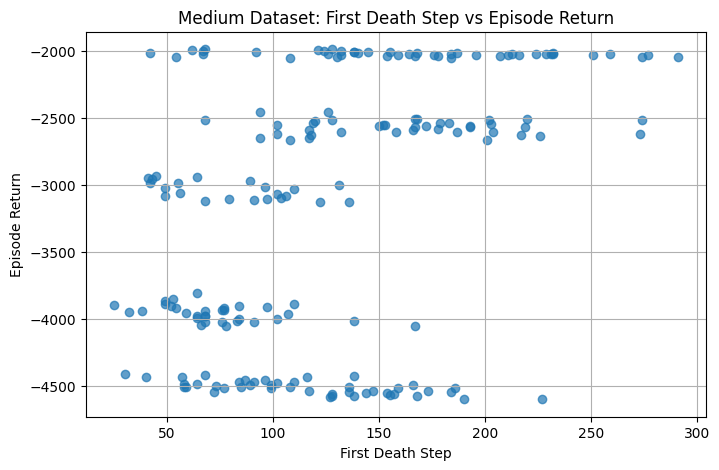

[OK] Saved plot: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/medium/medium_final_alive_preterminal_hist_v5.png


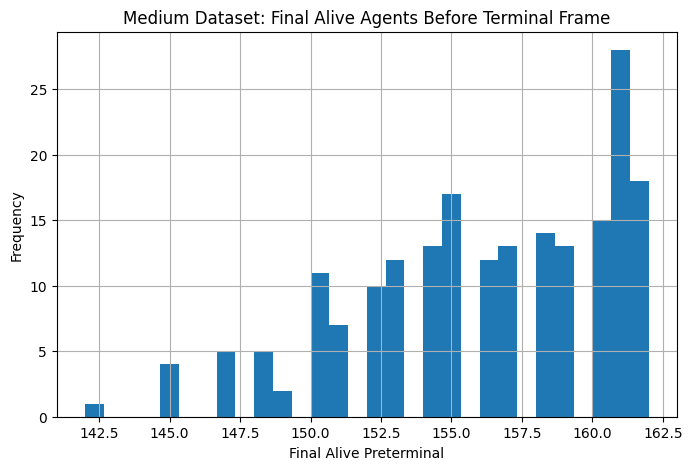

[OK] Saved plot: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/medium/medium_avg_alive_fraction_corrected_v5.png


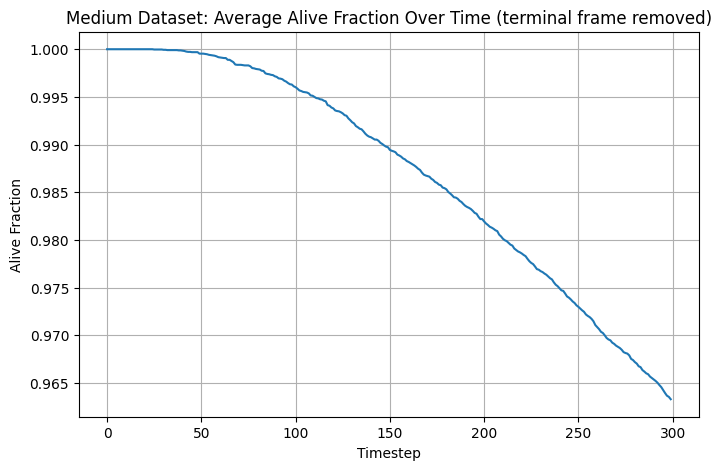


Corrected Extinction Analysis Summary
Episodes analyzed: 200
Used terminal frame removed: True
Mean initial alive: 162.0
Mean final alive preterminal: 156.06
Median final alive preterminal: 157.0
Mean alive fraction final preterminal: 0.9633
Fraction fully extinct preterminal: 0.0
Mean first death step: 126.52
Median first death step: 119.5
Correlation: first_death_step vs return_sum: 0.4255
[OK] Saved corrected extinction analysis CSV: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/large/large_extinction_analysis_corrected_v5.csv
[OK] Saved plot: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/large/large_first_death_vs_return_corrected_v5.png


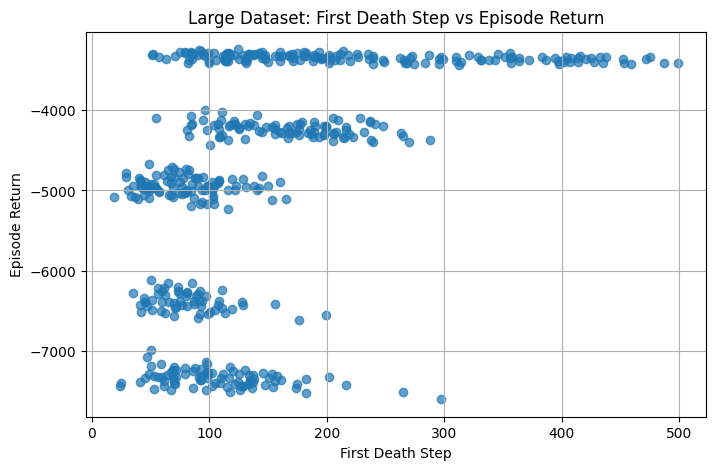

[OK] Saved plot: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/large/large_final_alive_preterminal_hist_v5.png


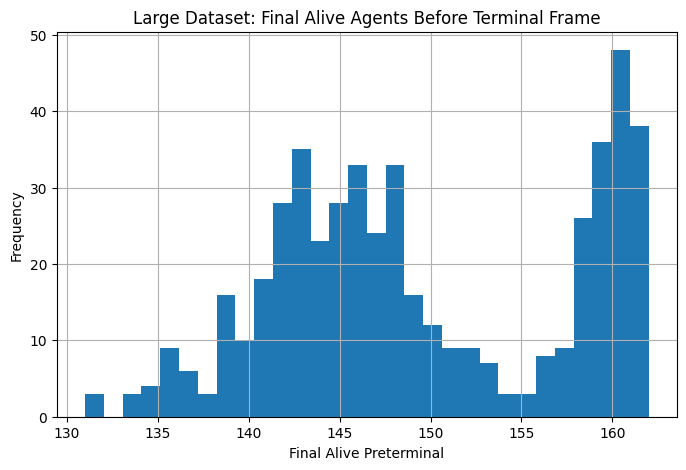

[OK] Saved plot: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/large/large_avg_alive_fraction_corrected_v5.png


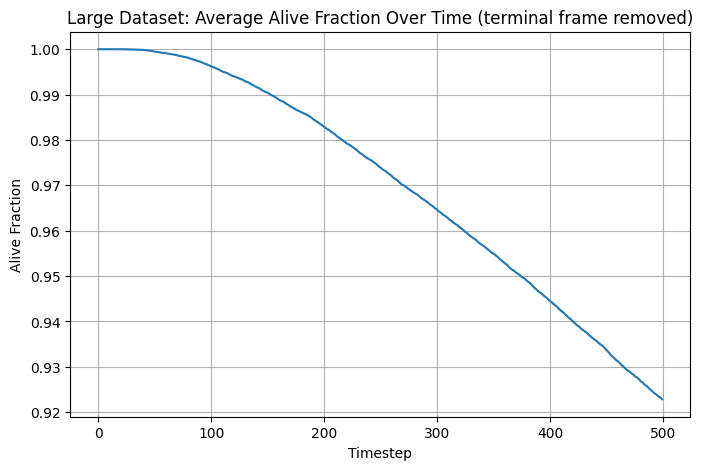


Corrected Extinction Analysis Summary
Episodes analyzed: 500
Used terminal frame removed: True
Mean initial alive: 162.0
Mean final alive preterminal: 149.5
Median final alive preterminal: 148.0
Mean alive fraction final preterminal: 0.9229
Fraction fully extinct preterminal: 0.0
Mean first death step: 148.71
Median first death step: 118.0
Correlation: first_death_step vs return_sum: 0.4832


,shard,episode_id,episode_steps,episode_return_sum,initial_alive,final_alive_preterminal,alive_fraction_final_preterminal,fully_extinct_preterminal,preterminal_extinction_step,first_death_step,first_50pct_loss_step,first_90pct_loss_step,analysis_horizon_steps,used_terminal_frame_removed
0,battle_v4-large_part000-v5,0,500,-6205.010742,162,135,0.833333,False,NaN,73.0,NaN,NaN,500,True
1,battle_v4-large_part000-v5,1,500,-3388.400391,162,162,1.000000,False,NaN,NaN,NaN,NaN,500,True
2,battle_v4-large_part000-v5,2,500,-7315.075195,162,146,0.901235,False,NaN,202.0,NaN,NaN,500,True
3,battle_v4-large_part000-v5,3,500,-4142.675293,162,141,0.870370,False,NaN,121.0,NaN,NaN,500,True
4,battle_v4-large_part000-v5,4,500,-7475.930664,162,148,0.913580,False,NaN,126.0,NaN,NaN,500,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,battle_v4-large_part019-v5,20,500,-6386.820312,162,139,0.858025,False,NaN,66.0,NaN,NaN,500,True
496,battle_v4-large_part019-v5,21,500,-3353.600098,162,162,1.000000,False,NaN,NaN,NaN,NaN,500,True
497,battle_v4-large_part019-v5,22,500,-4080.450195,162,139,0.858025,False,NaN,84.0,NaN,NaN,500,True
498,battle_v4-large_part019-v5,23,500,-7367.270508,162,149,0.919753,False,NaN,156.0,NaN,NaN,500,True


In [ ]:
extinction_analysis_corrected(size_name="small", version=5)
extinction_analysis_corrected(size_name="medium", version=5)
extinction_analysis_corrected(size_name="large", version=5)

[OK] Saved plot: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/small/small_survival_curves_corrected_v5.png


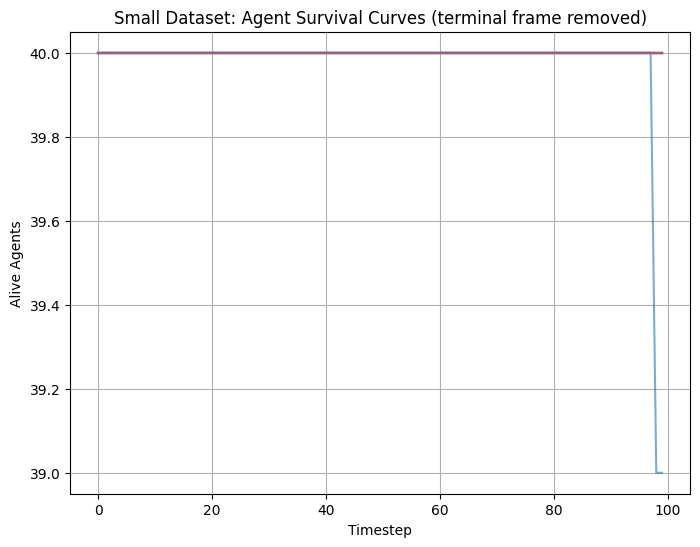

[OK] Saved plot: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/medium/medium_survival_curves_corrected_v5.png


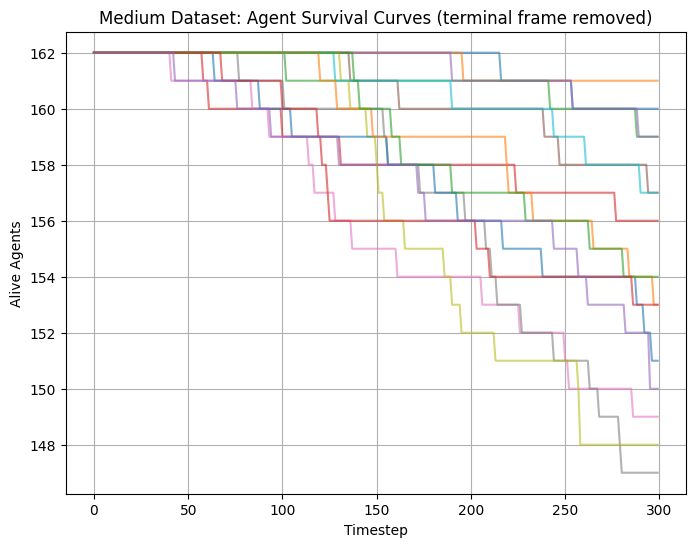

[OK] Saved plot: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/large/large_survival_curves_corrected_v5.png


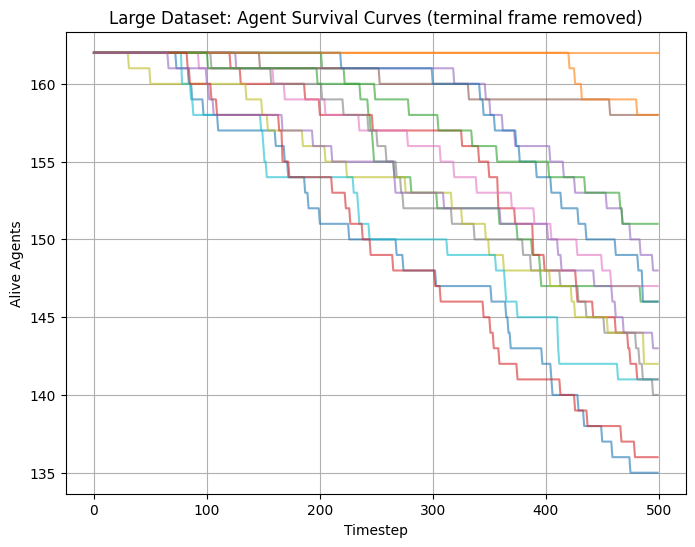

PosixPath('/content/drive/MyDrive/eecs_295p_gnn_research_report/uci/large/large_survival_curves_corrected_v5.png')

In [ ]:
plot_survival_curve_corrected(size_name="small", version=5, max_episodes=15)
plot_survival_curve_corrected(size_name="medium", version=5, max_episodes=15)
plot_survival_curve_corrected(size_name="large", version=5, max_episodes=15)

In [ ]:
import numpy as np
import pandas as pd
import minari
from pathlib import Path


def build_corrected_episode_metadata(
    dataset_root="/content/drive/MyDrive/eecs_295p_gnn_research_report/uci",
    size_name="medium",
    version=5,
    save_per_shard=True,
    save_combined=True,
    ignore_terminal_frame=True,
):
    """
    Build corrected episode metadata with policy names and corrected survival metrics.

    Outputs per shard:
      corrected_episode_metadata.csv

    Outputs per size folder:
      {size_name}_combined_corrected_metadata_v{version}.csv
    """

    dataset_root = Path(dataset_root)
    size_dir = dataset_root / size_name
    shard_dirs = sorted(size_dir.glob(f"battle_v4-{size_name}_part*-v{version}"))

    if not shard_dirs:
        print("No shards found.")
        print("Expected pattern:", size_dir / f"battle_v4-{size_name}_part*-v{version}")
        return None

    all_rows = []

    for shard in shard_dirs:
        print(f"Processing shard: {shard.name}")

        # Try to load original metadata if present
        meta_csv = shard / "episode_metadata.csv"
        original_meta = None
        if meta_csv.exists():
            try:
                original_meta = pd.read_csv(meta_csv)
            except Exception as e:
                print(f"[WARN] Could not read {meta_csv}: {e}")

        # Load Minari shard
        try:
            ds = minari.load_dataset(str(shard))
        except Exception as e:
            print(f"[WARN] Could not load Minari dataset from {shard}: {e}")
            continue

        shard_rows = []

        for ep_idx, ep in enumerate(ds.iterate_episodes()):
            if not isinstance(ep.observations, dict) or "agent_mask" not in ep.observations:
                continue

            mask = np.asarray(ep.observations["agent_mask"])
            rewards = np.asarray(ep.rewards)
            actions = np.asarray(ep.actions)

            if mask.ndim != 2:
                continue

            alive_counts_full = mask.sum(axis=1).astype(np.float32)

            # Remove final appended terminal frame if desired
            if ignore_terminal_frame and len(alive_counts_full) > 1:
                alive_counts = alive_counts_full[:-1]
            else:
                alive_counts = alive_counts_full

            if len(alive_counts) == 0:
                continue

            initial_alive = int(alive_counts[0])
            final_alive_preterminal = int(alive_counts[-1])
            alive_fraction_final_preterminal = (
                final_alive_preterminal / max(1, initial_alive)
            )

            # extinction before final appended frame
            extinction_step = next((i for i, v in enumerate(alive_counts) if v == 0), None)
            fully_extinct_preterminal = extinction_step is not None

            first_death_step = next((i for i, v in enumerate(alive_counts) if v < initial_alive), None)
            first_50pct_loss_step = next((i for i, v in enumerate(alive_counts) if v <= 0.5 * initial_alive), None)
            first_90pct_loss_step = next((i for i, v in enumerate(alive_counts) if v <= 0.1 * initial_alive), None)

            episode_steps = int(len(rewards))
            episode_return_sum = float(rewards.sum())

            # infer attack action index
            attack_action_index = int(actions.max()) if actions.size > 0 else 0
            attack_count = int((actions == attack_action_index).sum())
            total_actions_taken = int(actions.size)
            attack_ratio = attack_count / max(1, total_actions_taken)

            row = {
                "shard": shard.name,
                "episode_id": ep_idx,
                "size_name": size_name,
                "version": version,
                "used_terminal_frame_removed": bool(ignore_terminal_frame),

                "episode_steps": episode_steps,
                "episode_return_sum": episode_return_sum,

                "initial_alive": initial_alive,
                "final_alive_preterminal": final_alive_preterminal,
                "alive_fraction_final_preterminal": alive_fraction_final_preterminal,
                "fully_extinct_preterminal": bool(fully_extinct_preterminal),
                "preterminal_extinction_step": int(extinction_step) if extinction_step is not None else np.nan,
                "first_death_step": int(first_death_step) if first_death_step is not None else np.nan,
                "first_50pct_loss_step": int(first_50pct_loss_step) if first_50pct_loss_step is not None else np.nan,
                "first_90pct_loss_step": int(first_90pct_loss_step) if first_90pct_loss_step is not None else np.nan,
                "analysis_horizon_steps": int(len(alive_counts)),

                "attack_action_index": attack_action_index,
                "attack_count": attack_count,
                "total_actions_taken": total_actions_taken,
                "attack_ratio": attack_ratio,
                "return_per_step": episode_return_sum / max(1, episode_steps),
                "return_per_action": episode_return_sum / max(1, total_actions_taken),
                "attack_efficiency": episode_return_sum / attack_count if attack_count > 0 else np.nan,

                "policy_name": "unknown",
                "global_episode": np.nan,
                "local_episode_in_part": ep_idx,
                "map_size": np.nan,
                "max_cycles": np.nan,
            }

            # Merge in original metadata if available
            if original_meta is not None and ep_idx < len(original_meta):
                src = original_meta.iloc[ep_idx].to_dict()

                # Prefer original metadata values where available
                for key in [
                    "policy_name",
                    "global_episode",
                    "local_episode_in_part",
                    "map_size",
                    "max_cycles",
                    "part_id",
                    "attack_action_index",
                    "attack_count",
                    "total_actions_taken",
                ]:
                    if key in src and pd.notna(src[key]):
                        row[key] = src[key]

                # If original attack counts exist, recompute ratios using those
                if "attack_count" in src and "total_actions_taken" in src:
                    if pd.notna(src["attack_count"]) and pd.notna(src["total_actions_taken"]):
                        row["attack_count"] = int(src["attack_count"])
                        row["total_actions_taken"] = int(src["total_actions_taken"])
                        row["attack_ratio"] = row["attack_count"] / max(1, row["total_actions_taken"])
                        row["attack_efficiency"] = (
                            row["episode_return_sum"] / row["attack_count"]
                            if row["attack_count"] > 0 else np.nan
                        )

            shard_rows.append(row)
            all_rows.append(row)

        shard_df = pd.DataFrame(shard_rows)

        if save_per_shard and len(shard_df) > 0:
            out_csv = shard / "corrected_episode_metadata.csv"
            shard_df.to_csv(out_csv, index=False)
            print(f"[OK] Saved corrected shard CSV: {out_csv}")

    if len(all_rows) == 0:
        print("No valid episodes found.")
        return None

    combined_df = pd.DataFrame(all_rows)

    # nice column ordering
    preferred_cols = [
        "shard",
        "episode_id",
        "global_episode",
        "local_episode_in_part",
        "policy_name",
        "size_name",
        "version",
        "map_size",
        "max_cycles",
        "episode_steps",
        "episode_return_sum",
        "return_per_step",
        "return_per_action",
        "attack_efficiency",
        "attack_action_index",
        "attack_count",
        "total_actions_taken",
        "attack_ratio",
        "initial_alive",
        "final_alive_preterminal",
        "alive_fraction_final_preterminal",
        "fully_extinct_preterminal",
        "preterminal_extinction_step",
        "first_death_step",
        "first_50pct_loss_step",
        "first_90pct_loss_step",
        "analysis_horizon_steps",
        "used_terminal_frame_removed",
    ]

    ordered_cols = [c for c in preferred_cols if c in combined_df.columns] + [
        c for c in combined_df.columns if c not in preferred_cols
    ]
    combined_df = combined_df[ordered_cols]

    if save_combined:
        combined_csv = size_dir / f"{size_name}_combined_corrected_metadata_v{version}.csv"
        combined_df.to_csv(combined_csv, index=False)
        print(f"[OK] Saved combined corrected CSV: {combined_csv}")

    print()
    print("======================================")
    print("Corrected Metadata Summary")
    print("======================================")
    print("Episodes:", len(combined_df))
    print("Policies:")
    print(combined_df["policy_name"].value_counts(dropna=False))
    print()
    print("Mean final alive preterminal by policy:")
    print(combined_df.groupby("policy_name")["final_alive_preterminal"].mean().round(2))
    print()
    print("Mean first death step by policy:")
    print(combined_df.groupby("policy_name")["first_death_step"].mean().round(2))
    print()
    print("Mean attack ratio by policy:")
    print(combined_df.groupby("policy_name")["attack_ratio"].mean().round(4))
    print("======================================")

    return combined_df

In [ ]:
corr_small = build_corrected_episode_metadata(
    size_name="small",
    version=5,
)
corr_small = build_corrected_episode_metadata(
    size_name="medium",
    version=5,
)
corr_small = build_corrected_episode_metadata(
    size_name="large",
    version=5,
)

Processing shard: battle_v4-small_part000-v5
[OK] Saved corrected shard CSV: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/small/battle_v4-small_part000-v5/corrected_episode_metadata.csv
Processing shard: battle_v4-small_part001-v5
[OK] Saved corrected shard CSV: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/small/battle_v4-small_part001-v5/corrected_episode_metadata.csv
[OK] Saved combined corrected CSV: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/small/small_combined_corrected_metadata_v5.csv

Corrected Metadata Summary
Episodes: 20
Policies:
policy_name
aggressive           7
retreat              5
group_then_attack    3
random               3
heuristic            1
mixed                1
Name: count, dtype: int64

Mean final alive preterminal by policy:
policy_name
aggressive           40.00
group_then_attack    39.67
heuristic            40.00
mixed                40.00
random               40.00
retreat              40.00
Name: final_alive_prete

add in fixed final alive agents metadata

In [ ]:
import os
import json
from pathlib import Path

import minari
import numpy as np
import pandas as pd


# ============================================================
# CONFIG
# ============================================================

MINARI_ROOT = "/content/drive/MyDrive/eecs_295p_gnn_research_report"
DATASET_ROOT = f"{MINARI_ROOT}/uci"

os.environ["MINARI_DATASETS_PATH"] = MINARI_ROOT
print("MINARI_DATASETS_PATH =", os.environ["MINARI_DATASETS_PATH"])


# ============================================================
# HELPERS
# ============================================================

def load_minari_dataset_from_dir(dataset_dir: Path):
    dataset_dir = Path(dataset_dir).resolve()
    minari_root = Path(os.environ["MINARI_DATASETS_PATH"]).resolve()
    dataset_id = str(dataset_dir.relative_to(minari_root))
    return minari.load_dataset(dataset_id)


def compute_episode_final_alive_from_obs(ep):
    """
    Correct final alive count:
      use agent_mask[-2] because agent_mask[-1] is the terminal all-zero mask
    """
    obs = ep.observations
    agent_mask = np.asarray(obs["agent_mask"])

    if agent_mask.ndim != 2:
        raise ValueError(f"Expected agent_mask shape (T+1, N), got {agent_mask.shape}")

    if agent_mask.shape[0] >= 2:
        return int(agent_mask[-2].sum())
    return 0


def patch_one_shard_metadata(dataset_dir: Path, verbose=True):
    dataset_dir = Path(dataset_dir)

    meta_csv = dataset_dir / "episode_metadata.csv"
    summary_json = dataset_dir / "shard_summary.json"

    if not meta_csv.exists():
        print(f"[SKIP] No episode_metadata.csv in {dataset_dir}")
        return None

    ds = load_minari_dataset_from_dir(dataset_dir)
    meta_df = pd.read_csv(meta_csv)

    corrected_final_alive = []
    episode_indices = []

    for ep_idx, ep in enumerate(ds.iterate_episodes()):
        corrected_final_alive.append(compute_episode_final_alive_from_obs(ep))
        episode_indices.append(ep_idx)

    if len(corrected_final_alive) != len(meta_df):
        raise RuntimeError(
            f"Episode count mismatch in {dataset_dir.name}: "
            f"metadata rows={len(meta_df)} vs dataset episodes={len(corrected_final_alive)}"
        )

    old_vals = meta_df["final_alive_agents"].copy() if "final_alive_agents" in meta_df.columns else None

    meta_df["final_alive_agents"] = corrected_final_alive

    # Optional traceability columns
    meta_df["final_alive_corrected_from"] = "agent_mask[-2]"
    meta_df["metadata_source"] = "episode_metadata.csv"

    meta_df.to_csv(meta_csv, index=False)

    if summary_json.exists():
        with open(summary_json, "r") as f:
            js = json.load(f)

        js["final_alive_correction"] = {
            "method": "agent_mask[-2]",
            "reason": "agent_mask[-1] is terminal all-zero mask",
        }
        js["avg_final_alive_agents"] = float(np.mean(corrected_final_alive)) if corrected_final_alive else 0.0
        js["min_final_alive_agents"] = int(np.min(corrected_final_alive)) if corrected_final_alive else 0
        js["max_final_alive_agents"] = int(np.max(corrected_final_alive)) if corrected_final_alive else 0

        # Optional per-policy aggregate from metadata CSV
        if "policy_name" in meta_df.columns:
            by_policy = (
                meta_df.groupby("policy_name")["final_alive_agents"]
                .mean()
                .round(4)
                .to_dict()
            )
            js["avg_final_alive_agents_by_policy"] = by_policy

        with open(summary_json, "w") as f:
            json.dump(js, f, indent=2)

    if verbose:
        print(f"[PATCHED] {dataset_dir.name}")
        if old_vals is not None:
            old_mean = float(pd.to_numeric(old_vals, errors="coerce").fillna(0).mean())
            new_mean = float(np.mean(corrected_final_alive)) if corrected_final_alive else 0.0
            print(f"  old avg final_alive_agents: {old_mean:.4f}")
            print(f"  new avg final_alive_agents: {new_mean:.4f}")
        print(f"  rows updated: {len(meta_df)}")

    return {
        "dataset_dir": str(dataset_dir),
        "num_rows": len(meta_df),
        "avg_final_alive_agents": float(np.mean(corrected_final_alive)) if corrected_final_alive else 0.0,
    }


def patch_size_metadata(
    dataset_root="/content/drive/MyDrive/eecs_295p_gnn_research_report/uci",
    size_name="large",
    version=5,
    verbose=True,
):
    dataset_root = Path(dataset_root)
    size_dir = dataset_root / size_name
    shard_dirs = sorted(size_dir.glob(f"battle_v4-{size_name}_part*-v{version}"))

    if len(shard_dirs) == 0:
        print(f"[NONE] No shards found for size={size_name}, version={version}")
        return pd.DataFrame()

    results = []
    print(f"\n=== Patching {size_name} v{version} ===")

    for shard_dir in shard_dirs:
        out = patch_one_shard_metadata(shard_dir, verbose=verbose)
        if out is not None:
            results.append(out)

    results_df = pd.DataFrame(results)

    if len(results_df) > 0:
        print(f"\n[DONE] {size_name} v{version}")
        print(results_df)
    return results_df


def patch_all_sizes(
    dataset_root="/content/drive/MyDrive/eecs_295p_gnn_research_report/uci",
    version=5,
    sizes=("small", "medium", "large"),
    verbose=True,
):
    all_results = []

    for size_name in sizes:
        df = patch_size_metadata(
            dataset_root=dataset_root,
            size_name=size_name,
            version=version,
            verbose=verbose,
        )
        if len(df) > 0:
            df["size_name"] = size_name
            all_results.append(df)

    if len(all_results) == 0:
        print("[DONE] No shards patched.")
        return pd.DataFrame()

    final_df = pd.concat(all_results, ignore_index=True)

    print("\n======================================")
    print("METADATA PATCH COMPLETE")
    print("======================================")
    print(final_df)

    return final_df

MINARI_DATASETS_PATH = /content/drive/MyDrive/eecs_295p_gnn_research_report


In [ ]:
patch_results_df = patch_all_sizes(
    dataset_root="/content/drive/MyDrive/eecs_295p_gnn_research_report/uci",
    version=5,
    sizes=("small", "medium", "large"),
    verbose=True,
)


=== Patching small v5 ===
[PATCHED] battle_v4-small_part000-v5
  old avg final_alive_agents: 0.0000
  new avg final_alive_agents: 40.0000
  rows updated: 10
[PATCHED] battle_v4-small_part001-v5
  old avg final_alive_agents: 0.0000
  new avg final_alive_agents: 39.9000
  rows updated: 10

[DONE] small v5
                                         dataset_dir  num_rows  \
0  /content/drive/MyDrive/eecs_295p_gnn_research_...        10   
1  /content/drive/MyDrive/eecs_295p_gnn_research_...        10   

   avg_final_alive_agents  
0                    40.0  
1                    39.9  

=== Patching medium v5 ===
[PATCHED] battle_v4-medium_part000-v5
  old avg final_alive_agents: 0.0000
  new avg final_alive_agents: 155.7600
  rows updated: 25
[PATCHED] battle_v4-medium_part001-v5
  old avg final_alive_agents: 0.0000
  new avg final_alive_agents: 157.8000
  rows updated: 25
[PATCHED] battle_v4-medium_part002-v5
  old avg final_alive_agents: 0.0000
  new avg final_alive_agents: 155.9200
  r

###lots from datasets

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


def plot_dataset_metadata(
    meta=None,
    dataset_root="/content/drive/MyDrive/eecs_295p_gnn_research_report/uci",
    size_name="medium",
    version=5,
    save_plots=True,
    show_plots=True,
):
    """
    Generate report-ready plots from combined metadata produced by inspect_dataset_size().

    Plots:
      1. Episodes per policy
      2. Avg episode return by policy
      3. Avg attack ratio by policy
      4. Avg episode length by policy
      5. Avg final alive agents by policy
      6. Scatter: attack ratio vs episode return
      7. Histogram: episode return distribution
      8. Histogram: attack ratio distribution
    """

    dataset_root = Path(dataset_root)
    size_dir = dataset_root / size_name
    plots_dir = size_dir / f"plots_v{version}"
    plots_dir.mkdir(parents=True, exist_ok=True)

    if meta is None:
        combined_csv = size_dir / f"{size_name}_combined_metadata_v{version}.csv"
        if not combined_csv.exists():
            print("Combined metadata CSV not found:", combined_csv)
            print("Run inspect_dataset_size(...) first.")
            return None
        meta = pd.read_csv(combined_csv)

    if len(meta) == 0:
        print("Metadata is empty.")
        return None

    if "policy_name" not in meta.columns:
        meta["policy_name"] = "unknown"

    # normalize expected numeric columns if missing
    if "attack_ratio" not in meta.columns and {"attack_count", "total_actions_taken"}.issubset(meta.columns):
        meta["attack_ratio"] = meta["attack_count"] / meta["total_actions_taken"].clip(lower=1)

    if "return_per_step" not in meta.columns and {"episode_return_sum", "episode_steps"}.issubset(meta.columns):
        meta["return_per_step"] = meta["episode_return_sum"] / meta["episode_steps"].clip(lower=1)

    def _savefig(name):
        path = plots_dir / name
        plt.savefig(path, bbox_inches="tight", dpi=200)
        print(f"[OK] Saved: {path}")

    # 1) Episodes per policy
    plt.figure(figsize=(8, 5))
    vc = meta["policy_name"].value_counts().sort_index()
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(f"{size_name.capitalize()} Dataset: Episodes per Policy")
    plt.xlabel("Policy")
    plt.ylabel("Episode Count")
    plt.xticks(rotation=30, ha="right")
    if save_plots:
        _savefig("01_episodes_per_policy.png")
    if show_plots:
        plt.show()
    else:
        plt.close()

    # 2) Average episode return by policy
    if "episode_return_sum" in meta.columns:
        plt.figure(figsize=(8, 5))
        s = meta.groupby("policy_name")["episode_return_sum"].mean().sort_index()
        plt.bar(s.index.astype(str), s.values)
        plt.title(f"{size_name.capitalize()} Dataset: Average Episode Return by Policy")
        plt.xlabel("Policy")
        plt.ylabel("Average Episode Return")
        plt.xticks(rotation=30, ha="right")
        if save_plots:
            _savefig("02_avg_return_by_policy.png")
        if show_plots:
            plt.show()
        else:
            plt.close()

    # 3) Average attack ratio by policy
    if "attack_ratio" in meta.columns:
        plt.figure(figsize=(8, 5))
        s = meta.groupby("policy_name")["attack_ratio"].mean().sort_index()
        plt.bar(s.index.astype(str), s.values)
        plt.title(f"{size_name.capitalize()} Dataset: Average Attack Ratio by Policy")
        plt.xlabel("Policy")
        plt.ylabel("Average Attack Ratio")
        plt.xticks(rotation=30, ha="right")
        if save_plots:
            _savefig("03_avg_attack_ratio_by_policy.png")
        if show_plots:
            plt.show()
        else:
            plt.close()

    # 4) Average episode length by policy
    if "episode_steps" in meta.columns:
        plt.figure(figsize=(8, 5))
        s = meta.groupby("policy_name")["episode_steps"].mean().sort_index()
        plt.bar(s.index.astype(str), s.values)
        plt.title(f"{size_name.capitalize()} Dataset: Average Episode Length by Policy")
        plt.xlabel("Policy")
        plt.ylabel("Average Episode Length")
        plt.xticks(rotation=30, ha="right")
        if save_plots:
            _savefig("04_avg_episode_length_by_policy.png")
        if show_plots:
            plt.show()
        else:
            plt.close()

    # 5) Average final alive agents by policy
    if "final_alive_agents" in meta.columns:
        plt.figure(figsize=(8, 5))
        s = meta.groupby("policy_name")["final_alive_agents"].mean().sort_index()
        plt.bar(s.index.astype(str), s.values)
        plt.title(f"{size_name.capitalize()} Dataset: Average Final Alive Agents by Policy")
        plt.xlabel("Policy")
        plt.ylabel("Average Final Alive Agents")
        plt.xticks(rotation=30, ha="right")
        if save_plots:
            _savefig("05_avg_final_alive_by_policy.png")
        if show_plots:
            plt.show()
        else:
            plt.close()

    # 6) Scatter: attack ratio vs episode return
    if {"attack_ratio", "episode_return_sum"}.issubset(meta.columns):
        plt.figure(figsize=(8, 5))
        for policy in sorted(meta["policy_name"].dropna().unique()):
            sub = meta[meta["policy_name"] == policy]
            plt.scatter(sub["attack_ratio"], sub["episode_return_sum"], label=str(policy), alpha=0.7)
        plt.title(f"{size_name.capitalize()} Dataset: Attack Ratio vs Episode Return")
        plt.xlabel("Attack Ratio")
        plt.ylabel("Episode Return")
        plt.legend()
        if save_plots:
            _savefig("06_attack_ratio_vs_return.png")
        if show_plots:
            plt.show()
        else:
            plt.close()

    # 7) Histogram: episode return distribution
    if "episode_return_sum" in meta.columns:
        plt.figure(figsize=(8, 5))
        plt.hist(meta["episode_return_sum"].dropna(), bins=30)
        plt.title(f"{size_name.capitalize()} Dataset: Episode Return Distribution")
        plt.xlabel("Episode Return")
        plt.ylabel("Frequency")
        if save_plots:
            _savefig("07_episode_return_distribution.png")
        if show_plots:
            plt.show()
        else:
            plt.close()

    # 8) Histogram: attack ratio distribution
    if "attack_ratio" in meta.columns:
        plt.figure(figsize=(8, 5))
        plt.hist(meta["attack_ratio"].dropna(), bins=30)
        plt.title(f"{size_name.capitalize()} Dataset: Attack Ratio Distribution")
        plt.xlabel("Attack Ratio")
        plt.ylabel("Frequency")
        if save_plots:
            _savefig("08_attack_ratio_distribution.png")
        if show_plots:
            plt.show()
        else:
            plt.close()

    # 9) Optional: return per step by policy
    if "return_per_step" in meta.columns:
        plt.figure(figsize=(8, 5))
        s = meta.groupby("policy_name")["return_per_step"].mean().sort_index()
        plt.bar(s.index.astype(str), s.values)
        plt.title(f"{size_name.capitalize()} Dataset: Average Return per Step by Policy")
        plt.xlabel("Policy")
        plt.ylabel("Average Return per Step")
        plt.xticks(rotation=30, ha="right")
        if save_plots:
            _savefig("09_avg_return_per_step_by_policy.png")
        if show_plots:
            plt.show()
        else:
            plt.close()

    print()
    print("Plot generation complete.")
    print("Plots folder:", plots_dir)

    return plots_dir

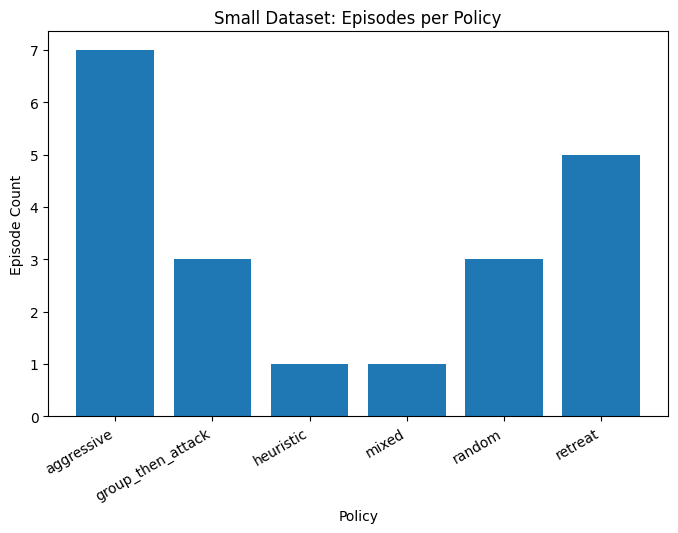

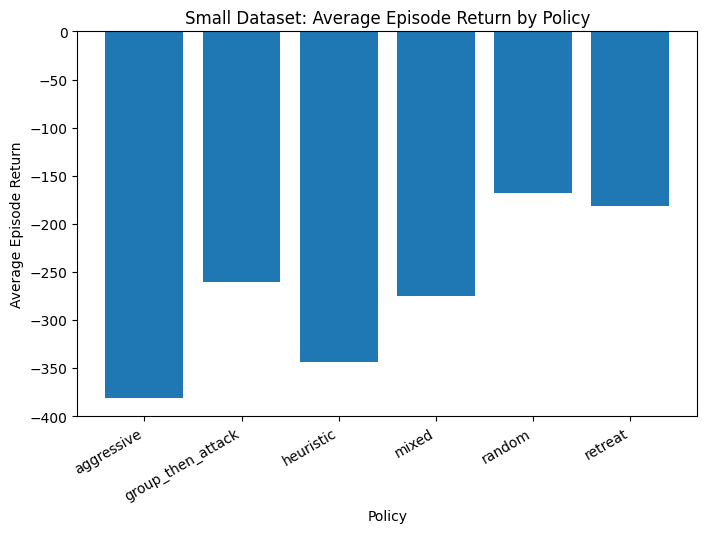

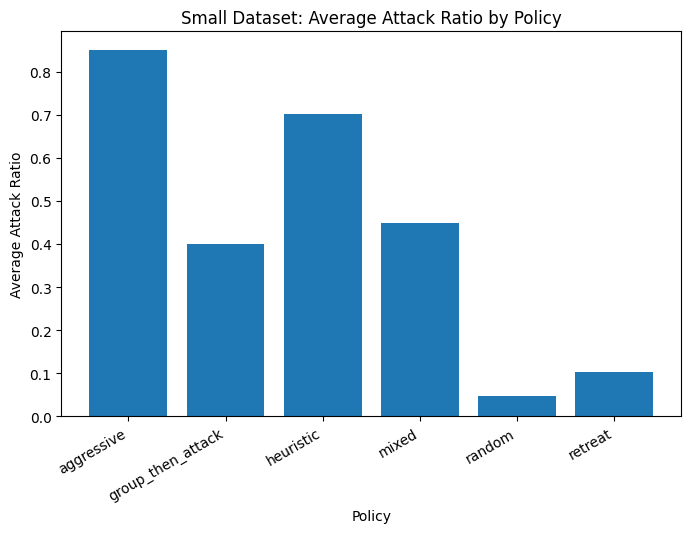

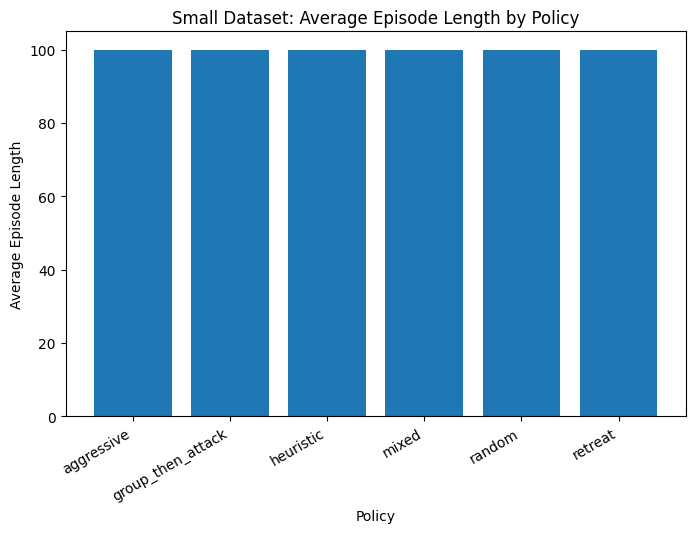

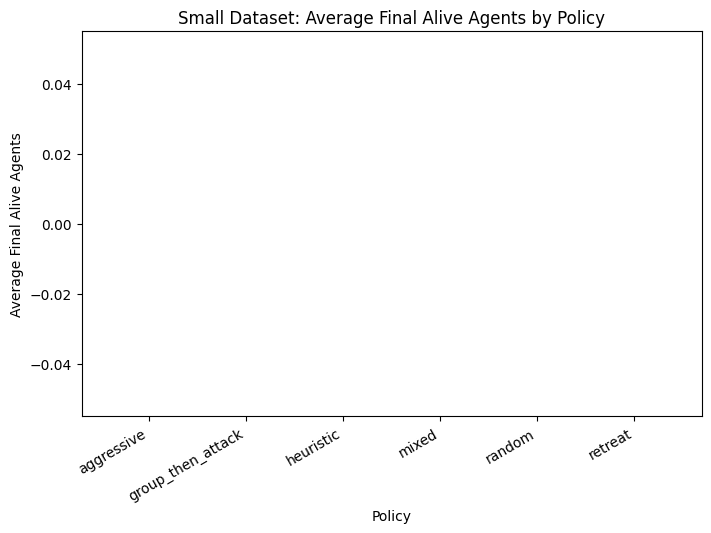

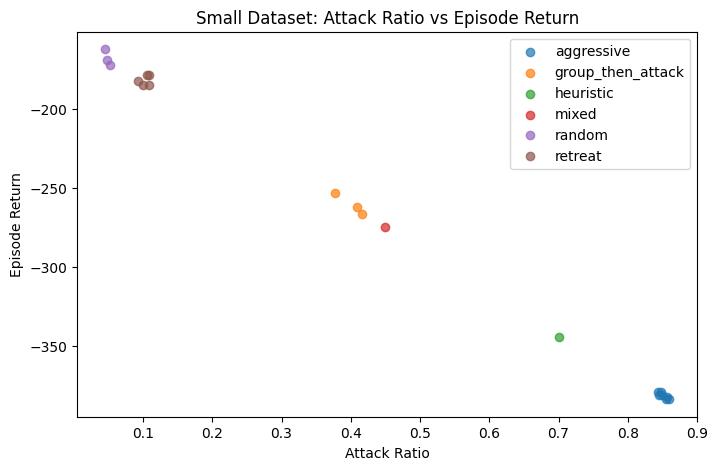

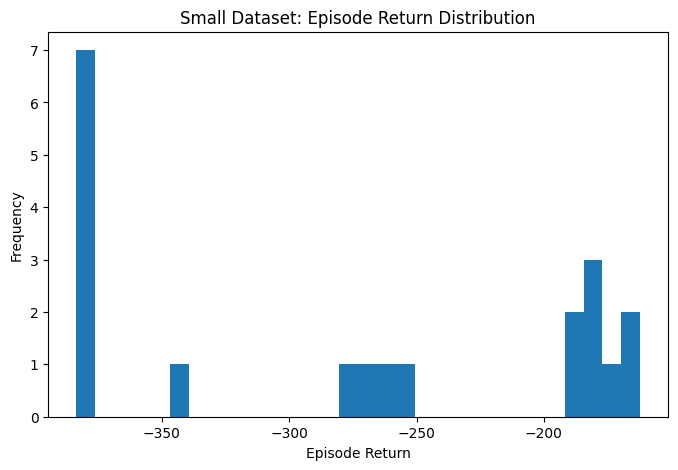

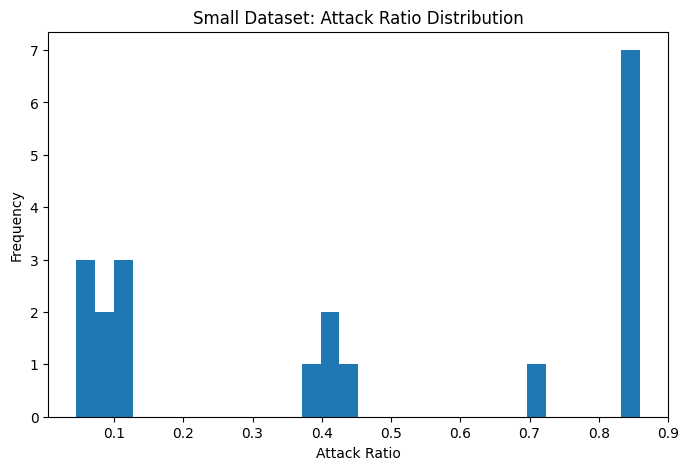

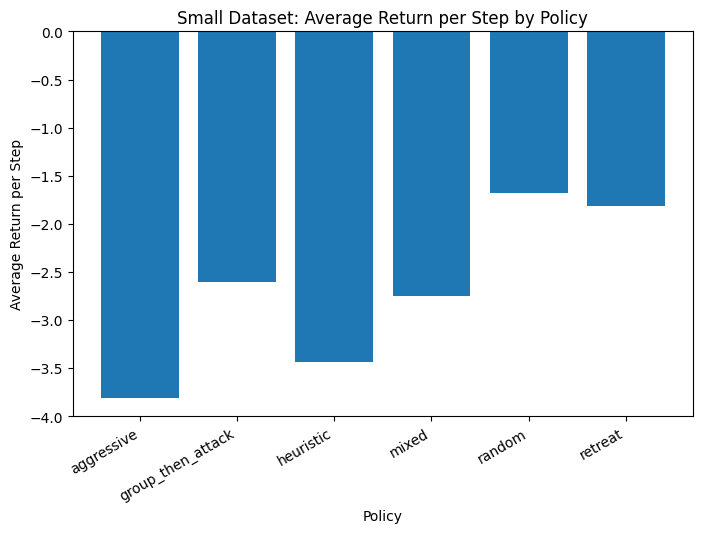


Plot generation complete.
Plots folder: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/small/plots_v5


PosixPath('/content/drive/MyDrive/eecs_295p_gnn_research_report/uci/small/plots_v5')

In [ ]:
plot_dataset_metadata(size_name="small",save_plots=False)

###compare v1 w/ v2

In [ ]:
from pathlib import Path
import pandas as pd

MODELS_V1 = Path("/content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models/v1")
MODELS_V2 = Path("/content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models/v2")

SIZES = ["small", "medium", "large"]

MODEL_SPECS = [
    {"algorithm_family": "baseline_dqn", "experiment_label": "random_v1",       "path": MODELS_V1 / "baseline_random_{size}.pt"},
    {"algorithm_family": "baseline_dqn", "experiment_label": "heuristic_v1",    "path": MODELS_V1 / "baseline_heuristic_{size}.pt"},
    {"algorithm_family": "baseline_dqn", "experiment_label": "mixed_v1",        "path": MODELS_V1 / "baseline_mixed_{size}.pt"},

    {"algorithm_family": "fast_dgn",     "experiment_label": "random_v1",       "path": MODELS_V1 / "dgn_random_{size}.pt"},
    {"algorithm_family": "fast_dgn",     "experiment_label": "heuristic_v1",    "path": MODELS_V1 / "dgn_heuristic_{size}.pt"},
    {"algorithm_family": "fast_dgn",     "experiment_label": "mixed_v1",        "path": MODELS_V1 / "dgn_mixed_{size}.pt"},

    {"algorithm_family": "baseline_dqn", "experiment_label": "mixed_policy_v2", "path": MODELS_V2 / "baseline_dqn_{size}_v5_best.pt"},
    {"algorithm_family": "fast_dgn",     "experiment_label": "mixed_policy_v2", "path": MODELS_V2 / "fast_dgn_{size}_v5_best.pt"},
]

rows = []
for spec in MODEL_SPECS:
    for size in SIZES:
        ckpt = Path(str(spec["path"]).format(size=size))
        rows.append({
            "algorithm_family": spec["algorithm_family"],
            "experiment_label": spec["experiment_label"],
            "size_name": size,
            "exists": ckpt.exists(),
            "checkpoint_path": str(ckpt),
        })

df = pd.DataFrame(rows)
display(df)

,algorithm_family,experiment_label,size_name,exists,checkpoint_path
0,baseline_dqn,random_v1,small,True,/content/drive/MyDrive/eecs_295p_gnn_research_...
1,baseline_dqn,random_v1,medium,True,/content/drive/MyDrive/eecs_295p_gnn_research_...
2,baseline_dqn,random_v1,large,True,/content/drive/MyDrive/eecs_295p_gnn_research_...
3,baseline_dqn,heuristic_v1,small,True,/content/drive/MyDrive/eecs_295p_gnn_research_...
4,baseline_dqn,heuristic_v1,medium,True,/content/drive/MyDrive/eecs_295p_gnn_research_...
5,baseline_dqn,heuristic_v1,large,True,/content/drive/MyDrive/eecs_295p_gnn_research_...
6,baseline_dqn,mixed_v1,small,True,/content/drive/MyDrive/eecs_295p_gnn_research_...
7,baseline_dqn,mixed_v1,medium,True,/content/drive/MyDrive/eecs_295p_gnn_research_...
8,baseline_dqn,mixed_v1,large,True,/content/drive/MyDrive/eecs_295p_gnn_research_...
9,fast_dgn,random_v1,small,True,/content/drive/MyDrive/eecs_295p_gnn_research_...


In [ ]:
# ============================================================
# UNIFIED MODEL EVALUATION + COMPARISON SUITE
# For:
#   v1 DQN: baseline_{policy}_{size}.pt
#   v1 DGN: dgn_{policy}_{size}.pt
#   v2 DQN: baseline_dqn_{size}_v5_best.pt
#   v2 DGN: fast_dgn_{size}_v5_best.pt
#
# Evaluates all checkpoints on shared eval datasets, saves CSV,
# and generates comparison plots.
#
# IMPORTANT:
# 1) Replace build_eval_dataloader_for_size(...) with your real eval loader.
# 2) Replace FastDGN_V2 with your exact v2 DGN class if needed.
# 3) If your batch uses edge_mask instead of edge_valid, this suite already handles both.
# ============================================================

import os
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

# ============================================================
# CONFIG
# ============================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

ROOT = Path("/content/drive/MyDrive/eecs_295p_gnn_research_report/uci")
MODELS_V1 = ROOT / "models" / "v1"
MODELS_V2 = ROOT / "models" / "v2"
OUT_ROOT = ROOT / "models" / "combined_eval_outputs"
PLOTS_ROOT = OUT_ROOT / "plots"
OUT_ROOT.mkdir(parents=True, exist_ok=True)
PLOTS_ROOT.mkdir(parents=True, exist_ok=True)

SIZES = ["small", "medium", "large"]
NUM_ACTIONS = 21
GAMMA = 0.99
BATCH_SIZE = 16

# ============================================================
# OPTIONAL: DATASET INSPECTION HELPERS
# ============================================================
def _safe_div(a, b):
    return a / b if b not in (0, 0.0, None) else 0.0


def reconstruct_episode_metadata_from_minari(
    shard_dir,
    attack_action_index=None,
    save_csv=True,
    overwrite=False,
):
    """
    Reconstruct episode metadata from a saved Minari shard.
    Saves episode_metadata_reconstructed.csv inside the shard folder.
    """
    import minari

    shard_dir = Path(shard_dir)
    out_csv = shard_dir / "episode_metadata_reconstructed.csv"

    if out_csv.exists() and not overwrite:
        return pd.read_csv(out_csv)

    try:
        ds = minari.load_dataset(str(shard_dir))
    except Exception as e:
        print(f"[WARN] Could not load Minari dataset from {shard_dir}: {e}")
        return None

    rows = []

    for ep_idx, ep in enumerate(ds.iterate_episodes()):
        actions = np.asarray(ep.actions)
        rewards = np.asarray(ep.rewards)

        episode_steps = int(actions.shape[0])
        episode_return_sum = float(rewards.sum())

        if attack_action_index is None:
            inferred_attack_idx = int(actions.max()) if actions.size > 0 else 0
        else:
            inferred_attack_idx = int(attack_action_index)

        attack_count = int((actions == inferred_attack_idx).sum())
        total_actions_taken = int(actions.size)

        final_alive_agents = None
        max_agents = None
        alive_fraction = None

        if hasattr(ep, "observations") and isinstance(ep.observations, dict):
            if "agent_mask" in ep.observations:
                mask = np.asarray(ep.observations["agent_mask"])
                if mask.ndim >= 2:
                    final_alive_agents = int(mask[-1].sum())
                    max_agents = int(mask.shape[1])
                    alive_fraction = _safe_div(final_alive_agents, max_agents)

        rows.append({
            "episode_id": ep_idx,
            "episode_steps": episode_steps,
            "episode_return_sum": episode_return_sum,
            "attack_action_index": inferred_attack_idx,
            "attack_count": attack_count,
            "total_actions_taken": total_actions_taken,
            "attack_ratio": _safe_div(attack_count, total_actions_taken),
            "return_per_step": _safe_div(episode_return_sum, episode_steps),
            "return_per_action": _safe_div(episode_return_sum, total_actions_taken),
            "attack_efficiency": _safe_div(episode_return_sum, attack_count),
            "final_alive_agents": final_alive_agents,
            "max_agents": max_agents,
            "alive_fraction": alive_fraction,
        })

    df = pd.DataFrame(rows)

    if save_csv:
        df.to_csv(out_csv, index=False)
        print(f"[OK] Saved reconstructed metadata: {out_csv}")

    return df


def inspect_dataset_size(
    dataset_root=str(ROOT),
    size_name="medium",
    version=5,
    reconstruct_if_missing=True,
    overwrite_reconstructed=False,
):
    """
    Inspect dataset shards and print policy / action / reward statistics.
    """
    dataset_root = Path(dataset_root)
    size_dir = dataset_root / size_name
    shard_dirs = sorted(size_dir.glob(f"battle_v4-{size_name}_part*-v{version}"))

    if len(shard_dirs) == 0:
        print("No dataset shards found.")
        print("Expected pattern:", size_dir / f"battle_v4-{size_name}_part*-v{version}")
        return None

    print("======================================")
    print("Dataset Inspection")
    print("======================================")
    print("Size:", size_name)
    print("Version:", version)
    print("Shard count:", len(shard_dirs))
    print()

    all_meta = []

    for shard in shard_dirs:
        meta_csv = shard / "episode_metadata.csv"
        recon_csv = shard / "episode_metadata_reconstructed.csv"
        summary_json = shard / "shard_summary.json"

        print("Shard:", shard.name)
        attack_idx_from_summary = None

        if summary_json.exists():
            with open(summary_json) as f:
                js = json.load(f)

            print("  episodes_in_part:", js.get("episodes_in_part"))
            print("  total_actions:", js.get("part_total_actions"))

            action_hist = js.get("part_action_hist")
            if action_hist:
                attack_idx_from_summary = js.get("attack_action_index")
                attack_total = action_hist[attack_idx_from_summary]
                total_actions = sum(action_hist)
                attack_ratio = attack_total / max(1, total_actions)
                print("  attack_action_index:", attack_idx_from_summary)
                print("  attack_ratio:", round(attack_ratio, 4))

        df = None
        if meta_csv.exists():
            df = pd.read_csv(meta_csv)
            df["metadata_source"] = "episode_metadata.csv"
        elif recon_csv.exists():
            df = pd.read_csv(recon_csv)
            df["metadata_source"] = "episode_metadata_reconstructed.csv"
        elif reconstruct_if_missing:
            df = reconstruct_episode_metadata_from_minari(
                shard,
                attack_action_index=attack_idx_from_summary,
                save_csv=True,
                overwrite=overwrite_reconstructed,
            )
            if df is not None:
                df["metadata_source"] = "reconstructed_now"

        if df is not None:
            if "attack_ratio" not in df.columns and {"attack_count", "total_actions_taken"}.issubset(df.columns):
                df["attack_ratio"] = df["attack_count"] / df["total_actions_taken"].clip(lower=1)
            if "return_per_step" not in df.columns and {"episode_return_sum", "episode_steps"}.issubset(df.columns):
                df["return_per_step"] = df["episode_return_sum"] / df["episode_steps"].clip(lower=1)
            if "return_per_action" not in df.columns and {"episode_return_sum", "total_actions_taken"}.issubset(df.columns):
                df["return_per_action"] = df["episode_return_sum"] / df["total_actions_taken"].clip(lower=1)
            if "attack_efficiency" not in df.columns and {"episode_return_sum", "attack_count"}.issubset(df.columns):
                df["attack_efficiency"] = df["episode_return_sum"] / df["attack_count"].replace(0, np.nan)
            if "alive_fraction" not in df.columns and {"final_alive_agents", "max_agents"}.issubset(df.columns):
                df["alive_fraction"] = df["final_alive_agents"] / df["max_agents"].replace(0, np.nan)

            df["shard"] = shard.name
            all_meta.append(df)

        print()

    if len(all_meta) == 0:
        print("No metadata found and reconstruction failed.")
        return None

    meta = pd.concat(all_meta, ignore_index=True)
    if "policy_name" not in meta.columns:
        meta["policy_name"] = "unknown"

    print("======================================")
    print("GLOBAL DATASET SUMMARY")
    print("======================================")
    print("Total Episodes:", len(meta))
    print("Unique Shards:", meta["shard"].nunique())
    print()
    print("Episodes per Policy")
    print(meta["policy_name"].value_counts(dropna=False))
    print()

    combined_csv = size_dir / f"{size_name}_combined_metadata_v{version}.csv"
    meta.to_csv(combined_csv, index=False)
    print(f"[OK] Saved combined metadata: {combined_csv}")
    return meta

# ============================================================
# v1 MODELS
# ============================================================
class BaselineDQN_V1(nn.Module):
    """
    v1 DQN:
      node_feat_dim=7
      hidden_dim=64
      num_actions=21
    """
    def __init__(self, node_feat_dim=7, hidden_dim=64, num_actions=21):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(node_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_actions),
        )

    def forward(self, node_feat, edge_index=None, edge_valid=None, agent_mask=None):
        B, N, Fdim = node_feat.shape
        x = node_feat.reshape(B * N, Fdim)
        q = self.net(x).reshape(B, N, -1)
        if agent_mask is not None:
            q = q * agent_mask.unsqueeze(-1).float()
        return q


class FastGraphLayer_V1(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.msg = nn.Linear(hidden_dim, hidden_dim)
        self.self_proj = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, x, edge_index, edge_valid, agent_mask):
        """
        x: (B, N, D)
        edge_index: (B, 2, E)
        edge_valid: (B, E)
        agent_mask: (B, N)
        """
        B, N, D = x.shape
        out = torch.zeros_like(x)

        for b in range(B):
            valid = edge_valid[b].bool()
            ei = edge_index[b][:, valid]

            if ei.numel() == 0:
                out[b] = self.self_proj(x[b])
                continue

            src = ei[0].long()
            dst = ei[1].long()

            alive = agent_mask[b].bool()
            keep = alive[src] & alive[dst]
            src = src[keep]
            dst = dst[keep]

            agg = torch.zeros((N, D), device=x.device, dtype=x.dtype)
            if src.numel() > 0:
                msgs = self.msg(x[b, src])
                agg.index_add_(0, dst, msgs)

            out[b] = self.self_proj(x[b]) + agg

        out = self.out_proj(F.relu(out))
        out = out * agent_mask.unsqueeze(-1).float()
        return self.norm(x + out)


class DGNQNetwork_V1(nn.Module):
    """
    v1 DGN:
      node_feat_dim=7
      hidden_dim=64
      num_actions=21
      num_layers=2
    """
    def __init__(self, node_feat_dim=7, hidden_dim=64, num_actions=21, num_layers=2):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(node_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.layers = nn.ModuleList([
            FastGraphLayer_V1(hidden_dim=hidden_dim)
            for _ in range(num_layers)
        ])

        self.q_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_actions),
        )

    def forward(self, node_feat, edge_index, edge_valid, agent_mask):
        x = self.input_proj(node_feat.float())
        x = x * agent_mask.unsqueeze(-1).float()

        for layer in self.layers:
            x = layer(x, edge_index, edge_valid, agent_mask)

        q = self.q_head(x)
        q = q * agent_mask.unsqueeze(-1).float()
        return q

# ============================================================
# v2 MODELS
# Replace FastDGN_V2 with your exact current v2 DGN class if needed
# ============================================================
class BaselineDQN_V2(nn.Module):
    """
    v2 DQN:
      node_feat_dim=12
      hidden_dim=128
      num_actions=21
    """
    def __init__(self, node_feat_dim=12, hidden_dim=128, num_actions=21, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(node_feat_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_actions),
        )

    def forward(self, node_feat, edge_index=None, edge_valid=None, agent_mask=None):
        q = self.net(node_feat.float())
        if agent_mask is not None:
            q = q * agent_mask.unsqueeze(-1).float()
        return q


class FastGraphLayer_V2(nn.Module):
    """
    Placeholder v2 graph layer.
    If your actual v2 DGN differs, replace the full FastDGN_V2 class below.
    """
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.msg = nn.Linear(hidden_dim, hidden_dim)
        self.self_proj = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, x, edge_index, edge_valid, agent_mask):
        B, N, D = x.shape
        out = torch.zeros_like(x)

        for b in range(B):
            valid = edge_valid[b].bool()
            ei = edge_index[b][:, valid]

            if ei.numel() == 0:
                out[b] = self.self_proj(x[b])
                continue

            src = ei[0].long()
            dst = ei[1].long()

            alive = agent_mask[b].bool()
            keep = alive[src] & alive[dst]
            src = src[keep]
            dst = dst[keep]

            agg = torch.zeros((N, D), device=x.device, dtype=x.dtype)
            if src.numel() > 0:
                msgs = self.msg(x[b, src])
                agg.index_add_(0, dst, msgs)

            out[b] = self.self_proj(x[b]) + agg

        out = self.out_proj(F.relu(out))
        out = out * agent_mask.unsqueeze(-1).float()
        return self.norm(x + out)


class FastDGN_V2(nn.Module):
    """
    PLACEHOLDER v2 DGN.
    Replace this with your exact v2 DGN class if checkpoint loading fails.
    Assumes:
      node_feat_dim=12
      hidden_dim=128
      num_actions=21
      num_layers=2
    """
    def __init__(self, node_feat_dim=12, hidden_dim=128, num_actions=21, num_layers=2):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(node_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.layers = nn.ModuleList([
            FastGraphLayer_V2(hidden_dim=hidden_dim)
            for _ in range(num_layers)
        ])

        self.q_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_actions),
        )

    def forward(self, node_feat, edge_index, edge_valid, agent_mask):
        x = self.input_proj(node_feat.float())
        x = x * agent_mask.unsqueeze(-1).float()

        for layer in self.layers:
            x = layer(x, edge_index, edge_valid, agent_mask)

        q = self.q_head(x)
        q = q * agent_mask.unsqueeze(-1).float()
        return q

# ============================================================
# MODEL REGISTRY
# ============================================================
MODEL_SPECS = [
    # v1 DQN
    {
        "algorithm_family": "baseline_dqn",
        "experiment_label": "random_v1",
        "model_kind": "dqn",
        "model_variant": "v1",
        "checkpoint_pattern": MODELS_V1 / "baseline_random_{size}.pt",
        "expected_node_feat_dim": 7,
    },
    {
        "algorithm_family": "baseline_dqn",
        "experiment_label": "heuristic_v1",
        "model_kind": "dqn",
        "model_variant": "v1",
        "checkpoint_pattern": MODELS_V1 / "baseline_heuristic_{size}.pt",
        "expected_node_feat_dim": 7,
    },
    {
        "algorithm_family": "baseline_dqn",
        "experiment_label": "mixed_v1",
        "model_kind": "dqn",
        "model_variant": "v1",
        "checkpoint_pattern": MODELS_V1 / "baseline_mixed_{size}.pt",
        "expected_node_feat_dim": 7,
    },

    # v1 DGN
    {
        "algorithm_family": "fast_dgn",
        "experiment_label": "random_v1",
        "model_kind": "dgn",
        "model_variant": "v1",
        "checkpoint_pattern": MODELS_V1 / "dgn_random_{size}.pt",
        "expected_node_feat_dim": 7,
    },
    {
        "algorithm_family": "fast_dgn",
        "experiment_label": "heuristic_v1",
        "model_kind": "dgn",
        "model_variant": "v1",
        "checkpoint_pattern": MODELS_V1 / "dgn_heuristic_{size}.pt",
        "expected_node_feat_dim": 7,
    },
    {
        "algorithm_family": "fast_dgn",
        "experiment_label": "mixed_v1",
        "model_kind": "dgn",
        "model_variant": "v1",
        "checkpoint_pattern": MODELS_V1 / "dgn_mixed_{size}.pt",
        "expected_node_feat_dim": 7,
    },

    # v2 DQN
    {
        "algorithm_family": "baseline_dqn",
        "experiment_label": "mixed_policy_v2",
        "model_kind": "dqn",
        "model_variant": "v2",
        "checkpoint_pattern": MODELS_V2 / "baseline_dqn_{size}_v5_best.pt",
        "expected_node_feat_dim": 12,
    },

    # v2 DGN
    {
        "algorithm_family": "fast_dgn",
        "experiment_label": "mixed_policy_v2",
        "model_kind": "dgn",
        "model_variant": "v2",
        "checkpoint_pattern": MODELS_V2 / "fast_dgn_{size}_v5_best.pt",
        "expected_node_feat_dim": 12,
    },
]

# ============================================================
# HELPERS
# ============================================================
def size_sort_key(x):
    return {"small": 0, "medium": 1, "large": 2}.get(x, 999)


def exp_sort_key(x):
    return {
        "mixed_policy_v2": 0,
        "random_v1": 1,
        "heuristic_v1": 2,
        "mixed_v1": 3,
    }.get(x, 999)


def build_model(model_kind, model_variant):
    if model_kind == "dqn" and model_variant == "v1":
        return BaselineDQN_V1(node_feat_dim=7, hidden_dim=64, num_actions=NUM_ACTIONS).to(DEVICE)

    if model_kind == "dqn" and model_variant == "v2":
        return BaselineDQN_V2(node_feat_dim=12, hidden_dim=128, num_actions=NUM_ACTIONS, dropout=0.0).to(DEVICE)

    if model_kind == "dgn" and model_variant == "v1":
        return DGNQNetwork_V1(node_feat_dim=7, hidden_dim=64, num_actions=NUM_ACTIONS, num_layers=2).to(DEVICE)

    if model_kind == "dgn" and model_variant == "v2":
        return FastDGN_V2(node_feat_dim=12, hidden_dim=128, num_actions=NUM_ACTIONS, num_layers=2).to(DEVICE)

    raise ValueError(f"Unsupported combination: {model_kind}, {model_variant}")


def load_state_dict_flex(model, checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)

    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        state_dict = ckpt["model_state_dict"]
    elif isinstance(ckpt, dict) and "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]
    else:
        state_dict = ckpt

    model.load_state_dict(state_dict, strict=True)
    model.eval()
    return model


def adapt_node_features(node_feat, expected_dim):
    """
    If current node features have more channels than the model expects,
    use the first expected_dim channels.
    """
    current_dim = node_feat.shape[-1]

    if current_dim == expected_dim:
        return node_feat

    if current_dim > expected_dim:
        return node_feat[..., :expected_dim]

    raise ValueError(
        f"Node feature dim too small: got {current_dim}, expected {expected_dim}"
    )


def inspect_checkpoint(ckpt_path):
    """
    Debug helper to inspect state dict keys/shapes.
    """
    ckpt_path = Path(ckpt_path)
    print(f"\n=== Inspecting: {ckpt_path.name} ===")
    ckpt = torch.load(ckpt_path, map_location="cpu")

    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        sd = ckpt["model_state_dict"]
        print("Using key: model_state_dict")
    elif isinstance(ckpt, dict) and "state_dict" in ckpt:
        sd = ckpt["state_dict"]
        print("Using key: state_dict")
    else:
        sd = ckpt
        print("Using checkpoint directly as state_dict")

    for k, v in sd.items():
        if hasattr(v, "shape"):
            print(f"{k:30s} {tuple(v.shape)}")


def verify_checkpoint_paths():
    rows = []
    for spec in MODEL_SPECS:
        for size in SIZES:
            ckpt = Path(str(spec["checkpoint_pattern"]).format(size=size))
            rows.append({
                "algorithm_family": spec["algorithm_family"],
                "experiment_label": spec["experiment_label"],
                "model_kind": spec["model_kind"],
                "model_variant": spec["model_variant"],
                "size_name": size,
                "exists": ckpt.exists(),
                "checkpoint_path": str(ckpt),
            })
    df = pd.DataFrame(rows)
    df["size_order"] = df["size_name"].map(size_sort_key)
    df["exp_order"] = df["experiment_label"].map(exp_sort_key)
    df = df.sort_values(["algorithm_family", "exp_order", "size_order"]).reset_index(drop=True)
    return df

# ============================================================
# EVAL LOADER
# ============================================================
def build_eval_dataloader_for_size(size_name):
    """
    REPLACE THIS FUNCTION WITH YOUR REAL EVAL LOADER.

    Expected batch keys:
      node_feat        : (B, N, F)
      actions          : (B, N) or (B, N, 1)
      rewards          : (B, N)
      agent_mask       : (B, N)
      edge_index       : (B, 2, E)                 [for DGN]
      edge_valid OR
      edge_mask        : (B, E)                    [for DGN]

    Optional for TD loss:
      next_node_feat
      next_agent_mask
      next_edge_index
      next_edge_valid OR next_edge_mask
      dones
    """
    raise NotImplementedError(
        "Replace build_eval_dataloader_for_size(size_name) with your real eval DataLoader."
    )


def inspect_one_batch(size_name="small"):
    """
    Debug helper for batch keys/shapes.
    """
    loader = build_eval_dataloader_for_size(size_name)
    batch = next(iter(loader))
    print(f"=== Batch inspection for {size_name} ===")
    for k, v in batch.items():
        if hasattr(v, "shape"):
            print(k, tuple(v.shape), getattr(v, "dtype", None))
        else:
            print(k, type(v))
    return batch

# ============================================================
# EVALUATION
# ============================================================
@torch.no_grad()
def evaluate_one_model(model, dataloader, model_kind, expected_node_feat_dim):
    total_valid = 0
    q_sum = 0.0
    q_max_sum = 0.0
    q_taken_sum = 0.0
    action_match_sum = 0.0
    reward_sum = 0.0
    alive_sum = 0.0
    alive_batches = 0

    loss_sum = 0.0
    loss_count = 0

    for batch in dataloader:
        node_feat = batch["node_feat"].to(DEVICE).float()
        node_feat = adapt_node_features(node_feat, expected_node_feat_dim)

        actions = batch["actions"].to(DEVICE).long()
        if actions.ndim == 3 and actions.shape[-1] == 1:
            actions = actions.squeeze(-1)

        rewards = batch["rewards"].to(DEVICE).float()
        agent_mask = batch["agent_mask"].to(DEVICE).float()

        edge_index = batch.get("edge_index", None)
        edge_valid = batch.get("edge_valid", batch.get("edge_mask", None))

        if edge_index is not None:
            edge_index = edge_index.to(DEVICE).long()
        if edge_valid is not None:
            edge_valid = edge_valid.to(DEVICE).float()

        if model_kind == "dqn":
            q = model(node_feat, agent_mask=agent_mask)
        elif model_kind == "dgn":
            if edge_index is None or edge_valid is None:
                raise ValueError("DGN evaluation requires edge_index and edge_valid/edge_mask in the batch.")
            q = model(node_feat, edge_index=edge_index, edge_valid=edge_valid, agent_mask=agent_mask)
        else:
            raise ValueError(model_kind)

        pred_actions = q.argmax(dim=-1)
        q_taken = q.gather(-1, actions.unsqueeze(-1)).squeeze(-1)
        q_max = q.max(dim=-1).values

        valid = agent_mask > 0.5
        n_valid = int(valid.sum().item())
        if n_valid == 0:
            continue

        q_sum += q[valid].mean().item() * n_valid
        q_max_sum += q_max[valid].mean().item() * n_valid
        q_taken_sum += q_taken[valid].mean().item() * n_valid
        action_match_sum += (pred_actions[valid] == actions[valid]).float().mean().item() * n_valid
        reward_sum += rewards[valid].mean().item() * n_valid
        total_valid += n_valid

        alive_sum += agent_mask.sum(dim=1).mean().item()
        alive_batches += 1

        if "next_node_feat" in batch and "dones" in batch:
            next_node_feat = batch["next_node_feat"].to(DEVICE).float()
            next_node_feat = adapt_node_features(next_node_feat, expected_node_feat_dim)

            dones = batch["dones"].to(DEVICE).float()
            if dones.ndim == 3 and dones.shape[-1] == 1:
                dones = dones.squeeze(-1)

            next_agent_mask = batch.get("next_agent_mask", agent_mask)
            next_agent_mask = next_agent_mask.to(DEVICE).float()

            next_edge_index = batch.get("next_edge_index", edge_index)
            next_edge_valid = batch.get("next_edge_valid", batch.get("next_edge_mask", edge_valid))

            if next_edge_index is not None:
                next_edge_index = next_edge_index.to(DEVICE).long()
            if next_edge_valid is not None:
                next_edge_valid = next_edge_valid.to(DEVICE).float()

            if model_kind == "dqn":
                next_q = model(next_node_feat, agent_mask=next_agent_mask)
            else:
                next_q = model(
                    next_node_feat,
                    edge_index=next_edge_index,
                    edge_valid=next_edge_valid,
                    agent_mask=next_agent_mask,
                )

            target = rewards + GAMMA * (1.0 - dones) * next_q.max(dim=-1).values
            td = (q_taken - target) ** 2

            loss_sum += td[valid].mean().item() * n_valid
            loss_count += n_valid

    return {
        "eval_q_mean": q_sum / max(1, total_valid),
        "eval_q_max": q_max_sum / max(1, total_valid),
        "eval_q_taken_mean": q_taken_sum / max(1, total_valid),
        "eval_action_match_rate": action_match_sum / max(1, total_valid),
        "eval_reward_mean": reward_sum / max(1, total_valid),
        "eval_loss": loss_sum / max(1, loss_count) if loss_count > 0 else np.nan,
        "eval_alive_agents_mean": alive_sum / max(1, alive_batches),
        "num_valid_agent_samples": total_valid,
    }


def run_full_evaluation():
    rows = []

    for spec in MODEL_SPECS:
        for size_name in SIZES:
            checkpoint_path = Path(str(spec["checkpoint_pattern"]).format(size=size_name))

            if not checkpoint_path.exists():
                print(f"[MISS] {checkpoint_path}")
                continue

            print(f"[EVAL] {spec['algorithm_family']} | {spec['experiment_label']} | {size_name}")
            print(f"       checkpoint: {checkpoint_path.name}")

            model = build_model(
                model_kind=spec["model_kind"],
                model_variant=spec["model_variant"],
            )
            model = load_state_dict_flex(model, checkpoint_path)

            eval_loader = build_eval_dataloader_for_size(size_name)

            metrics = evaluate_one_model(
                model=model,
                dataloader=eval_loader,
                model_kind=spec["model_kind"],
                expected_node_feat_dim=spec["expected_node_feat_dim"],
            )

            rows.append({
                "algorithm_family": spec["algorithm_family"],
                "experiment_label": spec["experiment_label"],
                "model_kind": spec["model_kind"],
                "model_variant": spec["model_variant"],
                "size_name": size_name,
                "checkpoint_path": str(checkpoint_path),
                **metrics,
            })

    results_df = pd.DataFrame(rows)
    if results_df.empty:
        print("[WARN] No model results were produced.")
        return results_df

    results_df["size_order"] = results_df["size_name"].map(size_sort_key)
    results_df["exp_order"] = results_df["experiment_label"].map(exp_sort_key)
    results_df = results_df.sort_values(
        ["algorithm_family", "exp_order", "size_order"]
    ).reset_index(drop=True)

    out_csv = OUT_ROOT / "combined_eval_summary.csv"
    results_df.to_csv(out_csv, index=False)
    print(f"[OK] Saved: {out_csv}")

    return results_df

# ============================================================
# PLOTTING
# ============================================================
def save_fig(fig, out_path):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"[SAVED] {out_path}")


def plot_metric_by_algo(df, metric_col, ylabel, algo_name, out_name, add_zero_line=False):
    sub = df[df["algorithm_family"] == algo_name].copy()
    if sub.empty or metric_col not in sub.columns:
        print(f"[SKIP] No data for {algo_name} / {metric_col}")
        return

    fig = plt.figure(figsize=(9, 5))
    for exp_label in sorted(sub["experiment_label"].unique(), key=exp_sort_key):
        tmp = sub[sub["experiment_label"] == exp_label].copy()
        tmp["size_order"] = tmp["size_name"].map(size_sort_key)
        tmp = tmp.sort_values("size_order")
        plt.plot(tmp["size_name"].str.capitalize(), tmp[metric_col], marker="o", label=exp_label)

    if add_zero_line:
        plt.axhline(0.0, linestyle="--")

    plt.xlabel("Environment Size")
    plt.ylabel(ylabel)
    plt.title(f"{algo_name}: {ylabel} Across Sizes")
    plt.grid(True)
    plt.legend()
    save_fig(fig, PLOTS_ROOT / out_name)


def plot_metric_for_size(df, metric_col, ylabel, size_name, out_name, add_zero_line=False):
    sub = df[df["size_name"] == size_name].copy()
    if sub.empty or metric_col not in sub.columns:
        print(f"[SKIP] No data for {size_name} / {metric_col}")
        return

    fig = plt.figure(figsize=(10, 5))
    for algo in ["baseline_dqn", "fast_dgn"]:
        tmp = sub[sub["algorithm_family"] == algo].copy()
        if tmp.empty:
            continue
        tmp["exp_order"] = tmp["experiment_label"].map(exp_sort_key)
        tmp = tmp.sort_values("exp_order")
        plt.plot(tmp["experiment_label"], tmp[metric_col], marker="o", label=algo)

    if add_zero_line:
        plt.axhline(0.0, linestyle="--")

    plt.xlabel("Training Dataset / Version")
    plt.ylabel(ylabel)
    plt.title(f"{size_name.capitalize()}: {ylabel} Across Models")
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=20)
    save_fig(fig, PLOTS_ROOT / out_name)


def plot_grouped_bars(df, size_name, metric_col, ylabel, title, out_name, add_zero_line=False):
    sub = df[df["size_name"] == size_name].copy()
    if sub.empty or metric_col not in sub.columns:
        print(f"[SKIP] No data for grouped bar: {size_name} | {metric_col}")
        return

    exp_labels = sorted(sub["experiment_label"].unique(), key=exp_sort_key)
    algos = ["baseline_dqn", "fast_dgn"]

    x = np.arange(len(exp_labels))
    width = 0.35

    fig = plt.figure(figsize=(10, 5))

    for i, algo in enumerate(algos):
        vals = []
        for exp_label in exp_labels:
            tmp = sub[(sub["algorithm_family"] == algo) & (sub["experiment_label"] == exp_label)]
            vals.append(tmp[metric_col].iloc[0] if not tmp.empty else np.nan)
        plt.bar(x + (i - 0.5) * width, vals, width=width, label=algo)

    if add_zero_line:
        plt.axhline(0.0, linestyle="--")

    plt.xticks(x, exp_labels, rotation=20)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, axis="y")
    plt.legend()
    save_fig(fig, PLOTS_ROOT / out_name)


def make_all_plots(results_df):
    if results_df.empty:
        print("[WARN] Empty results_df. No plots made.")
        return

    for algo in ["baseline_dqn", "fast_dgn"]:
        plot_metric_by_algo(results_df, "eval_q_mean", "Eval Q Mean", algo, f"{algo}_eval_qmean.png", add_zero_line=True)
        plot_metric_by_algo(results_df, "eval_q_max", "Eval Q Max", algo, f"{algo}_eval_qmax.png", add_zero_line=True)
        plot_metric_by_algo(results_df, "eval_q_taken_mean", "Eval Q Taken Mean", algo, f"{algo}_eval_qtaken.png", add_zero_line=True)
        plot_metric_by_algo(results_df, "eval_loss", "Eval Loss", algo, f"{algo}_eval_loss.png")
        plot_metric_by_algo(results_df, "eval_action_match_rate", "Action Match Rate", algo, f"{algo}_action_match.png")
        plot_metric_by_algo(results_df, "eval_reward_mean", "Eval Reward Mean", algo, f"{algo}_reward_mean.png", add_zero_line=True)
        plot_metric_by_algo(results_df, "eval_alive_agents_mean", "Alive Agents Mean", algo, f"{algo}_alive_agents.png")

    for size_name in SIZES:
        plot_metric_for_size(results_df, "eval_q_mean", "Eval Q Mean", size_name, f"{size_name}_compare_qmean.png", add_zero_line=True)
        plot_metric_for_size(results_df, "eval_q_max", "Eval Q Max", size_name, f"{size_name}_compare_qmax.png", add_zero_line=True)
        plot_metric_for_size(results_df, "eval_q_taken_mean", "Eval Q Taken Mean", size_name, f"{size_name}_compare_qtaken.png", add_zero_line=True)
        plot_metric_for_size(results_df, "eval_loss", "Eval Loss", size_name, f"{size_name}_compare_loss.png")
        plot_metric_for_size(results_df, "eval_action_match_rate", "Action Match Rate", size_name, f"{size_name}_compare_action_match.png")
        plot_metric_for_size(results_df, "eval_reward_mean", "Eval Reward Mean", size_name, f"{size_name}_compare_reward.png", add_zero_line=True)
        plot_metric_for_size(results_df, "eval_alive_agents_mean", "Alive Agents Mean", size_name, f"{size_name}_compare_alive_agents.png")

        plot_grouped_bars(
            results_df,
            size_name=size_name,
            metric_col="eval_loss",
            ylabel="Eval Loss",
            title=f"{size_name.capitalize()}: Eval Loss by Model",
            out_name=f"{size_name}_grouped_eval_loss.png",
            add_zero_line=False,
        )
        plot_grouped_bars(
            results_df,
            size_name=size_name,
            metric_col="eval_action_match_rate",
            ylabel="Action Match Rate",
            title=f"{size_name.capitalize()}: Action Match Rate by Model",
            out_name=f"{size_name}_grouped_action_match.png",
            add_zero_line=False,
        )

# ============================================================
# ONE-CALL DRIVER
# ============================================================
def run_suite():
    print("\n======================================")
    print("VERIFYING CHECKPOINT PATHS")
    print("======================================")
    verify_df = verify_checkpoint_paths()
    display(verify_df)

    if not verify_df["exists"].any():
        raise RuntimeError("No checkpoints found. Check model paths and filenames.")

    print("\n======================================")
    print("STARTING FULL EVALUATION")
    print("======================================")
    results_df = run_full_evaluation()

    if results_df.empty:
        print("[WARN] No evaluation results produced.")
        return results_df

    print("\n======================================")
    print("RESULTS SUMMARY")
    print("======================================")
    display(results_df)

    print("\n======================================")
    print("MAKING PLOTS")
    print("======================================")
    make_all_plots(results_df)

    print("\n======================================")
    print("SUITE COMPLETE")
    print("CSV:", OUT_ROOT / "combined_eval_summary.csv")
    print("Plots dir:", PLOTS_ROOT)
    print("======================================")

    return results_df

# ============================================================
# USAGE
# ============================================================
# 1) Replace build_eval_dataloader_for_size(size_name)
# 2) Optionally inspect one batch:
# batch = inspect_one_batch("small")
#
# 3) Run:
# results_df = run_suite()
#
# 4) If a checkpoint fails to load, inspect it:
# inspect_checkpoint("/content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models/v1/baseline_random_small.pt")
#
# 5) Optionally inspect dataset shards:
# inspect_dataset_size(dataset_root=str(ROOT), size_name="small", version=5)
#
# Uncomment after you implement build_eval_dataloader_for_size:
# results_df = run_suite()

DEVICE: cpu


#**DGN and baseline DQN model functions**

###GDN model

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


class GraphMultiHeadAttention(nn.Module):
    """
    Multi-head dot-product attention over a padded edge list.
    Input:
        x:          (B, N, D)
        edge_index: (B, 2, E)
        edge_valid: (B, E)
        agent_mask: (B, N)
    Output:
        out:        (B, N, D)
    """
    def __init__(self, embed_dim=64, num_heads=4, dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = math.sqrt(self.head_dim)

        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x, edge_index, edge_valid, agent_mask):
        B, N, D = x.shape
        H = self.num_heads
        Dh = self.head_dim

        residual = x

        q = self.q_proj(x).view(B, N, H, Dh)
        k = self.k_proj(x).view(B, N, H, Dh)
        v = self.v_proj(x).view(B, N, H, Dh)

        out = torch.zeros_like(q)  # (B, N, H, Dh)

        for b in range(B):
            valid_edges = edge_valid[b].bool()
            ei = edge_index[b][:, valid_edges]  # (2, E_used)

            if ei.numel() == 0:
                continue

            src = ei[0].long()   # message sender
            dst = ei[1].long()   # message receiver

            # Only keep edges where both nodes are alive
            alive = agent_mask[b].bool()
            keep = alive[src] & alive[dst]
            src = src[keep]
            dst = dst[keep]

            if src.numel() == 0:
                continue

            q_dst = q[b, dst]  # (E_used, H, Dh)
            k_src = k[b, src]  # (E_used, H, Dh)
            v_src = v[b, src]  # (E_used, H, Dh)

            scores = (q_dst * k_src).sum(dim=-1) / self.scale  # (E_used, H)

            # Softmax over incoming edges for each destination node, separately per head
            for h in range(H):
                attn_h = torch.zeros_like(scores[:, h])

                # group by destination node
                for n in range(N):
                    idx = (dst == n).nonzero(as_tuple=False).squeeze(-1)
                    if idx.numel() == 0:
                        continue
                    attn_h[idx] = F.softmax(scores[idx, h], dim=0)

                attn_h = self.dropout(attn_h)

                # aggregate messages
                weighted_v = attn_h.unsqueeze(-1) * v_src[:, h, :]  # (E_used, Dh)
                out_bh = torch.zeros((N, Dh), device=x.device, dtype=x.dtype)
                out_bh.index_add_(0, dst, weighted_v)
                out[b, :, h, :] = out_bh

        out = out.reshape(B, N, D)
        out = self.out_proj(out)

        # Zero dead agents
        out = out * agent_mask.unsqueeze(-1).float()

        return self.norm(residual + out)


class DGNQNetwork(nn.Module):
    """
    DGN-style Q-network using graph multi-head attention.
    Output:
        q_values: (B, N, A)
    """
    def __init__(
        self,
        node_feat_dim=7,
        hidden_dim=64,
        num_actions=21,
        num_heads=4,
        num_layers=2,
        dropout=0.0,
    ):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(node_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.attn_layers = nn.ModuleList([
            GraphMultiHeadAttention(
                embed_dim=hidden_dim,
                num_heads=num_heads,
                dropout=dropout,
            )
            for _ in range(num_layers)
        ])

        self.q_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_actions),
        )

    def forward(self, node_feat, edge_index, edge_valid, agent_mask):
        """
        node_feat:  (B, N, F)
        edge_index: (B, 2, E)
        edge_valid: (B, E)
        agent_mask: (B, N)
        """
        x = self.input_proj(node_feat.float())
        x = x * agent_mask.unsqueeze(-1).float()

        for layer in self.attn_layers:
            x = layer(x, edge_index, edge_valid, agent_mask)

        q = self.q_head(x)  # (B, N, A)

        # optional: zero dead-agent outputs
        q = q * agent_mask.unsqueeze(-1).float()
        return q

###Faster DGN model

In [ ]:
# ============================================================
# Fast DGN + Lazy Indexed Minari Shard Dataset + Training
# ============================================================

import os
import math
import time
from bisect import bisect_right
from pathlib import Path
from collections import OrderedDict

import minari
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split


# ============================================================
# Basic helpers
# ============================================================

def safe_np(x, dtype=None):
    arr = np.asarray(x)
    if dtype is not None:
        arr = arr.astype(dtype, copy=False)
    return arr


def ensure_2d_mask(x, T_expected=None, dtype=np.float32):
    x = safe_np(x)
    if x.ndim == 1:
        x = x[None, :]
    elif x.ndim != 2:
        raise ValueError(f"Expected 1D or 2D mask, got shape {x.shape}")

    if T_expected is not None and x.shape[0] != T_expected:
        raise ValueError(f"Mask first dim mismatch: got {x.shape[0]}, expected {T_expected}")

    return x.astype(dtype, copy=False)


def ensure_3d_edge_index(x, T_expected=None, dtype=np.int64):
    x = safe_np(x)
    if x.ndim == 2:
        if x.shape[0] != 2:
            raise ValueError(f"Expected edge_index shape (2, E) or (T, 2, E), got {x.shape}")
        x = x[None, ...]
    elif x.ndim != 3:
        raise ValueError(f"Expected edge_index ndim 2 or 3, got shape {x.shape}")

    if x.shape[1] != 2:
        raise ValueError(f"Expected edge_index second dim = 2, got {x.shape}")

    if T_expected is not None and x.shape[0] != T_expected:
        raise ValueError(f"edge_index first dim mismatch: got {x.shape[0]}, expected {T_expected}")

    return x.astype(dtype, copy=False)


def ensure_2d_edge_valid(x, T_expected=None, dtype=np.float32):
    x = safe_np(x)
    if x.ndim == 1:
        x = x[None, :]
    elif x.ndim != 2:
        raise ValueError(f"Expected edge_valid ndim 1 or 2, got shape {x.shape}")

    if T_expected is not None and x.shape[0] != T_expected:
        raise ValueError(f"edge_valid first dim mismatch: got {x.shape[0]}, expected {T_expected}")

    return x.astype(dtype, copy=False)


def load_minari_dataset_from_dir(dataset_dir: Path):
    dataset_dir = Path(dataset_dir)

    minari_root = os.environ.get("MINARI_DATASETS_PATH", None)
    if minari_root is None:
        raise RuntimeError("MINARI_DATASETS_PATH is not set.")

    minari_root = Path(minari_root).resolve()
    dataset_dir = dataset_dir.resolve()

    try:
        dataset_id = str(dataset_dir.relative_to(minari_root))
    except Exception as e:
        raise RuntimeError(
            f"Could not convert dataset_dir={dataset_dir} to dataset_id relative to "
            f"MINARI_DATASETS_PATH={minari_root}"
        ) from e

    ds = minari.load_dataset(dataset_id)
    return ds


def get_device():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
    if torch.cuda.is_available():
        print("CUDA device:", torch.cuda.get_device_name(0))
    return device


# ============================================================
# Lazy indexed dataset across Minari shards
# ============================================================

class LazyIndexedGraphShardDataset(Dataset):
    """
    RAM-friendlier dataset for Minari graph shards.

    Strategy:
      1) Build a lightweight global transition index:
           global transition idx -> (shard_idx, local_transition_idx)
      2) Load one shard on demand
      3) Cache only a small number of parsed shards in memory

    Each loaded shard stores parsed episode arrays for that shard only.

    Returned sample keys:
      node_feat, edge_index, edge_valid, agent_mask,
      next_node_feat, next_edge_index, next_edge_valid, next_agent_mask,
      actions, rewards, dones
    """

    def __init__(
        self,
        shard_dirs,
        cache_num_shards=1,
        debug_index=False,
        debug_load=False,
    ):
        super().__init__()

        self.shard_dirs = [Path(p) for p in shard_dirs]
        if len(self.shard_dirs) == 0:
            raise RuntimeError("No shard_dirs provided.")

        self.cache_num_shards = max(1, int(cache_num_shards))
        self.debug_index = debug_index
        self.debug_load = debug_load

        # Lightweight metadata/index
        self.shard_infos = []
        self.global_transition_offsets = [0]   # cumulative
        self.meta = {
            "node_feat_dim": None,
            "num_agents": None,
            "edge_capacity": None,
            "num_shards": len(self.shard_dirs),
            "num_episodes": 0,
            "num_transitions": 0,
        }

        # LRU cache: shard_idx -> parsed shard dict
        self._shard_cache = OrderedDict()

        self._build_global_index()

    def _build_global_index(self):
        """
        First pass: inspect each shard and record episode lengths only.
        Avoid storing full transitions globally.
        """
        first_shapes_set = False
        total_transitions = 0
        total_episodes = 0

        print("[INDEX] Building lazy global transition index...")

        for shard_idx, shard_dir in enumerate(self.shard_dirs):
            ds = load_minari_dataset_from_dir(shard_dir)

            episode_lengths = []
            shard_num_transitions = 0
            shard_num_episodes = 0
            shard_num_agents = None
            shard_feat_dim = None
            shard_edge_capacity = None

            for ep_idx, ep in enumerate(ds.iterate_episodes()):
                obs = ep.observations

                node_feat = safe_np(obs["node_feat"], np.float32)
                if node_feat.ndim != 3:
                    raise ValueError(
                        f"Unexpected node_feat shape in {shard_dir.name}: {node_feat.shape}, expected (T+1, N, F)"
                    )

                Tp1, N, F = node_feat.shape
                T = Tp1 - 1
                if T <= 0:
                    continue

                edge_valid = ensure_2d_edge_valid(obs["edge_valid"], T_expected=Tp1, dtype=np.float32)

                episode_lengths.append(T)
                shard_num_transitions += T
                shard_num_episodes += 1

                if shard_num_agents is None:
                    shard_num_agents = int(N)
                    shard_feat_dim = int(F)
                    shard_edge_capacity = int(edge_valid.shape[1])

            if shard_num_episodes == 0:
                raise RuntimeError(f"No episodes found in shard: {shard_dir}")

            shard_info = {
                "shard_idx": shard_idx,
                "shard_dir": str(shard_dir),
                "episode_lengths": episode_lengths,         # lightweight
                "num_episodes": shard_num_episodes,
                "num_transitions": shard_num_transitions,
                "num_agents": shard_num_agents,
                "node_feat_dim": shard_feat_dim,
                "edge_capacity": shard_edge_capacity,
            }
            self.shard_infos.append(shard_info)

            total_transitions += shard_num_transitions
            total_episodes += shard_num_episodes
            self.global_transition_offsets.append(total_transitions)

            if self.debug_index:
                print(
                    f"  shard={shard_dir.name} | "
                    f"episodes={shard_num_episodes} | "
                    f"transitions={shard_num_transitions} | "
                    f"N={shard_num_agents} | F={shard_feat_dim} | E={shard_edge_capacity}"
                )

            if not first_shapes_set:
                self.meta["node_feat_dim"] = shard_feat_dim
                self.meta["num_agents"] = shard_num_agents
                self.meta["edge_capacity"] = shard_edge_capacity
                first_shapes_set = True
            else:
                if shard_feat_dim != self.meta["node_feat_dim"]:
                    raise ValueError("Mismatch in node_feat_dim across shards.")
                if shard_num_agents != self.meta["num_agents"]:
                    raise ValueError("Mismatch in num_agents across shards.")
                if shard_edge_capacity != self.meta["edge_capacity"]:
                    raise ValueError("Mismatch in edge_capacity across shards.")

        self.meta["num_episodes"] = total_episodes
        self.meta["num_transitions"] = total_transitions

        print(
            f"[INDEX OK] shards={self.meta['num_shards']} | "
            f"episodes={self.meta['num_episodes']} | "
            f"transitions={self.meta['num_transitions']} | "
            f"N={self.meta['num_agents']} | "
            f"F={self.meta['node_feat_dim']} | "
            f"E={self.meta['edge_capacity']}"
        )

    def _evict_if_needed(self):
        while len(self._shard_cache) > self.cache_num_shards:
            self._shard_cache.popitem(last=False)

    def _load_parsed_shard(self, shard_idx):
        """
        Fully parse one shard into per-episode arrays.
        Only this shard lives in RAM cache.
        """
        if shard_idx in self._shard_cache:
            # refresh LRU
            parsed = self._shard_cache.pop(shard_idx)
            self._shard_cache[shard_idx] = parsed
            return parsed

        shard_dir = Path(self.shard_infos[shard_idx]["shard_dir"])
        ds = load_minari_dataset_from_dir(shard_dir)

        parsed_episodes = []
        episode_transition_offsets = [0]
        total_transitions = 0

        for ep_idx, ep in enumerate(ds.iterate_episodes()):
            obs = ep.observations

            node_feat = safe_np(obs["node_feat"], np.float32)              # (T+1, N, F)
            if node_feat.ndim != 3:
                raise ValueError(f"Unexpected node_feat shape: {node_feat.shape}")

            Tp1, N, F = node_feat.shape
            T = Tp1 - 1
            if T <= 0:
                continue

            agent_mask = ensure_2d_mask(obs["agent_mask"], T_expected=Tp1, dtype=np.float32)
            edge_index = ensure_3d_edge_index(obs["edge_index"], T_expected=Tp1, dtype=np.int64)
            edge_valid = ensure_2d_edge_valid(obs["edge_valid"], T_expected=Tp1, dtype=np.float32)

            actions = safe_np(ep.actions, np.int64)                        # (T, N)
            rewards = safe_np(ep.rewards, np.float32)                      # (T, N)
            terminations = safe_np(ep.terminations, np.float32).reshape(-1)
            truncations = safe_np(ep.truncations, np.float32).reshape(-1)

            if actions.shape != (T, N):
                raise ValueError(f"Expected actions {(T, N)}, got {actions.shape}")
            if rewards.shape != (T, N):
                raise ValueError(f"Expected rewards {(T, N)}, got {rewards.shape}")
            if terminations.shape[0] != T or truncations.shape[0] != T:
                raise ValueError(
                    f"Done length mismatch: T={T}, terminations={terminations.shape}, truncations={truncations.shape}"
                )

            dones = np.maximum(terminations, truncations).astype(np.float32)  # (T,)

            parsed_episodes.append(
                {
                    "node_feat": node_feat,
                    "agent_mask": agent_mask,
                    "edge_index": edge_index,
                    "edge_valid": edge_valid,
                    "actions": actions,
                    "rewards": rewards,
                    "dones": dones,
                    "T": T,
                }
            )

            total_transitions += T
            episode_transition_offsets.append(total_transitions)

        parsed = {
            "episodes": parsed_episodes,
            "episode_transition_offsets": episode_transition_offsets,  # len = num_eps + 1
            "num_transitions": total_transitions,
        }

        self._shard_cache[shard_idx] = parsed
        self._evict_if_needed()

        if self.debug_load:
            print(
                f"[SHARD LOAD] {shard_dir.name} | "
                f"episodes={len(parsed_episodes)} | transitions={total_transitions}"
            )

        return parsed

    def _locate_global_index(self, idx):
        """
        Maps global transition idx -> shard_idx, local_transition_idx_within_shard
        """
        if idx < 0:
            idx = len(self) + idx
        if idx < 0 or idx >= len(self):
            raise IndexError(idx)

        shard_pos = bisect_right(self.global_transition_offsets, idx) - 1
        shard_start = self.global_transition_offsets[shard_pos]
        local_idx = idx - shard_start
        return shard_pos, local_idx

    def __len__(self):
        return self.meta["num_transitions"]

    def __getitem__(self, idx):
        shard_idx, local_transition_idx = self._locate_global_index(idx)
        parsed = self._load_parsed_shard(shard_idx)

        ep_offsets = parsed["episode_transition_offsets"]
        ep_pos = bisect_right(ep_offsets, local_transition_idx) - 1
        ep_start = ep_offsets[ep_pos]
        t = local_transition_idx - ep_start

        ep = parsed["episodes"][ep_pos]

        sample = {
            "node_feat": torch.from_numpy(ep["node_feat"][t]).float(),
            "edge_index": torch.from_numpy(ep["edge_index"][t]).long(),
            "edge_valid": torch.from_numpy(ep["edge_valid"][t]).float(),
            "agent_mask": torch.from_numpy(ep["agent_mask"][t]).float(),

            "next_node_feat": torch.from_numpy(ep["node_feat"][t + 1]).float(),
            "next_edge_index": torch.from_numpy(ep["edge_index"][t + 1]).long(),
            "next_edge_valid": torch.from_numpy(ep["edge_valid"][t + 1]).float(),
            "next_agent_mask": torch.from_numpy(ep["agent_mask"][t + 1]).float(),

            "actions": torch.from_numpy(ep["actions"][t]).long(),
            "rewards": torch.from_numpy(ep["rewards"][t]).float(),
            "dones": torch.tensor(ep["dones"][t], dtype=torch.float32),
        }
        return sample


def get_shard_dirs(
    dataset_root="/content/drive/MyDrive/eecs_295p_gnn_research_report/uci",
    size_name="large",
    version=5,
):
    dataset_root = Path(dataset_root)
    size_dir = dataset_root / size_name
    shard_dirs = sorted(size_dir.glob(f"battle_v4-{size_name}_part*-v{version}"))
    return shard_dirs


def make_lazy_graph_dataset(
    dataset_root="/content/drive/MyDrive/eecs_295p_gnn_research_report/uci",
    size_name="large",
    version=5,
    cache_num_shards=1,
    debug_index=False,
    debug_load=False,
):
    shard_dirs = get_shard_dirs(dataset_root=dataset_root, size_name=size_name, version=version)
    if len(shard_dirs) == 0:
        raise RuntimeError(
            f"No shard dirs found for size={size_name}, version={version} under {Path(dataset_root) / size_name}"
        )

    ds = LazyIndexedGraphShardDataset(
        shard_dirs=shard_dirs,
        cache_num_shards=cache_num_shards,
        debug_index=debug_index,
        debug_load=debug_load,
    )
    return ds


def split_dataset(dataset, train_frac=0.9, seed=42):
    n = len(dataset)
    n_train = int(train_frac * n)
    n_val = n - n_train
    gen = torch.Generator().manual_seed(seed)
    train_dataset, val_dataset = random_split(dataset, [n_train, n_val], generator=gen)
    print(f"[SPLIT] train={n_train} | val={n_val}")
    return train_dataset, val_dataset


# ============================================================
# Fast DGN
# ============================================================

def segment_softmax(scores, group_ids, num_groups, eps=1e-12):
    device = scores.device
    dtype = scores.dtype

    max_per_group = torch.full(
        (num_groups,),
        -torch.inf,
        device=device,
        dtype=dtype,
    )
    max_per_group.scatter_reduce_(
        0,
        group_ids,
        scores,
        reduce="amax",
        include_self=True,
    )

    scores_shifted = scores - max_per_group[group_ids]
    exp_scores = torch.exp(scores_shifted)

    denom_per_group = torch.zeros(
        (num_groups,),
        device=device,
        dtype=dtype,
    )
    denom_per_group.scatter_add_(0, group_ids, exp_scores)

    return exp_scores / (denom_per_group[group_ids] + eps)


class FastGraphMultiHeadAttention(nn.Module):
    def __init__(self, embed_dim=64, num_heads=2, dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** 0.5

        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x, edge_index, edge_valid, agent_mask):
        B, N, D = x.shape
        H = self.num_heads
        Dh = self.head_dim
        device = x.device
        dtype = x.dtype

        residual = x

        q = self.q_proj(x).view(B, N, H, Dh).permute(0, 2, 1, 3).contiguous()
        k = self.k_proj(x).view(B, N, H, Dh).permute(0, 2, 1, 3).contiguous()
        v = self.v_proj(x).view(B, N, H, Dh).permute(0, 2, 1, 3).contiguous()

        valid_mask = edge_valid.bool()                         # (B, E)
        edge_pos = valid_mask.nonzero(as_tuple=False)          # (M, 2)

        if edge_pos.numel() == 0:
            out = self.out_proj(torch.zeros_like(x))
            out = out * agent_mask.unsqueeze(-1).float()
            return self.norm(residual + out)

        b_idx = edge_pos[:, 0]
        e_idx = edge_pos[:, 1]

        src = edge_index[b_idx, 0, e_idx].long()
        dst = edge_index[b_idx, 1, e_idx].long()

        alive = agent_mask.bool()
        keep = alive[b_idx, src] & alive[b_idx, dst]

        if keep.sum() == 0:
            out = self.out_proj(torch.zeros_like(x))
            out = out * agent_mask.unsqueeze(-1).float()
            return self.norm(residual + out)

        b_idx = b_idx[keep]
        src = src[keep]
        dst = dst[keep]

        q_dst = q[b_idx, :, dst, :]   # (M, H, Dh)
        k_src = k[b_idx, :, src, :]   # (M, H, Dh)
        v_src = v[b_idx, :, src, :]   # (M, H, Dh)

        scores = (q_dst * k_src).sum(dim=-1) / self.scale     # (M, H)

        h_ids = torch.arange(H, device=device, dtype=torch.long).view(1, H).expand(scores.shape[0], H)
        group_ids = ((b_idx.view(-1, 1) * H + h_ids) * N + dst.view(-1, 1)).reshape(-1)
        scores_flat = scores.reshape(-1)

        num_groups = B * H * N
        attn_flat = segment_softmax(scores_flat, group_ids, num_groups)
        attn_flat = self.dropout(attn_flat)

        weighted_v = v_src.reshape(-1, Dh) * attn_flat.unsqueeze(-1)

        out_flat = torch.zeros((num_groups, Dh), device=device, dtype=dtype)
        out_flat.index_add_(0, group_ids, weighted_v)

        out = out_flat.view(B, H, N, Dh).permute(0, 2, 1, 3).contiguous().view(B, N, D)
        out = self.out_proj(out)
        out = out * agent_mask.unsqueeze(-1).float()

        return self.norm(residual + out)


class FastDGNQNetwork(nn.Module):
    def __init__(
        self,
        node_feat_dim=12,
        hidden_dim=64,
        num_actions=21,
        num_heads=2,
        num_layers=1,
        dropout=0.0,
    ):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(node_feat_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
        )

        self.attn_layers = nn.ModuleList([
            FastGraphMultiHeadAttention(
                embed_dim=hidden_dim,
                num_heads=num_heads,
                dropout=dropout,
            )
            for _ in range(num_layers)
        ])

        self.q_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, num_actions),
        )

    def forward(self, node_feat, edge_index, edge_valid, agent_mask):
        x = self.input_proj(node_feat.float())
        x = x * agent_mask.unsqueeze(-1).float()

        for layer in self.attn_layers:
            x = layer(x, edge_index, edge_valid, agent_mask)

        q = self.q_head(x)
        q = q * agent_mask.unsqueeze(-1).float()
        return q


# ============================================================
# Training helpers
# ============================================================
import time
import numpy as np
import torch
import torch.nn.functional as F


def hard_update(target_net, online_net):
    target_net.load_state_dict(online_net.state_dict())


def masked_smooth_l1_loss(pred, target, mask, eps=1e-8):
    loss = F.smooth_l1_loss(pred, target, reduction="none")
    loss = loss * mask.float()
    denom = mask.float().sum().clamp_min(eps)
    return loss.sum() / denom


@torch.no_grad()
def compute_q_stats(q_values, mask):
    alive = mask.bool()
    if alive.sum() == 0:
        return {"q_mean": 0.0, "q_max_mean": 0.0}

    q_alive = q_values[alive]
    return {
        "q_mean": float(q_alive.mean().item()),
        "q_max_mean": float(q_alive.max(dim=-1).values.mean().item()),
    }


def move_batch_to_device(batch, device):
    out = {}
    for k, v in batch.items():
        if torch.is_tensor(v):
            out[k] = v.to(device, non_blocking=True)
        else:
            out[k] = v
    return out


def train_dgn_one_epoch(
    model,
    target_model,
    loader,
    optimizer,
    device,
    gamma=0.99,
    grad_clip=10.0,
    use_amp=True,
):
    model.train()
    target_model.eval()

    amp_enabled = bool(use_amp and device.type == "cuda")
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

    total_loss = 0.0
    total_batches = 0
    total_alive = 0.0
    total_reward = 0.0
    total_samples = 0

    q_means = []
    q_max_means = []

    for batch in loader:
        batch = move_batch_to_device(batch, device)

        node_feat = batch["node_feat"].float()
        edge_index = batch["edge_index"].long()
        edge_valid = batch["edge_valid"].float()
        agent_mask = batch["agent_mask"].float()

        next_node_feat = batch["next_node_feat"].float()
        next_edge_index = batch["next_edge_index"].long()
        next_edge_valid = batch["next_edge_valid"].float()
        next_agent_mask = batch["next_agent_mask"].float()

        actions = batch["actions"].long()      # (B, N)
        rewards = batch["rewards"].float()     # (B, N)
        dones = batch["dones"].float()         # (B,) or (B, N)

        B = node_feat.shape[0]
        total_samples += B

        if dones.ndim == 1:
            dones = dones.unsqueeze(-1).expand_as(agent_mask)
        elif dones.ndim == 2 and dones.shape != agent_mask.shape:
            raise ValueError(f"Unexpected dones shape: {dones.shape} vs {agent_mask.shape}")

        valid_mask = agent_mask

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=amp_enabled):
            q = model(node_feat, edge_index, edge_valid, agent_mask)
            chosen_q = q.gather(-1, actions.unsqueeze(-1)).squeeze(-1)

            with torch.no_grad():
                next_q_online = model(
                    next_node_feat,
                    next_edge_index,
                    next_edge_valid,
                    next_agent_mask,
                )
                next_actions = next_q_online.argmax(dim=-1, keepdim=True)

                next_q_target = target_model(
                    next_node_feat,
                    next_edge_index,
                    next_edge_valid,
                    next_agent_mask,
                )
                next_q = next_q_target.gather(-1, next_actions).squeeze(-1)
                next_q = next_q * next_agent_mask

                td_target = rewards + gamma * (1.0 - dones) * next_q

            loss = masked_smooth_l1_loss(chosen_q, td_target, valid_mask)

        scaler.scale(loss).backward()

        if grad_clip is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        scaler.step(optimizer)
        scaler.update()

        total_loss += float(loss.item())
        total_batches += 1
        total_alive += float(valid_mask.sum().item())
        total_reward += float((rewards * valid_mask).sum().item())

        stats = compute_q_stats(q.detach(), agent_mask)
        q_means.append(stats["q_mean"])
        q_max_means.append(stats["q_max_mean"])

    return {
        "loss": total_loss / max(1, total_batches),
        "q_mean": float(np.mean(q_means)) if q_means else 0.0,
        "q_max_mean": float(np.mean(q_max_means)) if q_max_means else 0.0,
        "reward_mean": total_reward / max(1.0, total_alive),
        "alive_agents_mean": total_alive / max(1, total_samples),
    }


@torch.no_grad()
def eval_dgn_one_epoch(
    model,
    target_model,
    loader,
    device,
    gamma=0.99,
    use_amp=True,
):
    model.eval()
    target_model.eval()

    amp_enabled = bool(use_amp and device.type == "cuda")

    total_loss = 0.0
    total_batches = 0
    total_alive = 0.0
    total_reward = 0.0
    total_samples = 0

    q_means = []
    q_max_means = []

    for batch in loader:
        batch = move_batch_to_device(batch, device)

        node_feat = batch["node_feat"].float()
        edge_index = batch["edge_index"].long()
        edge_valid = batch["edge_valid"].float()
        agent_mask = batch["agent_mask"].float()

        next_node_feat = batch["next_node_feat"].float()
        next_edge_index = batch["next_edge_index"].long()
        next_edge_valid = batch["next_edge_valid"].float()
        next_agent_mask = batch["next_agent_mask"].float()

        actions = batch["actions"].long()
        rewards = batch["rewards"].float()
        dones = batch["dones"].float()

        B = node_feat.shape[0]
        total_samples += B

        if dones.ndim == 1:
            dones = dones.unsqueeze(-1).expand_as(agent_mask)
        elif dones.ndim == 2 and dones.shape != agent_mask.shape:
            raise ValueError(f"Unexpected dones shape: {dones.shape} vs {agent_mask.shape}")

        valid_mask = agent_mask

        with torch.amp.autocast("cuda", enabled=amp_enabled):
            q = model(node_feat, edge_index, edge_valid, agent_mask)
            chosen_q = q.gather(-1, actions.unsqueeze(-1)).squeeze(-1)

            next_q_online = model(
                next_node_feat,
                next_edge_index,
                next_edge_valid,
                next_agent_mask,
            )
            next_actions = next_q_online.argmax(dim=-1, keepdim=True)

            next_q_target = target_model(
                next_node_feat,
                next_edge_index,
                next_edge_valid,
                next_agent_mask,
            )
            next_q = next_q_target.gather(-1, next_actions).squeeze(-1)
            next_q = next_q * next_agent_mask

            td_target = rewards + gamma * (1.0 - dones) * next_q
            loss = masked_smooth_l1_loss(chosen_q, td_target, valid_mask)

        total_loss += float(loss.item())
        total_batches += 1
        total_alive += float(valid_mask.sum().item())
        total_reward += float((rewards * valid_mask).sum().item())

        stats = compute_q_stats(q, agent_mask)
        q_means.append(stats["q_mean"])
        q_max_means.append(stats["q_max_mean"])

    return {
        "loss": total_loss / max(1, total_batches),
        "q_mean": float(np.mean(q_means)) if q_means else 0.0,
        "q_max_mean": float(np.mean(q_max_means)) if q_max_means else 0.0,
        "reward_mean": total_reward / max(1.0, total_alive),
        "alive_agents_mean": total_alive / max(1, total_samples),
    }


def train_fast_dgn(
    train_dataset,
    val_dataset=None,
    node_feat_dim=12,
    num_actions=21,
    hidden_dim=64,
    num_heads=2,
    num_layers=1,
    dropout=0.0,
    batch_size=16,
    num_workers=0,
    lr=1e-4,
    weight_decay=1e-5,
    gamma=0.99,
    epochs=10,
    target_update_every=1,
    grad_clip=10.0,
    use_amp=True,
    use_compile=False,
    save_path=None,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
    if torch.cuda.is_available():
        print("CUDA device:", torch.cuda.get_device_name(0))

    train_loader = make_loader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
    )

    val_loader = None
    if val_dataset is not None:
        val_loader = make_loader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
        )

    model = FastDGNQNetwork(
        node_feat_dim=node_feat_dim,
        hidden_dim=hidden_dim,
        num_actions=num_actions,
        num_heads=num_heads,
        num_layers=num_layers,
        dropout=dropout,
    ).to(device)

    target_model = FastDGNQNetwork(
        node_feat_dim=node_feat_dim,
        hidden_dim=hidden_dim,
        num_actions=num_actions,
        num_heads=num_heads,
        num_layers=num_layers,
        dropout=dropout,
    ).to(device)

    if use_compile and hasattr(torch, "compile"):
        model = torch.compile(model)
        target_model = torch.compile(target_model)

    hard_update(target_model, model)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    best_val_loss = float("inf")
    history = []

    print("\n==============================")
    print("Training Fast DGN")
    print("==============================")
    print(f"node_feat_dim={node_feat_dim}")
    print(f"num_actions={num_actions}")
    print(f"hidden_dim={hidden_dim}, num_heads={num_heads}, num_layers={num_layers}")
    print(f"batch_size={batch_size}, lr={lr}, gamma={gamma}, epochs={epochs}")
    print()

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        train_stats = train_dgn_one_epoch(
            model=model,
            target_model=target_model,
            loader=train_loader,
            optimizer=optimizer,
            device=device,
            gamma=gamma,
            grad_clip=grad_clip,
            use_amp=use_amp,
        )

        if epoch % target_update_every == 0:
            hard_update(target_model, model)

        row = {
            "epoch": epoch,
            "train_loss": train_stats["loss"],
            "train_q_mean": train_stats["q_mean"],
            "train_q_max_mean": train_stats["q_max_mean"],
            "train_reward_mean": train_stats["reward_mean"],
            "train_alive_agents_mean": train_stats["alive_agents_mean"],
            "epoch_minutes": (time.time() - t0) / 60.0,
        }

        val_stats = None
        if val_loader is not None:
            val_stats = eval_dgn_one_epoch(
                model=model,
                target_model=target_model,
                loader=val_loader,
                device=device,
                gamma=gamma,
                use_amp=use_amp,
            )

            row.update({
                "val_loss": val_stats["loss"],
                "val_q_mean": val_stats["q_mean"],
                "val_q_max_mean": val_stats["q_max_mean"],
                "val_reward_mean": val_stats["reward_mean"],
                "val_alive_agents_mean": val_stats["alive_agents_mean"],
            })

            if save_path is not None and val_stats["loss"] < best_val_loss:
                best_val_loss = val_stats["loss"]
                save_path = Path(save_path)
                save_path.parent.mkdir(parents=True, exist_ok=True)
                torch.save(
                    {
                        "model_state_dict": model.state_dict(),
                        "target_model_state_dict": target_model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "epoch": epoch,
                        "train_stats": train_stats,
                        "val_stats": val_stats,
                        "config": {
                            "node_feat_dim": node_feat_dim,
                            "num_actions": num_actions,
                            "hidden_dim": hidden_dim,
                            "num_heads": num_heads,
                            "num_layers": num_layers,
                            "dropout": dropout,
                            "batch_size": batch_size,
                            "lr": lr,
                            "gamma": gamma,
                        },
                    },
                    str(save_path),
                )

        history.append(row)

        msg = (
            f"[Epoch {epoch:03d}] "
            f"train_loss={train_stats['loss']:.6f} | "
            f"q_mean={train_stats['q_mean']:.4f} | "
            f"q_max={train_stats['q_max_mean']:.4f} | "
            f"reward_mean={train_stats['reward_mean']:.4f} | "
            f"alive_agents_mean={train_stats['alive_agents_mean']:.2f} | "
            f"time={(time.time() - t0):.2f}s"
        )

        if val_stats is not None:
            msg += (
                f" || val_loss={val_stats['loss']:.6f} | "
                f"val_q_mean={val_stats['q_mean']:.4f} | "
                f"val_q_max={val_stats['q_max_mean']:.4f} | "
                f"val_alive_agents_mean={val_stats['alive_agents_mean']:.2f}"
            )

        print(msg)

    return model, target_model, history

# 1) Make sure this matches your actual Minari root
os.environ["MINARI_DATASETS_PATH"] = "/content/drive/MyDrive/eecs_295p_gnn_research_report"

#### training fast model

In [ ]:
small_ds = make_lazy_graph_dataset(
    dataset_root="/content/drive/MyDrive/eecs_295p_gnn_research_report/uci",
    size_name="small",
    version=5,
    cache_num_shards=2,
    debug_index=False,
    debug_load=False,
)

[INDEX] Building lazy global transition index...
[INDEX OK] shards=2 | episodes=20 | transitions=2000 | N=40 | F=12 | E=240


In [ ]:
small_train, small_val = split_dataset(small_ds, train_frac=0.9, seed=42)

small_model, small_target_model, small_history = train_fast_dgn(
    train_dataset=small_train,
    val_dataset=small_val,
    node_feat_dim=small_ds.meta["node_feat_dim"],
    num_actions=21,
    hidden_dim=64,
    num_heads=2,
    num_layers=1,
    dropout=0.0,
    batch_size=64,
    num_workers=0,
    lr=1e-4,
    weight_decay=1e-5,
    gamma=0.99,
    epochs=10,
    target_update_every=1,
    grad_clip=10.0,
    use_amp=True,
    use_compile=False,
    save_path="/content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models/fast_dgn_small_v5_best.pt",
)

[SPLIT] train=1800 | val=200
Using device: cuda
CUDA device: NVIDIA A100-SXM4-80GB

Training Fast DGN
node_feat_dim=12
num_actions=21
hidden_dim=64, num_heads=2, num_layers=1
batch_size=64, lr=0.0001, gamma=0.99, epochs=10

[Epoch 001] train_loss=0.078992 | q_mean=0.0771 | q_max=0.5348 | reward_mean=-0.0687 | alive_agents_mean=40.00 | time=0.63s || val_loss=0.052828 | val_q_mean=0.1506 | val_q_max=0.5422 | val_alive_agents_mean=39.99
[Epoch 002] train_loss=0.037153 | q_mean=0.2142 | q_max=0.5572 | reward_mean=-0.0687 | alive_agents_mean=40.00 | time=0.53s || val_loss=0.032269 | val_q_mean=0.2758 | val_q_max=0.5734 | val_alive_agents_mean=39.99
[Epoch 003] train_loss=0.022116 | q_mean=0.3264 | q_max=0.6080 | reward_mean=-0.0687 | alive_agents_mean=40.00 | time=0.52s || val_loss=0.029268 | val_q_mean=0.3755 | val_q_max=0.6530 | val_alive_agents_mean=39.99
[Epoch 004] train_loss=0.020001 | q_mean=0.4318 | q_max=0.7059 | reward_mean=-0.0687 | alive_agents_mean=40.00 | time=0.53s || val_los

In [ ]:
medium_ds = make_lazy_graph_dataset(
    dataset_root="/content/drive/MyDrive/eecs_295p_gnn_research_report/uci",
    size_name="medium",
    version=5,
    cache_num_shards=8,
    debug_index=False,
    debug_load=False,
)

medium_train, medium_val = split_dataset(medium_ds, train_frac=0.9, seed=42)

medium_model, medium_target_model, medium_history = train_fast_dgn(
    train_dataset=medium_train,
    val_dataset=medium_val,
    node_feat_dim=medium_ds.meta["node_feat_dim"],
    num_actions=21,
    hidden_dim=64,
    num_heads=2,
    num_layers=1,
    dropout=0.0,
    batch_size=32,   # try 32 if stable
    num_workers=0,
    lr=1e-4,
    weight_decay=1e-5,
    gamma=0.99,
    epochs=10,
    target_update_every=1,
    grad_clip=10.0,
    use_amp=True,
    use_compile=False,
    save_path="/content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models/fast_dgn_medium_v5_best.pt",
)

[INDEX] Building lazy global transition index...
[INDEX OK] shards=8 | episodes=200 | transitions=60000 | N=162 | F=12 | E=1296
[SPLIT] train=54000 | val=6000
Using device: cuda
CUDA device: NVIDIA A100-SXM4-80GB

Training Fast DGN
node_feat_dim=12
num_actions=21
hidden_dim=64, num_heads=2, num_layers=1
batch_size=32, lr=0.0001, gamma=0.99, epochs=10

[Epoch 001] train_loss=0.011637 | q_mean=-0.0258 | q_max=0.0734 | reward_mean=-0.0646 | alive_agents_mean=159.92 | time=31.64s || val_loss=0.001539 | val_q_mean=-0.0985 | val_q_max=-0.0277 | val_alive_agents_mean=159.91
[Epoch 002] train_loss=0.000911 | q_mean=-0.0837 | q_max=-0.0334 | reward_mean=-0.0646 | alive_agents_mean=159.92 | time=28.41s || val_loss=0.000725 | val_q_mean=-0.0866 | val_q_max=-0.0398 | val_alive_agents_mean=159.91
[Epoch 003] train_loss=0.000721 | q_mean=-0.0825 | q_max=-0.0381 | reward_mean=-0.0646 | alive_agents_mean=159.92 | time=28.39s || val_loss=0.000668 | val_q_mean=-0.0835 | val_q_max=-0.0402 | val_alive_age

In [ ]:
large_ds = make_lazy_graph_dataset(
    dataset_root="/content/drive/MyDrive/eecs_295p_gnn_research_report/uci",
    size_name="large",
    version=5,
    cache_num_shards=20,
    debug_index=False,
    debug_load=False,
)

large_train, large_val = split_dataset(large_ds, train_frac=0.9, seed=42)

large_model, large_target_model, large_history = train_fast_dgn(
    train_dataset=large_train,
    val_dataset=large_val,
    node_feat_dim=large_ds.meta["node_feat_dim"],
    num_actions=21,
    hidden_dim=64,
    num_heads=2,
    num_layers=1,
    dropout=0.0,
    batch_size=8,
    num_workers=0,
    lr=1e-4,
    weight_decay=1e-5,
    gamma=0.99,
    epochs=10,
    target_update_every=1,
    grad_clip=10.0,
    use_amp=True,
    use_compile=False,
    save_path="/content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models/fast_dgn_large_v5_best.pt",
)

[INDEX] Building lazy global transition index...
[INDEX OK] shards=20 | episodes=500 | transitions=250000 | N=162 | F=12 | E=1296
[SPLIT] train=225000 | val=25000
Using device: cuda
CUDA device: NVIDIA A100-SXM4-80GB

Training Fast DGN
node_feat_dim=12
num_actions=21
hidden_dim=64, num_heads=2, num_layers=1
batch_size=8, lr=0.0001, gamma=0.99, epochs=10

[Epoch 001] train_loss=0.028628 | q_mean=-0.0456 | q_max=0.0362 | reward_mean=-0.0619 | alive_agents_mean=157.19 | time=434.70s || val_loss=0.002848 | val_q_mean=-0.1220 | val_q_max=-0.0611 | val_alive_agents_mean=157.24
[Epoch 002] train_loss=0.001998 | q_mean=-0.1105 | q_max=-0.0529 | reward_mean=-0.0619 | alive_agents_mean=157.19 | time=419.92s || val_loss=0.002010 | val_q_mean=-0.1128 | val_q_max=-0.0561 | val_alive_agents_mean=157.24
[Epoch 003] train_loss=0.001376 | q_mean=-0.1010 | q_max=-0.0425 | reward_mean=-0.0619 | alive_agents_mean=157.19 | time=415.18s || val_loss=0.001687 | val_q_mean=-0.1021 | val_q_max=-0.0403 | val_ali

save history data

In [ ]:
import pandas as pd
from pathlib import Path

MODELS_ROOT = Path("/content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models")
MODELS_ROOT.mkdir(parents=True, exist_ok=True)

# Small
if "small_history" in globals():
    df = pd.DataFrame(small_history)
    path = MODELS_ROOT / "fast_dgn_small_v5_history.csv"
    df.to_csv(path, index=False)
    print("Saved:", path)

# Medium
if "medium_history" in globals():
    df = pd.DataFrame(medium_history)
    path = MODELS_ROOT / "fast_dgn_medium_v5_history.csv"
    df.to_csv(path, index=False)
    print("Saved:", path)

# Large (once trained)
if "large_history" in globals():
    df = pd.DataFrame(large_history)
    path = MODELS_ROOT / "fast_dgn_large_v5_history.csv"
    df.to_csv(path, index=False)
    print("Saved:", path)

Saved: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models/fast_dgn_small_v5_history.csv
Saved: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models/fast_dgn_medium_v5_history.csv
Saved: /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models/fast_dgn_large_v5_history.csv


###plot training results

In [ ]:
import pandas as pd
from pathlib import Path

models_root = "/content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models"

small_hist = pd.read_csv(f"{models_root}/fast_dgn_small_v5_history.csv")
medium_hist = pd.read_csv(f"{models_root}/fast_dgn_medium_v5_history.csv")
large_hist = pd.read_csv(f"{models_root}/fast_dgn_large_v5_history.csv")  # once trained

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(small_hist["epoch"], small_hist["train_q_mean"], label="Small Q_mean")
plt.plot(medium_hist["epoch"], medium_hist["train_q_mean"], label="Medium Q_mean")

plt.plot(small_hist["epoch"], small_hist["train_q_max_mean"], "--", label="Small Q_max")
plt.plot(medium_hist["epoch"], medium_hist["train_q_max_mean"], "--", label="Medium Q_max")

plt.xlabel("Epoch")
plt.ylabel("Q Value")
plt.title("DGN Learned Q-values vs Epoch")
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(8,5))

plt.plot(small_hist["epoch"], small_hist["train_loss"], label="Small")
plt.plot(medium_hist["epoch"], medium_hist["train_loss"], label="Medium")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("DGN Training Loss vs Epoch")
plt.legend()
plt.grid(True)

plt.show()

sizes = ["Small", "Medium"]

q_means = [
    small_hist["train_q_mean"].iloc[-1],
    medium_hist["train_q_mean"].iloc[-1],
]

q_max = [
    small_hist["train_q_max_mean"].iloc[-1],
    medium_hist["train_q_max_mean"].iloc[-1],
]

plt.figure(figsize=(7,5))

plt.plot(sizes, q_means, marker="o", label="Q_mean")
plt.plot(sizes, q_max, marker="o", label="Q_max")

plt.axhline(0, linestyle="--")

plt.ylabel("Learned Q Value")
plt.title("Learned Value vs Environment Size")
plt.legend()
plt.grid(True)

plt.show()

reward_baseline = [-0.0687, -0.0646]

plt.figure(figsize=(7,5))

plt.plot(sizes, q_means, marker="o", label="Q_mean")
plt.plot(sizes, reward_baseline, marker="x", label="Dataset Reward Mean")

plt.ylabel("Value")
plt.title("Learned Q-values vs Dataset Reward Mean")
plt.legend()
plt.grid(True)

plt.show()

plt.savefig(
    f"{models_root}/dgn_qvalue_vs_size.png",
    dpi=300,
    bbox_inches="tight"
)

##new DQN model

###baseline DQN model

In [ ]:
import time
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F


class PerAgentDQN(nn.Module):
    """
    Baseline per-agent DQN.
    Input:
      node_feat:  (B, N, F)
      agent_mask: (B, N)
    Output:
      q:          (B, N, A)
    """
    def __init__(
        self,
        node_feat_dim=12,
        hidden_dim=128,
        num_actions=21,
        dropout=0.0,
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(node_feat_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_actions),
        )

    def forward(self, node_feat, agent_mask):
        x = node_feat.float()
        q = self.net(x)
        q = q * agent_mask.unsqueeze(-1).float()
        return q


def train_dqn_one_epoch(
    model,
    target_model,
    loader,
    optimizer,
    device,
    gamma=0.99,
    grad_clip=10.0,
    use_amp=True,
):
    model.train()
    target_model.eval()

    amp_enabled = bool(use_amp and device.type == "cuda")
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

    total_loss = 0.0
    total_batches = 0
    total_alive = 0.0
    total_reward = 0.0
    total_samples = 0
    q_means = []
    q_max_means = []

    for batch in loader:
        batch = move_batch_to_device(batch, device)

        node_feat = batch["node_feat"].float()
        agent_mask = batch["agent_mask"].float()

        next_node_feat = batch["next_node_feat"].float()
        next_agent_mask = batch["next_agent_mask"].float()

        actions = batch["actions"].long()
        rewards = batch["rewards"].float()
        dones = batch["dones"].float()

        B = node_feat.shape[0]
        total_samples += B

        if dones.ndim == 1:
            dones = dones.unsqueeze(-1).expand_as(agent_mask)
        elif dones.ndim == 2 and dones.shape != agent_mask.shape:
            raise ValueError(f"Unexpected dones shape: {dones.shape} vs {agent_mask.shape}")

        valid_mask = agent_mask

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=amp_enabled):
            q = model(node_feat, agent_mask)
            chosen_q = q.gather(-1, actions.unsqueeze(-1)).squeeze(-1)

            with torch.no_grad():
                next_q_online = model(next_node_feat, next_agent_mask)
                next_actions = next_q_online.argmax(dim=-1, keepdim=True)

                next_q_target = target_model(next_node_feat, next_agent_mask)
                next_q = next_q_target.gather(-1, next_actions).squeeze(-1)
                next_q = next_q * next_agent_mask

                td_target = rewards + gamma * (1.0 - dones) * next_q

            loss = masked_smooth_l1_loss(chosen_q, td_target, valid_mask)

        scaler.scale(loss).backward()

        if grad_clip is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        scaler.step(optimizer)
        scaler.update()

        total_loss += float(loss.item())
        total_batches += 1
        total_alive += float(valid_mask.sum().item())
        total_reward += float((rewards * valid_mask).sum().item())

        stats = compute_q_stats(q.detach(), agent_mask)
        q_means.append(stats["q_mean"])
        q_max_means.append(stats["q_max_mean"])

    return {
        "loss": total_loss / max(1, total_batches),
        "q_mean": float(np.mean(q_means)) if q_means else 0.0,
        "q_max_mean": float(np.mean(q_max_means)) if q_max_means else 0.0,
        "reward_mean": total_reward / max(1.0, total_alive),
        "alive_agents_mean": total_alive / max(1, total_samples),
    }


@torch.no_grad()
def eval_dqn_one_epoch(
    model,
    target_model,
    loader,
    device,
    gamma=0.99,
    use_amp=True,
):
    model.eval()
    target_model.eval()

    amp_enabled = bool(use_amp and device.type == "cuda")

    total_loss = 0.0
    total_batches = 0
    total_alive = 0.0
    total_reward = 0.0
    total_samples = 0
    q_means = []
    q_max_means = []

    for batch in loader:
        batch = move_batch_to_device(batch, device)

        node_feat = batch["node_feat"].float()
        agent_mask = batch["agent_mask"].float()

        next_node_feat = batch["next_node_feat"].float()
        next_agent_mask = batch["next_agent_mask"].float()

        actions = batch["actions"].long()
        rewards = batch["rewards"].float()
        dones = batch["dones"].float()

        B = node_feat.shape[0]
        total_samples += B

        if dones.ndim == 1:
            dones = dones.unsqueeze(-1).expand_as(agent_mask)
        elif dones.ndim == 2 and dones.shape != agent_mask.shape:
            raise ValueError(f"Unexpected dones shape: {dones.shape} vs {agent_mask.shape}")

        valid_mask = agent_mask

        with torch.amp.autocast("cuda", enabled=amp_enabled):
            q = model(node_feat, agent_mask)
            chosen_q = q.gather(-1, actions.unsqueeze(-1)).squeeze(-1)

            next_q_online = model(next_node_feat, next_agent_mask)
            next_actions = next_q_online.argmax(dim=-1, keepdim=True)

            next_q_target = target_model(next_node_feat, next_agent_mask)
            next_q = next_q_target.gather(-1, next_actions).squeeze(-1)
            next_q = next_q * next_agent_mask

            td_target = rewards + gamma * (1.0 - dones) * next_q
            loss = masked_smooth_l1_loss(chosen_q, td_target, valid_mask)

        total_loss += float(loss.item())
        total_batches += 1
        total_alive += float(valid_mask.sum().item())
        total_reward += float((rewards * valid_mask).sum().item())

        stats = compute_q_stats(q, agent_mask)
        q_means.append(stats["q_mean"])
        q_max_means.append(stats["q_max_mean"])

    return {
        "loss": total_loss / max(1, total_batches),
        "q_mean": float(np.mean(q_means)) if q_means else 0.0,
        "q_max_mean": float(np.mean(q_max_means)) if q_max_means else 0.0,
        "reward_mean": total_reward / max(1.0, total_alive),
        "alive_agents_mean": total_alive / max(1, total_samples),
    }


def train_baseline_dqn(
    train_dataset,
    val_dataset=None,
    node_feat_dim=12,
    num_actions=21,
    hidden_dim=128,
    dropout=0.0,
    batch_size=16,
    num_workers=0,
    lr=1e-4,
    weight_decay=1e-5,
    gamma=0.99,
    epochs=10,
    target_update_every=1,
    grad_clip=10.0,
    use_amp=True,
    use_compile=False,
    save_path=None,
):
    device = get_device()

    train_loader = make_loader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
    )

    val_loader = None
    if val_dataset is not None:
        val_loader = make_loader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
        )

    model = PerAgentDQN(
        node_feat_dim=node_feat_dim,
        hidden_dim=hidden_dim,
        num_actions=num_actions,
        dropout=dropout,
    ).to(device)

    target_model = PerAgentDQN(
        node_feat_dim=node_feat_dim,
        hidden_dim=hidden_dim,
        num_actions=num_actions,
        dropout=dropout,
    ).to(device)

    if use_compile and hasattr(torch, "compile"):
        model = torch.compile(model)
        target_model = torch.compile(target_model)

    hard_update(target_model, model)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    best_val_loss = float("inf")
    history = []

    print("\n==============================")
    print("Training Baseline DQN")
    print("==============================")
    print(f"node_feat_dim={node_feat_dim}")
    print(f"num_actions={num_actions}")
    print(f"hidden_dim={hidden_dim}")
    print(f"batch_size={batch_size}, lr={lr}, gamma={gamma}, epochs={epochs}")
    print()

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        train_stats = train_dqn_one_epoch(
            model=model,
            target_model=target_model,
            loader=train_loader,
            optimizer=optimizer,
            device=device,
            gamma=gamma,
            grad_clip=grad_clip,
            use_amp=use_amp,
        )

        if epoch % target_update_every == 0:
            hard_update(target_model, model)

        epoch_seconds = time.time() - t0

        row = {
            "epoch": epoch,
            "train_loss": train_stats["loss"],
            "train_q_mean": train_stats["q_mean"],
            "train_q_max_mean": train_stats["q_max_mean"],
            "train_reward_mean": train_stats["reward_mean"],
            "train_alive_agents_mean": train_stats["alive_agents_mean"],
            "epoch_seconds": epoch_seconds,
            "epoch_minutes": epoch_seconds / 60.0,
        }

        val_stats = None
        if val_loader is not None:
            val_stats = eval_dqn_one_epoch(
                model=model,
                target_model=target_model,
                loader=val_loader,
                device=device,
                gamma=gamma,
                use_amp=use_amp,
            )

            row.update({
                "val_loss": val_stats["loss"],
                "val_q_mean": val_stats["q_mean"],
                "val_q_max_mean": val_stats["q_max_mean"],
                "val_reward_mean": val_stats["reward_mean"],
                "val_alive_agents_mean": val_stats["alive_agents_mean"],
            })

            if save_path is not None and val_stats["loss"] < best_val_loss:
                best_val_loss = val_stats["loss"]
                save_path = Path(save_path)
                save_path.parent.mkdir(parents=True, exist_ok=True)
                torch.save(
                    {
                        "model_state_dict": model.state_dict(),
                        "target_model_state_dict": target_model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "epoch": epoch,
                        "train_stats": train_stats,
                        "val_stats": val_stats,
                        "config": {
                            "node_feat_dim": node_feat_dim,
                            "num_actions": num_actions,
                            "hidden_dim": hidden_dim,
                            "dropout": dropout,
                            "batch_size": batch_size,
                            "lr": lr,
                            "gamma": gamma,
                        },
                    },
                    str(save_path),
                )

        history.append(row)

        msg = (
            f"[Epoch {epoch:03d}] "
            f"train_loss={train_stats['loss']:.6f} | "
            f"q_mean={train_stats['q_mean']:.4f} | "
            f"q_max={train_stats['q_max_mean']:.4f} | "
            f"reward_mean={train_stats['reward_mean']:.4f} | "
            f"alive_agents_mean={train_stats['alive_agents_mean']:.2f} | "
            f"time={epoch_seconds:.2f}s"
        )

        if val_stats is not None:
            msg += (
                f" || val_loss={val_stats['loss']:.6f} | "
                f"val_q_mean={val_stats['q_mean']:.4f} | "
                f"val_q_max={val_stats['q_max_mean']:.4f} | "
                f"val_alive_agents_mean={val_stats['alive_agents_mean']:.2f}"
            )

        print(msg)

    return model, target_model, history


def train_one_size_dqn(
    size_name,
    version=5,
    dataset_root="/content/drive/MyDrive/eecs_295p_gnn_research_report/uci",
    batch_size=None,
    epochs=10,
    hidden_dim=128,
    lr=1e-4,
    cache_num_shards=None,
):
    # size-specific defaults matching your DGN setup
    if batch_size is None:
        if size_name == "small":
            batch_size = 64
        elif size_name == "medium":
            batch_size = 32
        elif size_name == "large":
            batch_size = 8
        else:
            batch_size = 16

    if cache_num_shards is None:
        if size_name == "small":
            cache_num_shards = 2
        elif size_name == "medium":
            cache_num_shards = 8
        elif size_name == "large":
            cache_num_shards = 4
        else:
            cache_num_shards = 1

    ds = make_lazy_graph_dataset(
        dataset_root=dataset_root,
        size_name=size_name,
        version=version,
        cache_num_shards=cache_num_shards,
        debug_index=False,
        debug_load=False,
    )

    train_ds, val_ds = split_dataset(ds, train_frac=0.9, seed=42)

    node_feat_dim = ds.meta["node_feat_dim"]
    num_actions = 21

    model, target_model, history = train_baseline_dqn(
        train_dataset=train_ds,
        val_dataset=val_ds,
        node_feat_dim=node_feat_dim,
        num_actions=num_actions,
        hidden_dim=hidden_dim,
        dropout=0.0,
        batch_size=batch_size,
        num_workers=0,
        lr=lr,
        weight_decay=1e-5,
        gamma=0.99,
        epochs=epochs,
        target_update_every=1,
        grad_clip=10.0,
        use_amp=True,
        use_compile=False,
        save_path=f"/content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models/baseline_dqn_{size_name}_v{version}_best.pt",
    )

    history_df = pd.DataFrame(history)
    history_csv = f"/content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models/baseline_dqn_{size_name}_v{version}_history.csv"
    Path(history_csv).parent.mkdir(parents=True, exist_ok=True)
    history_df.to_csv(history_csv, index=False)

    print(f"[OK] Finished DQN {size_name}")
    print(f"[OK] Saved history: {history_csv}")

    return ds, train_ds, val_ds, model, target_model, history_df

###training baseline DQN model

In [ ]:
small_dqn_ds, small_dqn_train, small_dqn_val, small_dqn_model, small_dqn_target, small_dqn_history_df = train_one_size_dqn(
    size_name="small",
    version=5,
    epochs=10,
    cache_num_shards=2,
    batch_size=64,
)

medium_dqn_ds, medium_dqn_train, medium_dqn_val, medium_dqn_model, medium_dqn_target, medium_dqn_history_df = train_one_size_dqn(
    size_name="medium",
    version=5,
    epochs=10,
    cache_num_shards=8,
    batch_size=32,
)

large_dqn_ds, large_dqn_train, large_dqn_val, large_dqn_model, large_dqn_target, large_dqn_history_df = train_one_size_dqn(
    size_name="large",
    version=5,
    epochs=10,
    cache_num_shards=20,
    batch_size=8,
)

[INDEX] Building lazy global transition index...
[INDEX OK] shards=2 | episodes=20 | transitions=2000 | N=40 | F=12 | E=240
[SPLIT] train=1800 | val=200
Using device: cuda
CUDA device: NVIDIA A100-SXM4-80GB

Training Baseline DQN
node_feat_dim=12
num_actions=21
hidden_dim=128
batch_size=64, lr=0.0001, gamma=0.99, epochs=10

[Epoch 001] train_loss=0.148560 | q_mean=0.0694 | q_max=0.6665 | reward_mean=-0.0687 | alive_agents_mean=40.00 | time=0.32s || val_loss=0.089200 | val_q_mean=0.1604 | val_q_max=0.6541 | val_alive_agents_mean=39.99
[Epoch 002] train_loss=0.059755 | q_mean=0.2503 | q_max=0.6623 | reward_mean=-0.0687 | alive_agents_mean=40.00 | time=0.23s || val_loss=0.042254 | val_q_mean=0.3422 | val_q_max=0.6711 | val_alive_agents_mean=39.99
[Epoch 003] train_loss=0.027365 | q_mean=0.4333 | q_max=0.7073 | reward_mean=-0.0687 | alive_agents_mean=40.00 | time=0.21s || val_loss=0.021580 | val_q_mean=0.5122 | val_q_max=0.7247 | val_alive_agents_mean=39.99
[Epoch 004] train_loss=0.015568 

##plot DGN vs DQN data

In [ ]:
# ============================================================
# Plot Suite for DGN / DQN across Small, Medium, Large
# Saves all plots + summary CSV to Drive in one block
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
MODELS_ROOT = Path("/content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models")
PLOTS_ROOT = MODELS_ROOT / "plots"
PLOTS_ROOT.mkdir(parents=True, exist_ok=True)

VERSION = 5
SIZES = ["small", "medium", "large"]

# File naming assumptions:
#   fast_dgn_small_v5_history.csv
#   baseline_dqn_small_v5_history.csv
#
# If your filenames differ, adjust the patterns below.
DGN_PATTERN = "fast_dgn_{size}_v{version}_history.csv"
DQN_PATTERN = "baseline_dqn_{size}_v{version}_history.csv"


# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def load_histories(models_root, sizes, version, pattern, algo_name):
    histories = {}
    for size in sizes:
        path = models_root / pattern.format(size=size, version=version)
        if path.exists():
            df = pd.read_csv(path)

            # Standard derived columns
            if "train_q_max_mean" in df.columns and "train_q_mean" in df.columns:
                df["train_adv_spread"] = df["train_q_max_mean"] - df["train_q_mean"]

            if "val_q_max_mean" in df.columns and "val_q_mean" in df.columns:
                df["val_adv_spread"] = df["val_q_max_mean"] - df["val_q_mean"]

            df["size_name"] = size
            df["algorithm"] = algo_name
            histories[size] = df
            print(f"[OK] Loaded {algo_name} {size}: {path.name}")
        else:
            print(f"[MISS] {algo_name} {size}: {path.name}")
    return histories


def save_fig(fig, out_path):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"[SAVED] {out_path}")


def size_sort_key(size_name):
    order = {"small": 0, "medium": 1, "large": 2}
    return order.get(size_name, 999)


def make_summary_df(histories_by_algo):
    rows = []
    for algo_name, hist_dict in histories_by_algo.items():
        for size, df in hist_dict.items():
            last = df.iloc[-1]

            row = {
                "algorithm": algo_name,
                "size_name": size,
                "final_epoch": int(last["epoch"]) if "epoch" in df.columns else np.nan,
                "train_loss_last": float(last["train_loss"]) if "train_loss" in df.columns else np.nan,
                "train_q_mean_last": float(last["train_q_mean"]) if "train_q_mean" in df.columns else np.nan,
                "train_q_max_last": float(last["train_q_max_mean"]) if "train_q_max_mean" in df.columns else np.nan,
                "train_adv_spread_last": float(last["train_adv_spread"]) if "train_adv_spread" in df.columns else np.nan,
                "train_reward_mean_last": float(last["train_reward_mean"]) if "train_reward_mean" in df.columns else np.nan,
                "train_alive_agents_mean_last": float(last["train_alive_agents_mean"]) if "train_alive_agents_mean" in df.columns else np.nan,
                "epoch_minutes_last": float(last["epoch_minutes"]) if "epoch_minutes" in df.columns else np.nan,
                "val_loss_last": float(last["val_loss"]) if "val_loss" in df.columns else np.nan,
                "val_q_mean_last": float(last["val_q_mean"]) if "val_q_mean" in df.columns else np.nan,
                "val_q_max_last": float(last["val_q_max_mean"]) if "val_q_max_mean" in df.columns else np.nan,
                "val_adv_spread_last": float(last["val_adv_spread"]) if "val_adv_spread" in df.columns else np.nan,
                "val_reward_mean_last": float(last["val_reward_mean"]) if "val_reward_mean" in df.columns else np.nan,
                "val_alive_agents_mean_last": float(last["val_alive_agents_mean"]) if "val_alive_agents_mean" in df.columns else np.nan,
            }
            rows.append(row)

    if not rows:
        return pd.DataFrame()

    out = pd.DataFrame(rows)
    out = out.sort_values(
        by=["algorithm", "size_name"],
        key=lambda s: s.map(size_sort_key) if s.name == "size_name" else s
    ).reset_index(drop=True)
    return out


def plot_metric_vs_epoch(histories, metric_col, title, ylabel, out_name, include_val=False):
    fig = plt.figure(figsize=(9, 5))

    any_plotted = False
    for size, df in sorted(histories.items(), key=lambda kv: size_sort_key(kv[0])):
        if metric_col in df.columns:
            plt.plot(df["epoch"], df[metric_col], label=f"{size.capitalize()} train")
            any_plotted = True

        if include_val:
            val_col = metric_col.replace("train_", "val_")
            if val_col in df.columns:
                plt.plot(df["epoch"], df[val_col], "--", label=f"{size.capitalize()} val")
                any_plotted = True

    if not any_plotted:
        plt.close(fig)
        print(f"[SKIP] No data for {out_name}")
        return

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    save_fig(fig, PLOTS_ROOT / out_name)


def plot_final_by_size(summary_df, algo_name, ycols, labels, title, ylabel, out_name, add_zero_line=False):
    df = summary_df[summary_df["algorithm"] == algo_name].copy()
    if df.empty:
        print(f"[SKIP] No summary rows for {algo_name} in {out_name}")
        return

    df["size_order"] = df["size_name"].map(size_sort_key)
    df = df.sort_values("size_order")

    fig = plt.figure(figsize=(8, 5))
    x = df["size_name"].str.capitalize()

    plotted = False
    for ycol, label in zip(ycols, labels):
        if ycol in df.columns:
            plt.plot(x, df[ycol], marker="o", label=label)
            plotted = True

    if not plotted:
        plt.close(fig)
        print(f"[SKIP] No valid columns for {out_name}")
        return

    if add_zero_line:
        plt.axhline(0.0, linestyle="--")

    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    save_fig(fig, PLOTS_ROOT / out_name)


def plot_algo_compare_by_size(summary_df, size_name, ycols, labels, title, ylabel, out_name, add_zero_line=False):
    df = summary_df[summary_df["size_name"] == size_name].copy()
    if df.empty:
        print(f"[SKIP] No summary rows for size={size_name} in {out_name}")
        return

    fig = plt.figure(figsize=(8, 5))
    x = df["algorithm"]

    plotted = False
    for ycol, label in zip(ycols, labels):
        if ycol in df.columns:
            plt.plot(x, df[ycol], marker="o", label=label)
            plotted = True

    if not plotted:
        plt.close(fig)
        print(f"[SKIP] No valid columns for {out_name}")
        return

    if add_zero_line:
        plt.axhline(0.0, linestyle="--")

    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    save_fig(fig, PLOTS_ROOT / out_name)


# ------------------------------------------------------------
# LOAD HISTORIES
# ------------------------------------------------------------
dgn_histories = load_histories(MODELS_ROOT, SIZES, VERSION, DGN_PATTERN, "fast_dgn")
dqn_histories = load_histories(MODELS_ROOT, SIZES, VERSION, DQN_PATTERN, "baseline_dqn")

histories_by_algo = {
    "fast_dgn": dgn_histories,
    "baseline_dqn": dqn_histories,
}

summary_df = make_summary_df(histories_by_algo)

if summary_df.empty:
    raise RuntimeError("No history CSVs found. Check file names and paths.")

summary_csv = PLOTS_ROOT / f"training_summary_v{VERSION}.csv"
summary_df.to_csv(summary_csv, index=False)
print(f"[SAVED] {summary_csv}")

print("\n================ SUMMARY ================")
display(summary_df)


# ------------------------------------------------------------
# DGN PLOTS ACROSS SIZES
# ------------------------------------------------------------
if dgn_histories:
    plot_metric_vs_epoch(
        dgn_histories,
        metric_col="train_q_mean",
        title="Fast DGN Q_mean vs Epoch",
        ylabel="Q_mean",
        out_name=f"fast_dgn_q_mean_vs_epoch_v{VERSION}.png",
        include_val=True,
    )

    plot_metric_vs_epoch(
        dgn_histories,
        metric_col="train_q_max_mean",
        title="Fast DGN Q_max vs Epoch",
        ylabel="Q_max",
        out_name=f"fast_dgn_q_max_vs_epoch_v{VERSION}.png",
        include_val=True,
    )

    plot_metric_vs_epoch(
        dgn_histories,
        metric_col="train_loss",
        title="Fast DGN Loss vs Epoch",
        ylabel="Loss",
        out_name=f"fast_dgn_loss_vs_epoch_v{VERSION}.png",
        include_val=True,
    )

    plot_metric_vs_epoch(
        dgn_histories,
        metric_col="train_adv_spread",
        title="Fast DGN Advantage Spread vs Epoch",
        ylabel="Q_max - Q_mean",
        out_name=f"fast_dgn_adv_spread_vs_epoch_v{VERSION}.png",
        include_val=True,
    )

    plot_metric_vs_epoch(
        dgn_histories,
        metric_col="train_reward_mean",
        title="Fast DGN Reward Mean vs Epoch",
        ylabel="Reward Mean",
        out_name=f"fast_dgn_reward_mean_vs_epoch_v{VERSION}.png",
        include_val=True,
    )

    plot_metric_vs_epoch(
        dgn_histories,
        metric_col="train_alive_agents_mean",
        title="Fast DGN Alive Agents Mean vs Epoch",
        ylabel="Alive Agents Mean",
        out_name=f"fast_dgn_alive_agents_vs_epoch_v{VERSION}.png",
        include_val=True,
    )

    plot_metric_vs_epoch(
        dgn_histories,
        metric_col="epoch_minutes",
        title="Fast DGN Epoch Time vs Epoch",
        ylabel="Minutes",
        out_name=f"fast_dgn_epoch_time_vs_epoch_v{VERSION}.png",
        include_val=False,
    )

    plot_final_by_size(
        summary_df=summary_df,
        algo_name="fast_dgn",
        ycols=["train_q_mean_last", "train_q_max_last"],
        labels=["Train Q_mean", "Train Q_max"],
        title="Fast DGN Learned Q-Scale vs Environment Size",
        ylabel="Q Value",
        out_name=f"fast_dgn_qscale_vs_size_v{VERSION}.png",
        add_zero_line=True,
    )

    plot_final_by_size(
        summary_df=summary_df,
        algo_name="fast_dgn",
        ycols=["train_adv_spread_last"],
        labels=["Train Advantage Spread"],
        title="Fast DGN Action Value Separation vs Environment Size",
        ylabel="Q_max - Q_mean",
        out_name=f"fast_dgn_advspread_vs_size_v{VERSION}.png",
        add_zero_line=False,
    )

    plot_final_by_size(
        summary_df=summary_df,
        algo_name="fast_dgn",
        ycols=["train_loss_last", "val_loss_last"],
        labels=["Train Loss", "Val Loss"],
        title="Fast DGN Final Loss vs Environment Size",
        ylabel="Loss",
        out_name=f"fast_dgn_final_loss_vs_size_v{VERSION}.png",
        add_zero_line=False,
    )

    plot_final_by_size(
        summary_df=summary_df,
        algo_name="fast_dgn",
        ycols=["train_reward_mean_last"],
        labels=["Train Reward Mean"],
        title="Fast DGN Reward Mean vs Environment Size",
        ylabel="Reward Mean",
        out_name=f"fast_dgn_reward_vs_size_v{VERSION}.png",
        add_zero_line=True,
    )

    plot_final_by_size(
        summary_df=summary_df,
        algo_name="fast_dgn",
        ycols=["train_alive_agents_mean_last"],
        labels=["Train Alive Agents Mean"],
        title="Fast DGN Alive Agents Mean vs Environment Size",
        ylabel="Alive Agents Mean",
        out_name=f"fast_dgn_alive_vs_size_v{VERSION}.png",
        add_zero_line=False,
    )


# ------------------------------------------------------------
# DQN PLOTS ACROSS SIZES
# ------------------------------------------------------------
if dqn_histories:
    plot_metric_vs_epoch(
        dqn_histories,
        metric_col="train_q_mean",
        title="Baseline DQN Q_mean vs Epoch",
        ylabel="Q_mean",
        out_name=f"baseline_dqn_q_mean_vs_epoch_v{VERSION}.png",
        include_val=True,
    )

    plot_metric_vs_epoch(
        dqn_histories,
        metric_col="train_q_max_mean",
        title="Baseline DQN Q_max vs Epoch",
        ylabel="Q_max",
        out_name=f"baseline_dqn_q_max_vs_epoch_v{VERSION}.png",
        include_val=True,
    )

    plot_metric_vs_epoch(
        dqn_histories,
        metric_col="train_loss",
        title="Baseline DQN Loss vs Epoch",
        ylabel="Loss",
        out_name=f"baseline_dqn_loss_vs_epoch_v{VERSION}.png",
        include_val=True,
    )

    plot_metric_vs_epoch(
        dqn_histories,
        metric_col="train_adv_spread",
        title="Baseline DQN Advantage Spread vs Epoch",
        ylabel="Q_max - Q_mean",
        out_name=f"baseline_dqn_adv_spread_vs_epoch_v{VERSION}.png",
        include_val=True,
    )

    plot_final_by_size(
        summary_df=summary_df,
        algo_name="baseline_dqn",
        ycols=["train_q_mean_last", "train_q_max_last"],
        labels=["Train Q_mean", "Train Q_max"],
        title="Baseline DQN Learned Q-Scale vs Environment Size",
        ylabel="Q Value",
        out_name=f"baseline_dqn_qscale_vs_size_v{VERSION}.png",
        add_zero_line=True,
    )

    plot_final_by_size(
        summary_df=summary_df,
        algo_name="baseline_dqn",
        ycols=["train_adv_spread_last"],
        labels=["Train Advantage Spread"],
        title="Baseline DQN Action Value Separation vs Environment Size",
        ylabel="Q_max - Q_mean",
        out_name=f"baseline_dqn_advspread_vs_size_v{VERSION}.png",
        add_zero_line=False,
    )


# ------------------------------------------------------------
# DIRECT DQN vs DGN COMPARISON
# ------------------------------------------------------------
# Only makes plots where both algos exist
available_sizes = sorted(summary_df["size_name"].unique(), key=size_sort_key)

if {"fast_dgn", "baseline_dqn"}.issubset(set(summary_df["algorithm"].unique())):
    # Compare by size across algorithms
    for size in available_sizes:
        plot_algo_compare_by_size(
            summary_df=summary_df,
            size_name=size,
            ycols=["train_loss_last", "val_loss_last"],
            labels=["Train Loss", "Val Loss"],
            title=f"{size.capitalize()}: DQN vs DGN Final Loss",
            ylabel="Loss",
            out_name=f"compare_loss_{size}_v{VERSION}.png",
            add_zero_line=False,
        )

        plot_algo_compare_by_size(
            summary_df=summary_df,
            size_name=size,
            ycols=["train_q_mean_last", "train_q_max_last"],
            labels=["Train Q_mean", "Train Q_max"],
            title=f"{size.capitalize()}: DQN vs DGN Final Q Scale",
            ylabel="Q Value",
            out_name=f"compare_qscale_{size}_v{VERSION}.png",
            add_zero_line=True,
        )

        plot_algo_compare_by_size(
            summary_df=summary_df,
            size_name=size,
            ycols=["train_adv_spread_last"],
            labels=["Train Advantage Spread"],
            title=f"{size.capitalize()}: DQN vs DGN Action Value Separation",
            ylabel="Q_max - Q_mean",
            out_name=f"compare_advspread_{size}_v{VERSION}.png",
            add_zero_line=False,
        )

    # Compare algorithms across sizes in one figure
    fig = plt.figure(figsize=(8, 5))
    for algo in ["baseline_dqn", "fast_dgn"]:
        df = summary_df[summary_df["algorithm"] == algo].copy()
        if df.empty:
            continue
        df["size_order"] = df["size_name"].map(size_sort_key)
        df = df.sort_values("size_order")
        plt.plot(df["size_name"].str.capitalize(), df["train_q_mean_last"], marker="o", label=f"{algo} Q_mean")
    plt.axhline(0.0, linestyle="--")
    plt.ylabel("Final Train Q_mean")
    plt.title("DQN vs DGN Final Q_mean Across Environment Sizes")
    plt.grid(True)
    plt.legend()
    save_fig(fig, PLOTS_ROOT / f"compare_final_qmean_across_sizes_v{VERSION}.png")

    fig = plt.figure(figsize=(8, 5))
    for algo in ["baseline_dqn", "fast_dgn"]:
        df = summary_df[summary_df["algorithm"] == algo].copy()
        if df.empty:
            continue
        df["size_order"] = df["size_name"].map(size_sort_key)
        df = df.sort_values("size_order")
        plt.plot(df["size_name"].str.capitalize(), df["train_adv_spread_last"], marker="o", label=f"{algo} Adv Spread")
    plt.ylabel("Final Train Q_max - Q_mean")
    plt.title("DQN vs DGN Action Separation Across Environment Sizes")
    plt.grid(True)
    plt.legend()
    save_fig(fig, PLOTS_ROOT / f"compare_final_advspread_across_sizes_v{VERSION}.png")

    fig = plt.figure(figsize=(8, 5))
    for algo in ["baseline_dqn", "fast_dgn"]:
        df = summary_df[summary_df["algorithm"] == algo].copy()
        if df.empty:
            continue
        df["size_order"] = df["size_name"].map(size_sort_key)
        df = df.sort_values("size_order")
        plt.plot(df["size_name"].str.capitalize(), df["val_loss_last"], marker="o", label=f"{algo} Val Loss")
    plt.ylabel("Final Validation Loss")
    plt.title("DQN vs DGN Final Validation Loss Across Environment Sizes")
    plt.grid(True)
    plt.legend()
    save_fig(fig, PLOTS_ROOT / f"compare_final_valloss_across_sizes_v{VERSION}.png")


print("\n======================================")
print("PLOT SUITE COMPLETE")
print("Saved to:", PLOTS_ROOT)
print("======================================")

[OK] Loaded fast_dgn small: fast_dgn_small_v5_history.csv
[OK] Loaded fast_dgn medium: fast_dgn_medium_v5_history.csv
[OK] Loaded fast_dgn large: fast_dgn_large_v5_history.csv
[OK] Loaded baseline_dqn small: baseline_dqn_small_v5_history.csv
[OK] Loaded baseline_dqn medium: baseline_dqn_medium_v5_history.csv
[OK] Loaded baseline_dqn large: baseline_dqn_large_v5_history.csv
[SAVED] /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models/plots/training_summary_v5.csv

================ SUMMARY ================


,algorithm,size_name,final_epoch,train_loss_last,train_q_mean_last,train_q_max_last,train_adv_spread_last,train_reward_mean_last,train_alive_agents_mean_last,epoch_minutes_last,val_loss_last,val_q_mean_last,val_q_max_last,val_adv_spread_last,val_reward_mean_last,val_alive_agents_mean_last
0,baseline_dqn,small,10,0.011960,0.876141,0.981093,0.104952,-0.068658,40.000000,0.003592,0.011920,0.884967,0.988487,0.103520,-0.067416,39.990000
1,baseline_dqn,medium,10,0.000677,-0.112300,-0.072598,0.039702,-0.064606,159.919944,0.191720,0.000635,-0.112034,-0.073218,0.038816,-0.064357,159.912167
2,baseline_dqn,large,10,0.001050,0.258349,0.329538,0.071189,-0.061943,157.186542,2.445730,0.001754,0.258589,0.330183,0.071594,-0.061786,157.235000
3,fast_dgn,small,10,0.008363,1.106059,1.211357,0.105298,-0.068658,40.000000,0.007856,0.008018,1.127128,1.231108,0.103980,-0.067416,39.990000
4,fast_dgn,medium,10,0.000670,-0.094057,-0.055025,0.039032,-0.064606,159.919944,0.440627,0.000630,-0.094316,-0.055285,0.039031,-0.064357,159.912167
5,fast_dgn,large,10,0.000850,-0.035647,0.009196,0.044844,-0.061943,157.186542,6.572954,0.000920,-0.034924,0.009366,0.044290,-0.061786,157.235000


[SAVED] /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models/plots/fast_dgn_q_mean_vs_epoch_v5.png
[SAVED] /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models/plots/fast_dgn_q_max_vs_epoch_v5.png
[SAVED] /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models/plots/fast_dgn_loss_vs_epoch_v5.png
[SAVED] /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models/plots/fast_dgn_adv_spread_vs_epoch_v5.png
[SAVED] /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models/plots/fast_dgn_reward_mean_vs_epoch_v5.png
[SAVED] /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models/plots/fast_dgn_alive_agents_vs_epoch_v5.png
[SAVED] /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models/plots/fast_dgn_epoch_time_vs_epoch_v5.png
[SAVED] /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models/plots/fast_dgn_qscale_vs_size_v5.png
[SAVED] /content/drive/MyDrive/eecs_295p_gnn_research_report/uci/models/plots/fast_dgn_advspread_vs_size_

##GDN Model smoke test shit

In [ ]:
#fresh random model
model_random = DGNQNetwork(
    node_feat_dim=7,
    hidden_dim=64,
    num_actions=21,
    num_heads=4,
    num_layers=2,
    dropout=0.1,
)


q_random = model_random(
    batch["node_feat"],
    batch["edge_index"],
    batch["edge_valid"],
    batch["agent_mask"],
)

print(q_random.shape)  # should be (B, 40, 21)
print(torch.isfinite(q_random).all())
#fresh heuristic model
model_heuristic = DGNQNetwork(
    node_feat_dim=7,
    hidden_dim=64,
    num_actions=21,
    num_heads=4,
    num_layers=2,
    dropout=0.1,
)

batch_heuristic = next(iter(loader))

q_heuristic = model_heuristic(
    batch["node_feat"],
    batch["edge_index"],
    batch["edge_valid"],
    batch["agent_mask"],
)

print(q_heuristic.shape)  # should be (B, 40, 21)
print(torch.isfinite(q_heuristic).all())

#fresh mixed model
model_mixed = DGNQNetwork(
    node_feat_dim=7,
    hidden_dim=64,
    num_actions=21,
    num_heads=4,
    num_layers=2,
    dropout=0.1,
)

batch_mixed = next(iter(loader))

q_mixed = model_mixed(
    batch["node_feat"],
    batch["edge_index"],
    batch["edge_valid"],
    batch["agent_mask"],
)

print(q_mixed.shape)  # should be (B, 40, 21)
print(torch.isfinite(q_mixed).all())

##DQN baseline shit

In [ ]:
import torch
import torch.nn as nn


class BaselineDQN(nn.Module):
    """
    Per-agent shared MLP baseline.
    Input:
        node_feat:  (B, N, F)
        agent_mask: (B, N)
    Output:
        q:          (B, N, A)
    """
    def __init__(self, node_feat_dim=7, hidden_dim=64, num_actions=21):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(node_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_actions),
        )

    def forward(self, node_feat, edge_index=None, edge_valid=None, agent_mask=None):
        """
        edge_index and edge_valid are ignored so this matches the DGN call signature.
        """
        B, N, F = node_feat.shape
        x = node_feat.reshape(B * N, F)
        q = self.net(x).reshape(B, N, -1)

        if agent_mask is not None:
            q = q * agent_mask.unsqueeze(-1).float()

        return q

In [ ]:
import torch
import torch.nn.functional as F

def dqn_train_step_double(
    model,
    target_model,
    batch,
    optimizer,
    gamma=0.99,
    grad_clip=10.0,
):
    node_feat = batch["node_feat"].float()
    edge_index = batch["edge_index"].long()
    edge_valid = batch["edge_valid"]
    agent_mask = batch["agent_mask"].float()

    actions = batch["actions"].long()
    rewards = batch["rewards"].float()
    done = batch["done"].float()

    next_node_feat = batch["next_node_feat"].float()
    next_edge_index = batch["next_edge_index"].long()
    next_edge_valid = batch["next_edge_valid"]
    next_agent_mask = batch["next_agent_mask"].float()

    q = model(node_feat, edge_index, edge_valid, agent_mask)   # (B,N,A)
    q_taken = torch.gather(q, dim=2, index=actions.unsqueeze(-1)).squeeze(-1)

    with torch.no_grad():
        next_q_online = model(
            next_node_feat, next_edge_index, next_edge_valid, next_agent_mask
        )
        next_actions = next_q_online.argmax(dim=2, keepdim=True)

        next_q_target = target_model(
            next_node_feat, next_edge_index, next_edge_valid, next_agent_mask
        )
        next_q_selected = torch.gather(
            next_q_target, dim=2, index=next_actions
        ).squeeze(-1)

        target = rewards + gamma * (1.0 - done.unsqueeze(1)) * next_q_selected

    loss_per_entry = F.smooth_l1_loss(q_taken, target, reduction="none")
    loss = (loss_per_entry * agent_mask).sum() / agent_mask.sum().clamp(min=1.0)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    optimizer.step()

    stats = {
        "loss": float(loss.item()),
        "q_mean": float(q_taken.mean().item()),
        "q_max": float(q.max().item()),
        "target_mean": float(target.mean().item()),
        "reward_mean": float(rewards.mean().item()),
        "alive_agents_mean": float(agent_mask.sum(dim=1).mean().item()),
    }
    return stats

##Creation of DQN shit


##actual training shit

In [ ]:
import torch
import torch.nn.functional as F

def dgn_train_step(model, target_model, batch, optimizer, gamma=0.99, grad_clip=10.0):
    node_feat = batch["node_feat"].float()
    edge_index = batch["edge_index"].long()
    edge_valid = batch["edge_valid"]
    agent_mask = batch["agent_mask"].float()

    actions = batch["actions"].long()
    rewards = batch["rewards"].float()
    done = batch["done"].float()

    next_node_feat = batch["next_node_feat"].float()
    next_edge_index = batch["next_edge_index"].long()
    next_edge_valid = batch["next_edge_valid"]
    next_agent_mask = batch["next_agent_mask"].float()

    q = model(node_feat, edge_index, edge_valid, agent_mask)              # (B,N,A)
    q_taken = torch.gather(q, dim=2, index=actions.unsqueeze(-1)).squeeze(-1)  # (B,N)

    with torch.no_grad():
        next_q = target_model(
            next_node_feat, next_edge_index, next_edge_valid, next_agent_mask
        )  # (B,N,A)
        next_q_max = next_q.max(dim=2)[0]  # (B,N)

        target = rewards + gamma * (1.0 - done.unsqueeze(1)) * next_q_max

    alive_mask = agent_mask
    td_error = (q_taken - target) * alive_mask

    denom = alive_mask.sum().clamp(min=1.0)
    loss = (td_error.pow(2).sum()) / denom

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    optimizer.step()

    stats = {
      "loss": float(loss.item()),
      "q_mean": float(q_taken.mean().item()),
      "q_max": float(q.max().item()),
      "target_mean": float(target.mean().item()),
      "reward_mean": float(rewards.mean().item()),
      "alive_agents_mean": float(alive_mask.sum(dim=1).mean().item()),
    }
    return stats

In [ ]:
import copy
import torch
from torch.utils.data import DataLoader, Subset

def train_on_small_dataset(
    model,
    dataset,
    device="cpu",
    batch_size=32,
    lr=1e-4,
    weight_decay=1e-5,
    num_steps=500,
    target_update_every=100,
    num_workers=0,
):
    # small subset for quick debugging
    n = min(len(dataset), 200)
    subset = Subset(dataset, list(range(n)))

    loader = DataLoader(
        subset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=False,
        drop_last=False,
    )

    model = model.to(device)
    target_model = copy.deepcopy(model).to(device)
    target_model.load_state_dict(model.state_dict())
    target_model.eval()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    step = 0
    history = []

    while step < num_steps:
        for batch in loader:
            batch = {
                k: v.to(device) if hasattr(v, "to") else v
                for k, v in batch.items()
            }

            model.train()
            stats = dgn_train_step(model, target_model, batch, optimizer)
            history.append(stats)

            step += 1
            if step % 20 == 0:
                print(
                    f"step {step:4d} | "
                    f"loss {stats['loss']:.5f} | "
                    f"q_mean {stats['q_mean']:.4f} | "
                    f"q_max {stats['q_max']:.4f} | "
                    f"target_mean {stats['target_mean']:.4f} | "
                    f"reward_mean {stats['reward_mean']:.4f} | "
                    #f"alive_agent_mean {stats['alive_agent_mean']:.3f}"
                )

            if step % target_update_every == 0:
                target_model.load_state_dict(model.state_dict())

            if step >= num_steps:
                break

    return model, target_model, history

In [ ]:
small_dataset = MinariDGNTransitionDataset(
    dataset_ids="uci/battle_v4-testv4/battle_v4-random-small_part000-v4",
    keep_padded_edges=True,
)

model, target_model, history = train_on_small_dataset(
    model=model_random,
    dataset=small_dataset,
    device="cpu",   # change to "cuda" if available
    batch_size=32,
    lr=1e-4,
    num_steps=300,
    target_update_every=50,
)

In [ ]:
small_dataset_heuristic = MinariDGNTransitionDataset(
    dataset_ids="uci/battle_v4-testv4/battle_v4-heuristic-small_part000-v4",
    keep_padded_edges=True,
)

model, target_model, history = train_on_small_dataset(
    model=model_heuristic,
    dataset=small_dataset_heuristic,
    device="cpu",   # change to "cuda" if available
    batch_size=32,
    lr=1e-4,
    num_steps=300,
    target_update_every=50,
)

In [ ]:
small_dataset_mixed = MinariDGNTransitionDataset(
    dataset_ids="uci/battle_v4-testv4/battle_v4-mixed-small_part000-v4",
    keep_padded_edges=True,
)

model, target_model, history = train_on_small_dataset(
    model=model_mixed,
    dataset=small_dataset_mixed,
    device="cpu",   # change to "cuda" if available
    batch_size=32,
    lr=1e-4,
    num_steps=300,
    target_update_every=50,
)

In [ ]:
baseline_model_random = BaselineDQN(
    node_feat_dim=7,
    hidden_dim=64,
    num_actions=21,
)
baseline_model_heuristic = BaselineDQN(
    node_feat_dim=7,
    hidden_dim=64,
    num_actions=21,
)
baseline_model_mixed = BaselineDQN(
    node_feat_dim=7,
    hidden_dim=64,
    num_actions=21,
)

In [ ]:
model, target_model, history = train_on_small_dataset(
    model=baseline_model_random,
    dataset=small_dataset,
    device="cpu",   # change to "cuda" if available
    batch_size=32,
    lr=1e-4,
    num_steps=300,
    target_update_every=50,
)
model, target_model, history = train_on_small_dataset(
    model=baseline_model_heuristic,
    dataset=small_dataset_heuristic,
    device="cpu",   # change to "cuda" if available
    batch_size=32,
    lr=1e-4,
    num_steps=300,
    target_update_every=50,
)

model, target_model, history = train_on_small_dataset(
    model=baseline_model_mixed,
    dataset=small_dataset_mixed,
    device="cpu",   # change to "cuda" if available
    batch_size=32,
    lr=1e-4,
    num_steps=300,
    target_update_every=50,
)

In [ ]:
model, target_model, history = train_on_small_dataset(
    model=baseline_model_random,
    dataset=small_dataset,
    device="cpu",   # change to "cuda" if available
    batch_size=32,
    lr=1e-4,
    num_steps=300,
    target_update_every=50,
)

NameError: name 'baseline_model_random' is not defined

##**Training on larger datasets than small**


In [ ]:
import os
import re
import copy
import json
import random
from pathlib import Path

import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


def make_part_ids(base_dataset_id, num_parts):
    """
    Example:
      base_dataset_id = "uci/battle_v4-random/battle_v4-random-medium-v4"
    returns:
      [
        "uci/battle_v4-random/battle_v4-random-medium_part000-v4",
        ...
      ]
    """
    m = re.search(r"(.*)-v(\d+)$", base_dataset_id)
    if not m:
        raise ValueError("base_dataset_id must end with -v<number>")

    prefix, ver = m.group(1), m.group(2)
    return [f"{prefix}_part{p:03d}-v{ver}" for p in range(num_parts)]


def save_training_checkpoint(
    checkpoint_path,
    model,
    target_model,
    optimizer,
    history,
    dataset_ids,
    current_part_idx,
    global_step,
    extra_info=None,
):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "target_model_state_dict": target_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history,
        "dataset_ids": dataset_ids,
        "current_part_idx": current_part_idx,
        "global_step": global_step,
        "extra_info": extra_info or {},
    }
    torch.save(checkpoint, checkpoint_path)
    print(f"[OK] Saved checkpoint: {checkpoint_path}")


def load_training_checkpoint(checkpoint_path, model, target_model, optimizer, device="cpu"):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    target_model.load_state_dict(checkpoint["target_model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    history = checkpoint.get("history", [])
    dataset_ids = checkpoint.get("dataset_ids", [])
    current_part_idx = checkpoint.get("current_part_idx", 0)
    global_step = checkpoint.get("global_step", 0)
    extra_info = checkpoint.get("extra_info", {})

    print(f"[OK] Loaded checkpoint: {checkpoint_path}")
    print(f"     Resume shard index: {current_part_idx}")
    print(f"     Resume global step: {global_step}")

    return {
        "history": history,
        "dataset_ids": dataset_ids,
        "current_part_idx": current_part_idx,
        "global_step": global_step,
        "extra_info": extra_info,
    }


def moving_average(values, window=50):
    if len(values) == 0:
        return []
    out = []
    for i in range(len(values)):
        start = max(0, i - window + 1)
        out.append(sum(values[start:i+1]) / (i - start + 1))
    return out


def plot_training_history(history, title="Training History", window=50):
    if len(history) == 0:
        print("[WARN] No history to plot.")
        return

    losses = [h["loss"] for h in history]
    q_means = [h.get("q_mean", 0.0) for h in history]
    target_means = [h.get("target_mean", 0.0) for h in history]
    reward_means = [h.get("reward_mean", 0.0) for h in history]

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.plot(losses, alpha=0.3, label="raw")
    plt.plot(moving_average(losses, window), label=f"ma{window}")
    plt.title("Loss")
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(q_means, alpha=0.3, label="q_mean")
    plt.plot(moving_average(q_means, window), label=f"ma{window}")
    plt.title("Q Mean")
    plt.legend()

    plt.subplot(2, 2, 3)
    plt.plot(target_means, alpha=0.3, label="target_mean")
    plt.plot(moving_average(target_means, window), label=f"ma{window}")
    plt.title("Target Mean")
    plt.legend()

    plt.subplot(2, 2, 4)
    plt.plot(reward_means, alpha=0.3, label="reward_mean")
    plt.plot(moving_average(reward_means, window), label=f"ma{window}")
    plt.title("Reward Mean")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

#Code on final draft from main shared doc

##DGN/DQN Model Generation and Comparision

###DQN Baseline Functions

classes & functions uesd to create the simple baseline DQN

----------------------

In [ ]:
import torch
import torch.nn as nn


class BaselineDQN(nn.Module):
    """
    Per-agent shared MLP baseline.
    Input:
        node_feat:  (B, N, F)
        agent_mask: (B, N)
    Output:
        q:          (B, N, A)
    """
    def __init__(self, node_feat_dim=7, hidden_dim=64, num_actions=21):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(node_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_actions),
        )

    def forward(self, node_feat, edge_index=None, edge_valid=None, agent_mask=None):
        """
        edge_index and edge_valid are ignored so this matches the DGN call signature.
        """
        B, N, F = node_feat.shape
        x = node_feat.reshape(B * N, F)
        q = self.net(x).reshape(B, N, -1)

        if agent_mask is not None:
            q = q * agent_mask.unsqueeze(-1).float()

        return q

KeyboardInterrupt: 

##DGN Model Base Functions

classes and functions used to create the DGN model algorithm using multi-head dot-product attention as the main methodology

------------------

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


import torch
import torch.nn as nn
import torch.nn.functional as F


class FastGraphLayer(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.msg = nn.Linear(hidden_dim, hidden_dim)
        self.self_proj = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, x, edge_index, edge_valid, agent_mask):
        """
        x: (B, N, D)
        edge_index: (B, 2, E)
        edge_valid: (B, E)
        agent_mask: (B, N)
        """
        B, N, D = x.shape
        out = torch.zeros_like(x)

        for b in range(B):
            valid = edge_valid[b].bool()
            ei = edge_index[b][:, valid]   # (2, E_used)

            if ei.numel() == 0:
                out[b] = self.self_proj(x[b])
                continue

            src = ei[0].long()
            dst = ei[1].long()

            alive = agent_mask[b].bool()
            keep = alive[src] & alive[dst]
            src = src[keep]
            dst = dst[keep]

            agg = torch.zeros((N, D), device=x.device, dtype=x.dtype)
            if src.numel() > 0:
                msgs = self.msg(x[b, src])          # (E_used, D)
                agg.index_add_(0, dst, msgs)       # sum neighbor messages

            out[b] = self.self_proj(x[b]) + agg

        out = self.out_proj(F.relu(out))
        out = out * agent_mask.unsqueeze(-1).float()
        return self.norm(x + out)

class DGNQNetwork(nn.Module):
    def __init__(
        self,
        node_feat_dim=7,
        hidden_dim=64,
        num_actions=21,
        num_layers=2,
    ):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(node_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.layers = nn.ModuleList([
            FastGraphLayer(hidden_dim=hidden_dim)
            for _ in range(num_layers)
        ])

        self.q_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_actions),
        )

    def forward(self, node_feat, edge_index, edge_valid, agent_mask):
        x = self.input_proj(node_feat.float())
        x = x * agent_mask.unsqueeze(-1).float()

        for layer in self.layers:
            x = layer(x, edge_index, edge_valid, agent_mask)

        q = self.q_head(x)
        q = q * agent_mask.unsqueeze(-1).float()
        return q

###Training and comparing Baseline DQN to DGN

functions used to train iterations of the model on our offline RL datasets and comparing the effectiveness of the baseline DQN with our DGN models

----------------------------------------------------

###Datasets preperation and training functions

In [ ]:
import os
import minari
import torch
import numpy as np
import torch.nn.functional as F
from pathlib import Path

from torch.utils.data import DataLoader, Subset
from torch.utils.data import Dataset

import torch
import torch.nn.functional as F

def train_step(
    model,
    target_model,
    batch,
    optimizer,
    gamma=0.99,
    grad_clip=10.0,
):
    node_feat = batch["node_feat"].float()
    edge_index = batch["edge_index"].long()
    edge_valid = batch["edge_valid"]
    agent_mask = batch["agent_mask"].float()

    actions = batch["actions"].long()
    rewards = batch["rewards"].float()
    done = batch["done"].float()

    next_node_feat = batch["next_node_feat"].float()
    next_edge_index = batch["next_edge_index"].long()
    next_edge_valid = batch["next_edge_valid"]
    next_agent_mask = batch["next_agent_mask"].float()

    q = model(node_feat, edge_index, edge_valid, agent_mask)   # (B,N,A)
    q_taken = torch.gather(q, dim=2, index=actions.unsqueeze(-1)).squeeze(-1)

    with torch.no_grad():
        next_q_online = model(
            next_node_feat, next_edge_index, next_edge_valid, next_agent_mask
        )
        next_actions = next_q_online.argmax(dim=2, keepdim=True)

        next_q_target = target_model(
            next_node_feat, next_edge_index, next_edge_valid, next_agent_mask
        )
        next_q_selected = torch.gather(
            next_q_target, dim=2, index=next_actions
        ).squeeze(-1)

        target = rewards + gamma * (1.0 - done.unsqueeze(1)) * next_q_selected

    loss_per_entry = F.smooth_l1_loss(q_taken, target, reduction="none")
    loss = (loss_per_entry * agent_mask).sum() / agent_mask.sum().clamp(min=1.0)

    alive_mask = agent_mask

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    optimizer.step()

    alive_agents_mean = float(agent_mask.sum(dim=1).float().mean().item())

    stats = {
        "loss": float(loss.item()),
        "q_mean": float(q_taken.mean().item()),
        "q_max": float(q.max().item()),
        "target_mean": float(target.mean().item()),
        "reward_mean": float(rewards.mean().item()),
        "alive_agents_mean": alive_agents_mean,
    }
    return stats

def train_on_small_dataset(
    model,
    dataset,
    device="cpu",
    batch_size=32,
    lr=1e-4,
    weight_decay=1e-5,
    num_steps=500,
    target_update_every=100,
    num_workers=0,
):
    # small subset for quick debugging
    n = min(len(dataset), 200)
    subset = Subset(dataset, list(range(n)))

    loader = DataLoader(
        subset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=False,
        drop_last=False,
    )

    model = model.to(device)
    target_model = copy.deepcopy(model).to(device)
    target_model.load_state_dict(model.state_dict())
    target_model.eval()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    step = 0
    history = []

    while step < num_steps:
        for batch in loader:
            batch = {
                k: v.to(device) if hasattr(v, "to") else v
                for k, v in batch.items()
            }

            model.train()
            stats = train_step(model, target_model, batch, optimizer)
            history.append(stats)


            step += 1
            if step % 20 == 0:
                print(
                    f"step {step:4d} | "
                    f"loss {stats['loss']:.5f} | "
                    f"q_mean {stats['q_mean']:.4f} | "
                    f"q_max {stats['q_max']:.4f} | "
                    f"target_mean {stats['target_mean']:.4f} | "
                    f"reward_mean {stats['reward_mean']:.4f} | "
                    f"alive_agent_mean {stats['alive_agents_mean']:.3f}" # Changed to 'alive_agents_mean'
                )

            if step % target_update_every == 0:
                target_model.load_state_dict(model.state_dict())

            if step >= num_steps:
                break

    return model, target_model, history


class MinariDGNTransitionDataset(Dataset):
    """
    Loads one or more Minari dataset shards and exposes step transitions:
        s_t, a_t, r_t, done_t, s_{t+1}

    Supports:
      - dataset ID string
      - list of dataset IDs
      - folder path containing one or more Minari dataset shard folders
      - list mixing IDs and folder paths
    """

    def __init__(
        self,
        dataset_ids,
        keep_padded_edges=True,
        device=None,
    ):
        if isinstance(dataset_ids, (str, Path)):
            dataset_ids = [dataset_ids]

        self.keep_padded_edges = keep_padded_edges
        self.device = device

        self.episodes = []
        self.index_map = []
        self.dataset_ids = self._resolve_inputs(dataset_ids)

        print("Resolved dataset inputs:")
        for ds_id in self.dataset_ids:
            print("  ", ds_id)

        for ds_id in self.dataset_ids:
            ds = minari.load_dataset(ds_id)
            for ep in ds.iterate_episodes():
                obs = ep.observations
                T = ep.actions.shape[0]

                assert obs["node_feat"].shape[0] == T + 1, f"{ds_id}: node_feat not T+1"
                assert obs["agent_mask"].shape[0] == T + 1, f"{ds_id}: agent_mask not T+1"
                assert obs["edge_index"].shape[0] == T + 1, f"{ds_id}: edge_index not T+1"
                assert obs["edge_valid"].shape[0] == T + 1, f"{ds_id}: edge_valid not T+1"

                ep_idx = len(self.episodes)
                self.episodes.append(ep)

                for t in range(T):
                    self.index_map.append((ep_idx, t))

        if len(self.index_map) == 0:
            raise ValueError("No transitions found in provided Minari datasets.")

    def _resolve_inputs(self, inputs):
        """
        Convert a mix of dataset IDs and folder paths into a flat list of dataset IDs.
        """
        resolved = []

        minari_root = os.environ.get("MINARI_DATASETS_PATH", None)
        minari_root_path = Path(minari_root).resolve() if minari_root else None

        for item in inputs:
            item = Path(item) if isinstance(item, Path) or os.path.exists(str(item)) else item

            # Case 1: real filesystem path
            if isinstance(item, Path):
                if item.is_file():
                    raise ValueError(f"Expected dataset folder or dataset ID, got file: {item}")

                if not item.exists():
                    raise FileNotFoundError(f"Path does not exist: {item}")

                # If folder directly contains a dataset (has data/main_data.hdf5 or similar Minari structure)
                if self._looks_like_dataset_folder(item):
                    ds_id = self._path_to_dataset_id(item, minari_root_path)
                    resolved.append(ds_id)
                else:
                    # Otherwise assume it contains multiple shard folders
                    child_ids = []
                    for child in sorted(item.iterdir()):
                        if child.is_dir() and self._looks_like_dataset_folder(child):
                            child_ids.append(self._path_to_dataset_id(child, minari_root_path))

                    if len(child_ids) == 0:
                        raise ValueError(f"No Minari dataset folders found inside: {item}")

                    resolved.extend(child_ids)

            else:
                # Case 2: dataset ID string
                resolved.append(str(item))

        return resolved

    def _looks_like_dataset_folder(self, path: Path) -> bool:
        """
        Heuristic for Minari dataset folder.
        """
        if not path.is_dir():
            return False

        # Minari dataset folders usually contain at least metadata + data subfolders/files
        expected_names = {"data", "main_data.hdf5", "dataset_metadata.json", "metadata.json"}
        child_names = {p.name for p in path.iterdir()}
        return len(expected_names.intersection(child_names)) > 0

    def _path_to_dataset_id(self, path: Path, minari_root_path: Path) -> str:
        """
        Convert absolute dataset folder path into Minari dataset ID relative to MINARI_DATASETS_PATH.
        Example:
          /content/drive/.../eecs_295p_gnn_research_report/uci/battle_v4-random/foo_part000-v4
        ->
          uci/battle_v4-random/foo_part000-v4
        """
        path = path.resolve()

        if minari_root_path is None:
            raise ValueError(
                "MINARI_DATASETS_PATH is not set. Set it before passing dataset folder paths."
            )

        try:
            rel = path.relative_to(minari_root_path)
        except ValueError:
            raise ValueError(
                f"Dataset path {path} is not inside MINARI_DATASETS_PATH={minari_root_path}"
            )

        return rel.as_posix()

    def __len__(self):
        return len(self.index_map)

    def _to_tensor(self, x, dtype=None):
        t = torch.as_tensor(x, dtype=dtype) if dtype is not None else torch.as_tensor(x)
        if self.device is not None:
            t = t.to(self.device)
        return t

    def _extract_edges(self, edge_index, edge_valid):
        valid = edge_valid.astype(bool)
        return edge_index[:, valid]

    def __getitem__(self, idx):
        ep_idx, t = self.index_map[idx]
        ep = self.episodes[ep_idx]
        obs = ep.observations

        node_feat = obs["node_feat"][t]
        agent_mask = obs["agent_mask"][t]
        edge_index = obs["edge_index"][t]
        edge_valid = obs["edge_valid"][t]

        next_node_feat = obs["node_feat"][t + 1]
        next_agent_mask = obs["agent_mask"][t + 1]
        next_edge_index = obs["edge_index"][t + 1]
        next_edge_valid = obs["edge_valid"][t + 1]

        actions = ep.actions[t]
        rewards = ep.rewards[t]
        done = np.uint8(ep.terminations[t] or ep.truncations[t])

        sample = {
            "node_feat": self._to_tensor(node_feat, torch.float32),
            "agent_mask": self._to_tensor(agent_mask, torch.int16),
            "actions": self._to_tensor(actions, torch.int64),
            "rewards": self._to_tensor(rewards, torch.float32),
            "done": self._to_tensor(done, torch.uint8),
            "next_node_feat": self._to_tensor(next_node_feat, torch.float32),
            "next_agent_mask": self._to_tensor(next_agent_mask, torch.int16),
        }

        if self.keep_padded_edges:
            sample["edge_index"] = self._to_tensor(edge_index, torch.int64)
            sample["edge_valid"] = self._to_tensor(edge_valid, torch.int16)
            sample["next_edge_index"] = self._to_tensor(next_edge_index, torch.int64)
            sample["next_edge_valid"] = self._to_tensor(next_edge_valid, torch.int16)
        else:
            active_ei = self._extract_edges(edge_index, edge_valid)
            next_active_ei = self._extract_edges(next_edge_index, next_edge_valid)
            sample["edge_index"] = self._to_tensor(active_ei, torch.int64)
            sample["next_edge_index"] = self._to_tensor(next_active_ei, torch.int64)

        return sample


#####plotting, comparing models and training point saves for medium and large data

In [ ]:
import os
import re
import copy
import json
import random
from pathlib import Path

import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


def make_part_ids(base_dataset_id, num_parts):
    """
    Example:
      base_dataset_id = "uci/battle_v4-random/battle_v4-random-medium-v4"
    returns:
      [
        "uci/battle_v4-random/battle_v4-random-medium_part000-v4",
        ...
      ]
    """
    m = re.search(r"(.*)-v(\d+)$", base_dataset_id)
    if not m:
        raise ValueError("base_dataset_id must end with -v<number>")

    prefix, ver = m.group(1), m.group(2)
    return [f"{prefix}_part{p:03d}-v{ver}" for p in range(num_parts)]


def save_training_checkpoint(
    checkpoint_path,
    model,
    target_model,
    optimizer,
    history,
    dataset_ids,
    current_part_idx,
    global_step,
    extra_info=None,
):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "target_model_state_dict": target_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history,
        "dataset_ids": dataset_ids,
        "current_part_idx": current_part_idx,
        "global_step": global_step,
        "extra_info": extra_info or {},
    }
    torch.save(checkpoint, checkpoint_path)
    print(f"[OK] Saved checkpoint: {checkpoint_path}")


def load_training_checkpoint(checkpoint_path, model, target_model, optimizer, device="cpu"):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    target_model.load_state_dict(checkpoint["target_model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    history = checkpoint.get("history", [])
    dataset_ids = checkpoint.get("dataset_ids", [])
    current_part_idx = checkpoint.get("current_part_idx", 0)
    global_step = checkpoint.get("global_step", 0)
    extra_info = checkpoint.get("extra_info", {})

    print(f"[OK] Loaded checkpoint: {checkpoint_path}")
    print(f"     Resume shard index: {current_part_idx}")
    print(f"     Resume global step: {global_step}")

    return {
        "history": history,
        "dataset_ids": dataset_ids,
        "current_part_idx": current_part_idx,
        "global_step": global_step,
        "extra_info": extra_info,
    }


def moving_average(values, window=50):
    if len(values) == 0:
        return []
    out = []
    for i in range(len(values)):
        start = max(0, i - window + 1)
        out.append(sum(values[start:i+1]) / (i - start + 1))
    return out

def plot_training_history_single_dataset(history, title="Training History", window=50):
    if len(history) == 0:
        print("[WARN] No history to plot.")
        return

    losses = [h.get("loss", 0.0) for h in history]
    q_means = [h.get("q_mean", 0.0) for h in history]
    q_maxes = [h.get("q_max", 0.0) for h in history]
    target_means = [h.get("target_mean", 0.0) for h in history]
    reward_means = [h.get("reward_mean", 0.0) for h in history]
    alive_agents = [h.get("alive_agents_mean", 0.0) for h in history]

    fig, axes = plt.subplots(3, 2, figsize=(14, 10))
    axes = axes.flatten()

    # Loss
    axes[0].plot(losses, alpha=0.25, label="raw")
    axes[0].plot(moving_average(losses, window), label=f"MA({window})")
    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Training Step")
    axes[0].set_ylabel("MSE Loss")
    axes[0].legend()

    # Q max
    axes[1].plot(q_maxes, alpha=0.25, label="raw")
    axes[1].plot(moving_average(q_maxes, window), label=f"MA({window})")
    axes[1].set_title("Maximum Q Value")
    axes[1].set_xlabel("Training Step")
    axes[1].set_ylabel("Q Max")
    axes[1].legend()

    # Q mean
    axes[2].plot(q_means, alpha=0.25, label="raw")
    axes[2].plot(moving_average(q_means, window), label=f"MA({window})")
    axes[2].set_title("Mean Q Value")
    axes[2].set_xlabel("Training Step")
    axes[2].set_ylabel("Q Mean")
    axes[2].legend()


    # Target mean
    axes[3].plot(target_means, alpha=0.25, label="raw")
    axes[3].plot(moving_average(target_means, window), label=f"MA({window})")
    axes[3].set_title("Target Q Mean")
    axes[3].set_xlabel("Training Step")
    axes[3].set_ylabel("Target Value")
    axes[3].legend()

    # Reward mean
    axes[4].plot(reward_means, alpha=0.25, label="raw")
    axes[4].plot(moving_average(reward_means, window), label=f"MA({window})")
    axes[4].set_title("Reward Mean")
    axes[4].set_xlabel("Training Step")
    axes[4].set_ylabel("Reward")
    axes[4].legend()

    # Alive agents
    axes[5].plot(alive_agents, alpha=0.25, label="raw")
    axes[5].plot(moving_average(alive_agents, window), label=f"MA({window})")
    axes[5].set_title("Alive Agents Mean")
    axes[5].set_xlabel("Training Step")
    axes[5].set_ylabel("Agents Alive")
    axes[5].legend()

    fig.suptitle(title, fontsize=16)
    fig.tight_layout()
    plt.savefig(f"{title}.png", dpi=300, bbox_inches="tight")
    plt.show()


def plot_training_comparison(
    dgn_history,
    dqn_history,
    title="Training Comparison",
    window=100,
):

    if len(dgn_history) == 0 or len(dqn_history) == 0:
        print("[WARN] Missing history.")
        return

    def extract(hist, key):
        return [h.get(key, 0.0) for h in hist]

    dgn_loss = extract(dgn_history, "loss")
    dqn_loss = extract(dqn_history, "loss")

    dgn_q = extract(dgn_history, "q_mean")
    dqn_q = extract(dqn_history, "q_mean")

    dgn_q_maxes = extract(dgn_history, "q_max")
    dqn_q_maxes = extract(dqn_history, "q_max")

    dgn_target = extract(dgn_history, "target_mean")
    dqn_target = extract(dqn_history, "target_mean")

    dgn_reward = extract(dgn_history, "reward_mean")
    dqn_reward = extract(dqn_history, "reward_mean")

    dgn_alive = extract(dgn_history, "alive_agents_mean")
    dqn_alive = extract(dqn_history, "alive_agents_mean")


    dgn_alive = extract(dgn_history, "alive_agents_mean")
    dqn_alive = extract(dqn_history, "alive_agents_mean")

    fig, axes = plt.subplots(3, 2, figsize=(14, 10))
    axes = axes.flatten()

    # LOSS
    axes[0].plot(moving_average(dgn_loss, window), label="DGN")
    axes[0].plot(moving_average(dqn_loss, window), label="Baseline DQN")
    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Training Step")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # Q max
    axes[1].plot(moving_average(dgn_loss, window), label="DGN")
    axes[1].plot(moving_average(dqn_loss, window), label="Baseline DQN")
    axes[1].set_title("Maximum Q Value")
    axes[1].set_xlabel("Training Step")
    axes[1].set_ylabel("Q Max")
    axes[1].legend()

    # Q MEAN
    axes[2].plot(moving_average(dgn_q, window), label="DGN")
    axes[2].plot(moving_average(dqn_q, window), label="Baseline DQN")
    axes[2].set_title("Mean Q Value")
    axes[2].set_xlabel("Training Step")
    axes[2].set_ylabel("Q Value")
    axes[2].legend()

    # TARGET
    axes[3].plot(moving_average(dgn_target, window), label="DGN")
    axes[3].plot(moving_average(dqn_target, window), label="Baseline DQN")
    axes[3].set_title("Target Q Mean")
    axes[3].set_xlabel("Training Step")
    axes[3].set_ylabel("Target Q")
    axes[3].legend()

    # REWARD
    axes[4].plot(moving_average(dgn_reward, window), label="DGN")
    axes[4].plot(moving_average(dqn_reward, window), label="Baseline DQN")
    axes[4].set_title("Reward Mean")
    axes[4].set_xlabel("Training Step")
    axes[4].set_ylabel("Reward")
    axes[4].legend()

    # ALIVE AGENTS
    axes[5].plot(moving_average(dgn_alive, window), label="DGN")
    axes[5].plot(moving_average(dqn_alive, window), label="Baseline DQN")
    axes[5].set_title("Alive Agents Mean")
    axes[5].set_xlabel("Training Step")
    axes[5].set_ylabel("Alive Agents")
    axes[5].legend()

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.savefig(f"{title}.png", dpi=300, bbox_inches="tight")
    plt.show()


#History graph comparison for table of data
def moving_average(values, window=20):
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return values
    if window <= 1 or len(values) < window:
        return values
    kernel = np.ones(window) / window
    smoothed = np.convolve(values, kernel, mode="valid")
    pad_left = [np.nan] * (window - 1)
    return np.array(pad_left + smoothed.tolist())


def plot_metric_comparison(histories, metric="mean_reward", title=None, window=20, save_path=None):
    plt.figure(figsize=(10, 6))

    for label, history in histories.items():
        if metric not in history or len(history[metric]) == 0:
            continue

        x = history.get("step", list(range(len(history[metric]))))
        y = np.asarray(history[metric], dtype=float)
        y_smooth = moving_average(y, window=window)

        plt.plot(x[:len(y_smooth)], y_smooth, label=label)

    plt.xlabel("Training Step")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(title if title else f"Comparison: {metric}")
    plt.grid(True, alpha=0.3)
    plt.legend()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

def plot_training_history(history, title="Training History", window=20, save_path=None):
    steps = history.get("step", list(range(len(history.get("mean_reward", [])))))

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    plot_items = [
        ("mean_reward", "Mean Reward"),
        ("loss", "Loss"),
        ("win_rate", "Win Rate"),
        ("alive_agents_mean", "Mean Alive Agents"),
    ]

    for ax, (key, ylabel) in zip(axes, plot_items):
        if key not in history or len(history[key]) == 0:
            ax.set_title(f"{ylabel} (no data)")
            ax.set_xlabel("Training Step")
            ax.set_ylabel(ylabel)
            continue

        y = np.asarray(history[key], dtype=float)
        y_smooth = moving_average(y, window=window)

        ax.plot(steps[:len(y)], y, alpha=0.35, label="Raw")
        ax.plot(steps[:len(y_smooth)], y_smooth, label=f"Smoothed ({window})")
        ax.set_title(ylabel)
        ax.set_xlabel("Training Step")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        ax.legend()

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


import matplotlib.pyplot as plt

def plot_dataset_metric_comparison(
    history_random,
    history_heuristic,
    history_mixed,
    algo_name="DGN",
    window=100,
    save_path=None,
):
    """
    Compare Random / Heuristic / Mixed histories for one algorithm
    across 6 metrics:
      - loss
      - q_mean
      - target_mean
      - reward_mean
      - alive_agents_mean
      - q_max
    """

    def extract(hist, key):
        return [h.get(key, 0.0) for h in hist]

    metrics = [
        ("loss", "Loss"),
        ("q_mean", "Mean Q Value"),
        ("target_mean", "Target Q Mean"),
        ("reward_mean", "Reward Mean"),
        ("alive_agents_mean", "Alive Agents Mean"),
        ("q_max", "Max Q Value"),
    ]

    histories = {
        "Random": history_random,
        "Heuristic": history_heuristic,
        "Mixed": history_mixed,
    }

    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    axes = axes.flatten()

    for ax, (metric_key, metric_title) in zip(axes, metrics):
        for label, hist in histories.items():
            values = extract(hist, metric_key)
            ax.plot(moving_average(values, window), label=label)

        ax.set_title(metric_title)
        ax.set_xlabel("Training Step")
        ax.set_ylabel(metric_title)
        ax.legend()

    plt.suptitle(f"{algo_name}: Dataset Comparison Across Training Metrics")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"[OK] Saved figure: {save_path}")

    plt.show()

import numpy as np
import matplotlib.pyplot as plt

def plot_dataset_final_metric_bars(
    history_random,
    history_heuristic,
    history_mixed,
    algo_name="DGN",
    last_k=50,
    save_path=None,
):
    """
    Compare final averaged metric values across Random / Heuristic / Mixed
    for one algorithm, using the last_k steps.
    """

    def avg_last(hist, key, k):
        vals = [h.get(key, 0.0) for h in hist]
        if len(vals) == 0:
            return 0.0
        vals = vals[-min(k, len(vals)):]
        return float(np.mean(vals))

    metrics = [
        ("loss", "Loss"),
        ("q_mean", "Mean Q Value"),
        ("target_mean", "Target Q Mean"),
        ("reward_mean", "Reward Mean"),
        ("alive_agents_mean", "Alive Agents Mean"),
        ("q_max", "Max Q Value"),
    ]

    dataset_names = ["Random", "Heuristic", "Mixed"]
    histories = {
        "Random": history_random,
        "Heuristic": history_heuristic,
        "Mixed": history_mixed,
    }

    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    axes = axes.flatten()

    for ax, (metric_key, metric_title) in zip(axes, metrics):
        values = [
            avg_last(histories["Random"], metric_key, last_k),
            avg_last(histories["Heuristic"], metric_key, last_k),
            avg_last(histories["Mixed"], metric_key, last_k),
        ]

        ax.bar(dataset_names, values)
        ax.set_title(metric_title)
        ax.set_xlabel("Training Dataset")
        ax.set_ylabel(metric_title)

    plt.suptitle(f"{algo_name}: Final Metric Comparison Across Datasets (last {last_k} steps)")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"[OK] Saved figure: {save_path}")

    plt.show()

#####training_sequential_shards for medium and large data

In [ ]:
def train_sequential_shards(
    model,
    train_step_fn,
    dataset_ids,
    device="cpu",
    batch_size=32,
    lr=1e-4,
    weight_decay=1e-5,
    epochs_per_shard=1,
    num_workers=0,
    keep_padded_edges=True,
    shuffle_shards=False,
    target_update_every=200,
    checkpoint_dir="./checkpoints",
    checkpoint_every_shard=True,
    checkpoint_every_steps=None,
    resume_checkpoint_path=None,
    max_steps=None,
    dataloader_shuffle=True,
):
    """
    Sequentially trains across Minari shards.

    Args:
        model: PyTorch model (DGN or baseline DQN)
        train_step_fn: function(model, target_model, batch, optimizer) -> stats dict
        dataset_ids: list of Minari dataset shard IDs
        device: "cpu" or "cuda"
        batch_size: DataLoader batch size
        lr: learning rate
        weight_decay: Adam weight decay
        epochs_per_shard: passes over each shard
        keep_padded_edges: passed to MinariDGNTransitionDataset
        shuffle_shards: whether to shuffle shard order
        target_update_every: hard target copy frequency in optimizer steps
        checkpoint_dir: where checkpoints are saved
        checkpoint_every_shard: save after each shard
        checkpoint_every_steps: if not None, save every N steps too
        resume_checkpoint_path: checkpoint to resume from
        max_steps: optional total optimizer-step limit
        dataloader_shuffle: shuffle transitions within each shard
    """
    os.makedirs(checkpoint_dir, exist_ok=True)

    model = model.to(device)
    target_model = copy.deepcopy(model).to(device)
    target_model.load_state_dict(model.state_dict())
    target_model.eval()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = []
    global_step = 0
    start_part_idx = 0

    if shuffle_shards:
        dataset_ids = list(dataset_ids)
        random.shuffle(dataset_ids)

    if resume_checkpoint_path is not None:
        resume_data = load_training_checkpoint(
            resume_checkpoint_path, model, target_model, optimizer, device=device
        )
        history = resume_data["history"]
        global_step = resume_data["global_step"]
        start_part_idx = resume_data["current_part_idx"]

        # Prefer checkpoint shard ordering if available
        ckpt_dataset_ids = resume_data["dataset_ids"]
        if len(ckpt_dataset_ids) > 0:
            dataset_ids = ckpt_dataset_ids

    print("\n===== TRAINING CONFIG =====")
    print("device:", device)
    print("num_shards:", len(dataset_ids))
    print("batch_size:", batch_size)
    print("lr:", lr)
    print("epochs_per_shard:", epochs_per_shard)
    print("target_update_every:", target_update_every)
    print("start_part_idx:", start_part_idx)
    print("global_step:", global_step)
    print("===========================\n")

    for part_idx in range(start_part_idx, len(dataset_ids)):
        ds_id = dataset_ids[part_idx]
        print(f"\n=== Loading shard {part_idx+1}/{len(dataset_ids)}: {ds_id} ===")

        dataset = MinariDGNTransitionDataset(
            dataset_ids=ds_id,
            keep_padded_edges=keep_padded_edges,
            device=None,
        )

        loader = DataLoader(
                dataset,
                batch_size=batch_size,
                shuffle=dataloader_shuffle,
                num_workers=num_workers,
                pin_memory=False,
                drop_last=False,
        )

        print(f"Transitions in shard: {len(dataset)}")

        for epoch in range(epochs_per_shard):
            print(f"--- Epoch {epoch+1}/{epochs_per_shard} on {ds_id} ---")

            for batch in loader:
                batch = {
                    k: v.to(device, non_blocking=True) if hasattr(v, "to") else v
                    for k, v in batch.items()
                }

                model.train()
                stats = train_step_fn(model, target_model, batch, optimizer)
                history.append(stats)
                global_step += 1

                if global_step % 20 == 0:
                    msg = (
                        f"step {global_step:6d} | "
                        f"loss {stats['loss']:.5f} | "
                        f"q_mean {stats.get('q_mean', 0.0):.4f} | "
                        f"target_mean {stats.get('target_mean', 0.0):.4f} | "
                        f"reward_mean {stats.get('reward_mean', 0.0):.4f} | "
                        f"alive_agents_mean {stats.get('alive_agents_mean', 0.0):.2f}"
                    )
                    if "q_max" in stats:
                        msg += f" | q_max {stats['q_max']:.4f}"
                    print(msg)

                if global_step % target_update_every == 0:
                    target_model.load_state_dict(model.state_dict())

                if checkpoint_every_steps is not None and global_step % checkpoint_every_steps == 0:
                    ckpt_path = os.path.join(
                        checkpoint_dir, f"step_{global_step:06d}.pt"
                    )
                    save_training_checkpoint(
                        checkpoint_path=ckpt_path,
                        model=model,
                        target_model=target_model,
                        optimizer=optimizer,
                        history=history,
                        dataset_ids=dataset_ids,
                        current_part_idx=part_idx,
                        global_step=global_step,
                        extra_info={"last_dataset_id": ds_id},
                    )

                if max_steps is not None and global_step >= max_steps:
                    print(f"[STOP] Reached max_steps={max_steps}")
                    final_ckpt = os.path.join(checkpoint_dir, "final_checkpoint.pt")
                    save_training_checkpoint(
                        checkpoint_path=final_ckpt,
                        model=model,
                        target_model=target_model,
                        optimizer=optimizer,
                        history=history,
                        dataset_ids=dataset_ids,
                        current_part_idx=part_idx,
                        global_step=global_step,
                        extra_info={"last_dataset_id": ds_id},
                    )
                    return model, target_model, history

        if checkpoint_every_shard:
            ckpt_path = os.path.join(
                checkpoint_dir, f"after_shard_{part_idx:03d}.pt"
            )
            save_training_checkpoint(
                checkpoint_path=ckpt_path,
                model=model,
                target_model=target_model,
                optimizer=optimizer,
                history=history,
                dataset_ids=dataset_ids,
                current_part_idx=part_idx + 1,  # next shard to load on resume
                global_step=global_step,
                extra_info={"last_dataset_id": ds_id},
            )

        del dataset
        del loader
        if device.startswith("cuda") and torch.cuda.is_available():
            torch.cuda.empty_cache()

    final_ckpt = os.path.join(checkpoint_dir, "final_checkpoint.pt")
    save_training_checkpoint(
        checkpoint_path=final_ckpt,
        model=model,
        target_model=target_model,
        optimizer=optimizer,
        history=history,
        dataset_ids=dataset_ids,
        current_part_idx=len(dataset_ids),
        global_step=global_step,
        extra_info={"status": "completed"},
    )

    return model, target_model, history

def build_dataset_id_list(dataset_specs, shuffle=False, seed=42):
    """
    dataset_specs: list of tuples
      [
        ("uci/...random-medium-v4", 8),
        ("uci/...heuristic-medium-v4", 8),
        ("uci/...mixed-medium-v4", 8),
      ]
    """
    dataset_ids = []
    for base_dataset_id, num_parts in dataset_specs:
        dataset_ids.extend(make_part_ids(base_dataset_id, num_parts))

    if shuffle:
        rng = random.Random(seed)
        rng.shuffle(dataset_ids)

    return dataset_ids